In [1]:
import os
import math
import copy
import warnings
from datetime import datetime, timedelta
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import DataConversionWarning
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.policies import ActorCriticPolicy
import time
from datetime import datetime
import os
import zipfile
import tempfile
import shutil

/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:596: UserWarning: WARN: plugin: shimmy.registration:register_gymnasium_envs raised Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py", line 594, in load_plugin_envs
    fn()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 304, in register_gymnasium_envs
    _register_atari_envs()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 205, in _register_atari_envs
    import ale_py
  File "/usr/local/lib/python3.11/dist-packages/ale_py/__init__.py", line 68, in <module>
    register_v0_v4_envs()
  File "/usr/local/lib/python3.11/dist-packages/ale_py/registration.py", line 178, in register_v0_v4_envs
    _register_rom_configs(legacy_games, obs_types, versions)
  File "/usr/local/lib/python3.11/dist-packages/ale_py/registration.py", line 63, in _register_rom_configs
    gymnasium.register(
    ^^^^^^^^^^^

In [2]:
device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
def read_and_merge_csvs(folder_path):
    # Find all CSV files in the folder
    all_csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    # Read all CSVs into a list of DataFrames
    df_list = [pd.read_csv(file) for file in all_csv_files]

    # Merge all DataFrames (concatenating them)
    merged_df = pd.concat(df_list, ignore_index=True)

    return merged_df

In [4]:
warnings.filterwarnings("ignore", category=UserWarning, message=".*precision lowered by casting to float32.*")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*torch.load.*weights_only=False.*")

In [5]:
mesa_df = read_and_merge_csvs("/kaggle/input/microgrid-data/other/default/1/2025-03-19-mesa-de-sol-microgrid-data")
price_df = pd.read_csv("/kaggle/input/microgrid-data/other/default/1/2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv")
wind_df = pd.read_csv("/kaggle/input/microgrid-data/other/default/1/2025-03-30-dwse-wind-data/Wind Time Series Dataset(10min).csv")
critical_load_df = pd.read_csv("/kaggle/input/microgrid-data/other/default/1/2025-03-29-uscd-microgrid-data/BuildingLoad/CenterHall.csv")
non_critical_load_df = pd.read_csv("/kaggle/input/microgrid-data/other/default/1/2025-03-29-uscd-microgrid-data/BuildingLoad/EastCampus.csv")
essential_load_df = pd.read_csv("/kaggle/input/microgrid-data/other/default/1/2025-03-29-uscd-microgrid-data/BuildingLoad/GalbraithHall.csv")
temperature_df = pd.read_csv("/kaggle/input/microgrid-data/other/default/1/2025-04-09-ontario-hourly-temperature/hourly-temperature.csv", usecols=['LOCAL_DATE', 'TEMP'])

In [25]:
def preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
    """
    Preprocess and align price and wind data to mesa's timeline.
    Matches based on month, day, hour, and minute, ignoring the year.
    """
    # Create a primary matching key for mesa data
    mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    mesa_data = mesa_data.set_index('Timestamp')
    mesa_resampled = mesa_data.resample('5min').mean().interpolate()
    mesa_resampled = mesa_resampled.reset_index()
    mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
    mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])

    price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
    price_data = price_data.drop(columns=['Date', 'Hour'])
    price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
    price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
    price_unique = price_resampled.drop_duplicates(subset=['matching_key'])

    wind_data['Time'] = pd.to_datetime(wind_data['Time'])
    wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
    wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
    wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
    wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
    wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
    
    critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
    critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    critical_load_data = critical_load_data.reset_index()
    critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
    critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
    critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
    non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    non_critical_load_data = non_critical_load_data.reset_index()
    non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
    non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
    non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
    essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    essential_load_data = essential_load_data.reset_index()
    essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
    essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
    essential_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
    temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
    temperature_data = temperature_data.reset_index()
    temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
    temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
    temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
    
    # Merge datasets based on the matching key
    merged_data = pd.merge(
        mesa_unique, 
        price_unique.drop(columns=['datetime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        wind_unique.drop(columns=['Time']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        non_critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        essential_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        temperature_data.drop(columns=['LOCAL_DATE']), 
        on='matching_key', 
        how='left'
    )
    
    # Set the original mesa timestamps as index
    merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
    
    # Handle any remaining NaN values
    merged_data = merged_data.interpolate().ffill().bfill()
    
    # Define columns that can logically have negative values
    can_be_negative = [
       'Battery_Active_Power', 
       'Battery_Active_Power_Set_Response',
       'Island_mode_MCCB_Active_Power',
       'Temperature',
    ]
    
    # Set bounds for extreme values
    lower_bound = -9999
    upper_bound = 9999
    
    # Process each column
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           if column in can_be_negative:
               # For columns that can be negative, only remove extreme values
               mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
           else:
               # For columns that shouldn't be negative, remove negative values and extremes
               mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
           
           merged_data.loc[mask, column] = np.nan
    
    # Use interpolation to fill missing values (maintains time series patterns)
    merged_data = merged_data.interpolate(method='linear')
    
    # Use forward fill and backward fill for any remaining NaN values at the edges
    merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
    
    # Use median for any columns that still have NaN values
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           merged_data[column] = merged_data[column].fillna(merged_data[column].median())


    # Scaling data
    load_scaling_factor = 0.95
    merged_data['Critical_Power_Load'] = merged_data['Critical_Power_Load'] * load_scaling_factor
    merged_data['Essential_Power_Load'] = merged_data['Essential_Power_Load'] * load_scaling_factor
    merged_data['Non_Critical_Power_Load'] = merged_data['Non_Critical_Power_Load'] * load_scaling_factor
    

    # Removing major outliers
    columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
    percentile = 90
    for col in columns:
        threshold = merged_data[col].quantile(percentile / 100)
        mean_val = merged_data[col].mean()
        merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
    
    # Removing columns
    excluded_cols = [
        'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
        'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
        'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
    ]
    
    merged_data.drop(columns=excluded_cols, inplace=True)
    
    return merged_data

In [27]:
merged_df = preprocess_data(
    mesa_data=mesa_df,
    price_data=price_df,
    wind_data=wind_df,
    critical_load_data=critical_load_df,
    non_critical_load_data=non_critical_load_df,
    essential_load_data=essential_load_df,
    temperature_data=temperature_df
)

/tmp/ipykernel_31/155420333.py:130: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')


In [30]:
merged_df.describe()

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,HOEP,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
count,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,...,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
mean,-1.098502,-2.363224,9.591569,54.189971,85.584735,142.843065,36.904742,30.922280,37.041900,-66.451490,...,483.890751,59.997519,59.978696,27.544659,6.816656,31.151901,107.830283,93.324603,186.988047,2.656830
std,13.200847,7.908350,14.099976,66.459864,45.156594,33.688934,11.764841,13.471280,11.988614,64.895039,...,2.851776,0.189746,0.567960,8.670200,2.374099,28.778198,37.867263,13.939141,51.962829,14.566366
min,-216.000000,-90.000000,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,-306.733333,...,419.200000,34.067667,8.414001,0.000000,0.090000,0.021368,49.009550,45.130383,85.418300,-37.000000
25%,-0.130000,0.000000,0.000000,0.000000,47.413856,120.000000,40.000000,34.301820,40.000000,-123.900000,...,482.266667,59.989001,59.983461,22.950000,4.930000,6.875340,72.856054,83.593587,144.832725,-7.425000
50%,-0.066667,0.000000,0.000000,0.000000,85.413372,122.000000,40.000000,37.000000,40.000000,-45.683333,...,484.347272,60.000667,59.996667,28.670000,6.590000,21.571233,103.698042,96.045950,180.428750,2.300000
75%,0.000000,0.000000,19.000000,119.000000,117.530002,180.000000,40.000000,37.866667,40.000000,-15.733333,...,485.800000,60.012332,60.006999,32.510000,8.290000,49.023625,140.110987,103.074050,226.399250,14.750000
max,81.770000,87.266667,50.366667,261.533333,258.333333,240.000000,80.000000,76.000000,80.000000,150.200000,...,488.300000,60.107001,60.022999,45.140000,19.790000,100.000000,224.324450,156.396600,339.881500,36.500000


In [ ]:
mesa_df.columns

In [ ]:
mesa_df.head()

In [ ]:
price_df.columns

In [ ]:
price_df.head()

In [ ]:
wind_df.columns

In [ ]:
wind_df.head()

In [ ]:
critical_load_df.head()

In [ ]:
non_critical_load_df.head()

In [ ]:
essential_load_df.head()

In [ ]:
temperature_df.head()

In [ ]:
# # Need to figure out a new way to remove outliers
# def remove_outliers_zscore(df, threshold=3):
#     for column in df.columns:
#         if pd.api.types.is_numeric_dtype(df[column]):
#             z_scores = zscore(df[column])
#             df[column] = df[column][abs(z_scores) <= threshold]
#     return df

In [ ]:
# Preprocess and align all datasets to 5-minute intervals (ignores year)
def preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
    """
    Preprocess and align price and wind data to mesa's timeline.
    Matches based on month, day, hour, and minute, ignoring the year.
    """
    # Create a primary matching key for mesa data
    mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    mesa_data = mesa_data.set_index('Timestamp')
    mesa_resampled = mesa_data.resample('5min').mean().interpolate()
    mesa_resampled = mesa_resampled.reset_index()
    mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
    mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])

    price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
    price_data = price_data.drop(columns=['Date', 'Hour'])
    price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
    price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
    price_unique = price_resampled.drop_duplicates(subset=['matching_key'])

    wind_data['Time'] = pd.to_datetime(wind_data['Time'])
    wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
    wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
    wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
    wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
    wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
    
    critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
    critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    critical_load_data = critical_load_data.reset_index()
    critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
    critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
    critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
    non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    non_critical_load_data = non_critical_load_data.reset_index()
    non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
    non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
    non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
    essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    essential_load_data = essential_load_data.reset_index()
    essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
    essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
    essential_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
    temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
    temperature_data = temperature_data.reset_index()
    temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
    temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
    temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
    
    # Merge datasets based on the matching key
    merged_data = pd.merge(
        mesa_unique, 
        price_unique.drop(columns=['datetime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        wind_unique.drop(columns=['Time']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        non_critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        essential_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        temperature_data.drop(columns=['LOCAL_DATE']), 
        on='matching_key', 
        how='left'
    )
    
    # Set the original mesa timestamps as index
    merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
    
    # Handle any remaining NaN values
    merged_data = merged_data.interpolate().ffill().bfill()
    
    # Define columns that can logically have negative values
    can_be_negative = [
       'Battery_Active_Power', 
       'Battery_Active_Power_Set_Response',
       'Island_mode_MCCB_Active_Power',
       'Temperature',
    ]
    
    # Set bounds for extreme values
    lower_bound = -9999
    upper_bound = 9999
    
    # Process each column
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           if column in can_be_negative:
               # For columns that can be negative, only remove extreme values
               mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
           else:
               # For columns that shouldn't be negative, remove negative values and extremes
               mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
           
           merged_data.loc[mask, column] = np.nan
    
    # Use interpolation to fill missing values (maintains time series patterns)
    merged_data = merged_data.interpolate(method='linear')
    
    # Use forward fill and backward fill for any remaining NaN values at the edges
    merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
    
    # Use median for any columns that still have NaN values
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           merged_data[column] = merged_data[column].fillna(merged_data[column].median())


    # Scaling data
    # scale_factor = 1000.0
    # merged_data['Critical_Power_Load'] = df['Critical_Power_Load'] / scale_factor
    # merged_data['Non_Critical_Power_Load'] = df['Non_Critical_Power_Load'] / scale_factor
    # merged_data['Essential_Power_Load'] = df['Essential_Power_Load'] / scale_factor
    

    # Removing major outliers
    columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
    percentile = 90
    for col in columns:
        threshold = merged_data[col].quantile(percentile / 100)
        mean_val = merged_data[col].mean()
        merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
    
    # Removing columns
    excluded_cols = [
        'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
        'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
        'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
    ]
    
    merged_data.drop(columns=excluded_cols, inplace=True)
    
    return merged_data

In [ ]:
aligned_data = preprocess_data(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

In [ ]:
aligned_data.columns

In [ ]:
len(aligned_data.columns)

In [ ]:
aligned_data.head(3)

In [ ]:
aligned_data.tail(3)

In [ ]:
len(aligned_data)

In [ ]:
aligned_data.iloc[80200:80280]['MG-LV-MSB_AC_Voltage']

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(aligned_data.iloc[80000:81440]['MG-LV-MSB_AC_Voltage'].values)
plt.title('MG-LV-MSB_AC_Voltage (Rows 80,000 to 81,440)')
plt.xlabel('Index Offset')
plt.ylabel('Voltage')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_hourly_variables(aligned_data):
    # Resample to hourly granularity
    hourly_data = aligned_data.resample('h').mean()
    # Get all columns to plot
    columns = hourly_data.columns
    # Create a figure with subplots - calculate rows needed
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()  # Flatten to easily iterate
    # Plot each variable
    for i, col in enumerate(columns):
        ax = axes[i]
        hourly_data[col].plot(ax=ax, title=col)
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)
    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_hourly_variables(aligned_data)

In [ ]:
# 50 kW max solar power
# 50 kW max wind power
# 80 kW max fuel cell power
# 240 kW max generator power

In [ ]:
aligned_data.describe()

### Forecasting solar, wind, and three types of loads

Time, temperature, past solar -> next solar

Time, wind speed, past wind -> next wind

Time, past load -> next load

In [ ]:
# ts_solar_df = aligned_data[['PVPCS_Active_Power', 'Temperature']]
# ts_wind_df = aligned_data[['Wind_Power', 'Wind_Speed']]
# ts_critical_load_df = aligned_data[['Critical_Power_Load']]
# ts_non_critical_load_df = aligned_data[['Non_Critical_Power_Load']]
# ts_essential_load_df = aligned_data[['Essential_Power_Load']]

In [ ]:
# # Hyperparameters
# WINDOW_SIZE = 10
# FORECAST_HORIZON = 1
# BATCH_SIZE = 64
# NUM_EPOCHS = 10
# LEARNING_RATE = 0.001
# TRANSFORMER_DIM = 64
# TRANSFORMER_HEADS = 4
# TRANSFORMER_LAYERS = 2
# DROPOUT_RATE = 0.1
# TEST_SIZE = 0.2

In [ ]:
# def add_time_features(df):
#     df = df.copy()  # ensure we're not working with a view
#     if not isinstance(df.index, pd.DatetimeIndex):
#         df.index = pd.to_datetime(df.index)
#     df.loc[:, 'hour'] = df.index.hour
#     df.loc[:, 'day'] = df.index.day
#     df.loc[:, 'month'] = df.index.month
#     df.loc[:, 'day_of_week'] = df.index.dayofweek
#     df.loc[:, 'is_weekend'] = (df.index.dayofweek >= 5).astype(int)
#     return df


# # Apply the function to each dataframe
# ts_solar_df = add_time_features(ts_solar_df)
# ts_wind_df = add_time_features(ts_wind_df)
# ts_critical_load_df = add_time_features(ts_critical_load_df)
# ts_non_critical_load_df = add_time_features(ts_non_critical_load_df)
# ts_essential_load_df = add_time_features(ts_essential_load_df)

In [ ]:
# # Prepare solar data
# solar_data = ts_solar_df.copy()
# solar_target_scaler = MinMaxScaler(feature_range=(0, 1))
# solar_feature_scaler = MinMaxScaler(feature_range=(0, 1))

# # Scale solar target column
# solar_data['PVPCS_Active_Power'] = solar_target_scaler.fit_transform(solar_data[['PVPCS_Active_Power']])

# # Create sequences for solar data
# X_solar, y_solar = [], []
# for i in range(len(solar_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_solar.append(solar_data.iloc[i:i+WINDOW_SIZE].values)
#     y_solar.append(solar_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['PVPCS_Active_Power'].values)

# X_solar = np.array(X_solar)
# y_solar = np.array(y_solar)

In [ ]:
# wind_data = ts_wind_df.copy()
# wind_target_scaler = MinMaxScaler(feature_range=(0, 1))
# wind_feature_scaler = MinMaxScaler(feature_range=(0, 1))
# wind_data['Wind_Power'] = wind_target_scaler.fit_transform(wind_data[['Wind_Power']])
# wind_feature_cols = ['Wind_Speed']
# wind_data[wind_feature_cols] = wind_feature_scaler.fit_transform(wind_data[wind_feature_cols])
# wind_data['hour'] = wind_data['hour'] / 23.0
# wind_data['day'] = wind_data['day'] / 31.0
# wind_data['month'] = wind_data['month'] / 12.0
# wind_data['day_of_week'] = wind_data['day_of_week'] / 6.0
# X_wind, y_wind = [], []
# for i in range(len(wind_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_wind.append(wind_data.iloc[i:i+WINDOW_SIZE].values)
#     y_wind.append(wind_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Wind_Power'].values)

In [ ]:
# critical_data = ts_critical_load_df.copy()
# critical_target_scaler = MinMaxScaler(feature_range=(0, 1))
# critical_data['Critical_Power_Load'] = critical_target_scaler.fit_transform(critical_data[['Critical_Power_Load']])
# critical_data['hour'] = critical_data['hour'] / 23.0
# critical_data['day'] = critical_data['day'] / 31.0
# critical_data['month'] = critical_data['month'] / 12.0
# critical_data['day_of_week'] = critical_data['day_of_week'] / 6.0
# X_critical, y_critical = [], []
# for i in range(len(critical_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_critical.append(critical_data.iloc[i:i+WINDOW_SIZE].values)
#     y_critical.append(critical_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Critical_Power_Load'].values)
# X_critical = np.array(X_critical)
# y_critical = np.array(y_critical)
# non_critical_data = ts_non_critical_load_df.copy()
# non_critical_target_scaler = MinMaxScaler(feature_range=(0, 1))
# non_critical_data['Non_Critical_Power_Load'] = non_critical_target_scaler.fit_transform(non_critical_data[['Non_Critical_Power_Load']])
# non_critical_data['hour'] = non_critical_data['hour'] / 23.0
# non_critical_data['day'] = non_critical_data['day'] / 31.0
# non_critical_data['month'] = non_critical_data['month'] / 12.0
# non_critical_data['day_of_week'] = non_critical_data['day_of_week'] / 6.0
# X_non_critical, y_non_critical = [], []
# for i in range(len(non_critical_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_non_critical.append(non_critical_data.iloc[i:i+WINDOW_SIZE].values)
#     y_non_critical.append(non_critical_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Non_Critical_Power_Load'].values)
# X_non_critical = np.array(X_non_critical)
# y_non_critical = np.array(y_non_critical)
# essential_data = ts_essential_load_df.copy()
# essential_target_scaler = MinMaxScaler(feature_range=(0, 1))
# essential_data['Essential_Power_Load'] = essential_target_scaler.fit_transform(essential_data[['Essential_Power_Load']])
# essential_data['hour'] = essential_data['hour'] / 23.0
# essential_data['day'] = essential_data['day'] / 31.0
# essential_data['month'] = essential_data['month'] / 12.0
# essential_data['day_of_week'] = essential_data['day_of_week'] / 6.0
# X_essential, y_essential = [], []
# for i in range(len(essential_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_essential.append(essential_data.iloc[i:i+WINDOW_SIZE].values)
#     y_essential.append(essential_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Essential_Power_Load'].values)
# X_essential = np.array(X_essential)
# y_essential = np.array(y_essential)

In [ ]:
# X_solar = np.array(X_solar)
# y_solar = np.array(y_solar)
# X_wind = np.array(X_wind)
# y_wind = np.array(y_wind)
# X_critical = np.array(X_critical)
# y_critical = np.array(y_critical)
# X_non_critical = np.array(X_non_critical)
# y_non_critical = np.array(y_non_critical)
# X_essential = np.array(X_essential)
# y_essential = np.array(y_essential)

# print("X_solar:", X_solar.shape, "| y_solar:", y_solar.shape)
# print("X_wind:", X_wind.shape, "| y_wind:", y_wind.shape)
# print("X_critical:", X_critical.shape, "| y_critical:", y_critical.shape)
# print("X_non_critical:", X_non_critical.shape, "| y_non_critical:", y_non_critical.shape)
# print("X_essential:", X_essential.shape, "| y_essential:", y_essential.shape)

# X_solar_train, X_solar_test, y_solar_train, y_solar_test = train_test_split(X_solar, y_solar, test_size=TEST_SIZE, shuffle=False)
# X_wind_train, X_wind_test, y_wind_train, y_wind_test = train_test_split(X_wind, y_wind, test_size=TEST_SIZE, shuffle=False)
# X_critical_train, X_critical_test, y_critical_train, y_critical_test = train_test_split(X_critical, y_critical, test_size=TEST_SIZE, shuffle=False)
# X_non_critical_train, X_non_critical_test, y_non_critical_train, y_non_critical_test = train_test_split(X_non_critical, y_non_critical, test_size=TEST_SIZE, shuffle=False)
# X_essential_train, X_essential_test, y_essential_train, y_essential_test = train_test_split(X_essential, y_essential, test_size=TEST_SIZE, shuffle=False)

In [ ]:
# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.X)
    
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [ ]:
# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.X)
    
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [ ]:
# solar_train_dataset = TimeSeriesDataset(X_solar_train, y_solar_train)
# solar_test_dataset = TimeSeriesDataset(X_solar_test, y_solar_test)
# wind_train_dataset = TimeSeriesDataset(X_wind_train, y_wind_train)
# wind_test_dataset = TimeSeriesDataset(X_wind_test, y_wind_test)
# critical_train_dataset = TimeSeriesDataset(X_critical_train, y_critical_train)
# critical_test_dataset = TimeSeriesDataset(X_critical_test, y_critical_test)
# non_critical_train_dataset = TimeSeriesDataset(X_non_critical_train, y_non_critical_train)
# non_critical_test_dataset = TimeSeriesDataset(X_non_critical_test, y_non_critical_test)
# essential_train_dataset = TimeSeriesDataset(X_essential_train, y_essential_train)
# essential_test_dataset = TimeSeriesDataset(X_essential_test, y_essential_test)

In [ ]:
# solar_train_loader = DataLoader(solar_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# solar_test_loader = DataLoader(solar_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# wind_train_loader = DataLoader(wind_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# wind_test_loader = DataLoader(wind_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# critical_train_loader = DataLoader(critical_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# critical_test_loader = DataLoader(critical_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# non_critical_train_loader = DataLoader(non_critical_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# non_critical_test_loader = DataLoader(non_critical_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# essential_train_loader = DataLoader(essential_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# essential_test_loader = DataLoader(essential_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# # Define Transformer model architecture
# class TimeSeriesTransformer(nn.Module):
#     def __init__(self, input_dim, output_dim, d_model=TRANSFORMER_DIM, nhead=TRANSFORMER_HEADS, 
#                  num_layers=TRANSFORMER_LAYERS, dropout=DROPOUT_RATE):
#         super(TimeSeriesTransformer, self).__init__()
        
#         self.encoder = nn.Linear(input_dim, d_model)
#         self.pos_encoder = nn.Parameter(torch.zeros(WINDOW_SIZE, d_model))
        
#         encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
#                                                   dropout=dropout, batch_first=True)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
#         self.decoder = nn.Linear(d_model, output_dim)
        
#     def forward(self, x):
#         # x shape: [batch_size, seq_len, input_dim]
#         x = self.encoder(x)  # [batch_size, seq_len, d_model]
#         x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
#         x = self.transformer_encoder(x)
#         x = x[:, -1, :]  # Use the last sequence element for prediction
#         x = self.decoder(x)  # [batch_size, output_dim]
#         return x

In [ ]:
# solar_model = TimeSeriesTransformer(input_dim=X_solar.shape[2], output_dim=FORECAST_HORIZON)
# wind_model = TimeSeriesTransformer(input_dim=X_wind.shape[2], output_dim=FORECAST_HORIZON)
# critical_model = TimeSeriesTransformer(input_dim=X_critical.shape[2], output_dim=FORECAST_HORIZON)
# non_critical_model = TimeSeriesTransformer(input_dim=X_non_critical.shape[2], output_dim=FORECAST_HORIZON)
# essential_model = TimeSeriesTransformer(input_dim=X_essential.shape[2], output_dim=FORECAST_HORIZON)

In [ ]:
# solar_model = solar_model.to(device)
# wind_model = wind_model.to(device)
# critical_model = critical_model.to(device)
# non_critical_model = non_critical_model.to(device)
# essential_model = essential_model.to(device)

In [ ]:
# criterion = nn.MSELoss()
# solar_optimizer = optim.Adam(solar_model.parameters(), lr=LEARNING_RATE)
# wind_optimizer = optim.Adam(wind_model.parameters(), lr=LEARNING_RATE)
# critical_optimizer = optim.Adam(critical_model.parameters(), lr=LEARNING_RATE)
# non_critical_optimizer = optim.Adam(non_critical_model.parameters(), lr=LEARNING_RATE)
# essential_optimizer = optim.Adam(essential_model.parameters(), lr=LEARNING_RATE)

In [ ]:
# # Train solar model
# solar_model.train()
# solar_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in solar_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         solar_optimizer.zero_grad()
#         y_pred = solar_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         solar_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(solar_train_loader)
#     solar_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Solar Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')

In [ ]:
# # Train wind model
# wind_model.train()
# wind_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in wind_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         wind_optimizer.zero_grad()
#         y_pred = wind_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         wind_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(wind_train_loader)
#     wind_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Wind Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')

In [ ]:
# # Train critical load model
# critical_model.train()
# critical_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in critical_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         critical_optimizer.zero_grad()
#         y_pred = critical_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         critical_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(critical_train_loader)
#     critical_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Critical Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [ ]:
# # Train non-critical load model
# non_critical_model.train()
# non_critical_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in non_critical_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         non_critical_optimizer.zero_grad()
#         y_pred = non_critical_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         non_critical_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(non_critical_train_loader)
#     non_critical_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Non-Critical Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [ ]:
# # Train essential load model
# essential_model.train()
# essential_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in essential_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         essential_optimizer.zero_grad()
#         y_pred = essential_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         essential_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(essential_train_loader)
#     essential_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Essential Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [ ]:
# # Test solar model
# solar_model.eval()
# solar_test_loss = 0
# solar_predictions = []
# solar_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in solar_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = solar_model(X_batch)
#         solar_test_loss += criterion(y_pred, y_batch).item()
#         solar_predictions.append(y_pred.cpu().numpy())
#         solar_actuals.append(y_batch.cpu().numpy())

# solar_test_loss /= len(solar_test_loader)
# solar_predictions = np.vstack(solar_predictions)
# solar_actuals = np.vstack(solar_actuals)

In [ ]:
# # Inverse transform solar predictions and actuals
# solar_predictions_reshaped = solar_predictions.reshape(-1, 1)
# solar_actuals_reshaped = solar_actuals.reshape(-1, 1)
# solar_predictions = solar_target_scaler.inverse_transform(solar_predictions_reshaped).reshape(solar_predictions.shape)
# solar_actuals = solar_target_scaler.inverse_transform(solar_actuals_reshaped).reshape(solar_actuals.shape)

# print(f'Solar Model - Test Loss: {solar_test_loss:.4f}')

In [ ]:
# # Test wind model
# wind_model.eval()
# wind_test_loss = 0
# wind_predictions = []
# wind_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in wind_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = wind_model(X_batch)
#         wind_test_loss += criterion(y_pred, y_batch).item()
#         wind_predictions.append(y_pred.cpu().numpy())
#         wind_actuals.append(y_batch.cpu().numpy())

# wind_test_loss /= len(wind_test_loader)
# wind_predictions = np.vstack(wind_predictions)
# wind_actuals = np.vstack(wind_actuals)

In [ ]:
# # Inverse transform wind predictions and actuals
# wind_predictions_reshaped = wind_predictions.reshape(-1, 1)
# wind_actuals_reshaped = wind_actuals.reshape(-1, 1)
# wind_predictions = wind_target_scaler.inverse_transform(wind_predictions_reshaped).reshape(wind_predictions.shape)
# wind_actuals = wind_target_scaler.inverse_transform(wind_actuals_reshaped).reshape(wind_actuals.shape)
# print(f'Wind Model - Test Loss: {wind_test_loss:.4f}')

In [ ]:
# # Test critical load model
# critical_model.eval()
# critical_test_loss = 0
# critical_predictions = []
# critical_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in critical_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = critical_model(X_batch)
#         critical_test_loss += criterion(y_pred, y_batch).item()
#         critical_predictions.append(y_pred.cpu().numpy())
#         critical_actuals.append(y_batch.cpu().numpy())

# critical_test_loss /= len(critical_test_loader)
# critical_predictions = np.vstack(critical_predictions)
# critical_actuals = np.vstack(critical_actuals)

In [ ]:
# # Inverse transform critical load predictions and actuals
# critical_predictions_reshaped = critical_predictions.reshape(-1, 1)
# critical_actuals_reshaped = critical_actuals.reshape(-1, 1)
# critical_predictions = critical_target_scaler.inverse_transform(critical_predictions_reshaped).reshape(critical_predictions.shape)
# critical_actuals = critical_target_scaler.inverse_transform(critical_actuals_reshaped).reshape(critical_actuals.shape)
# print(f'Critical Load Model - Test Loss: {critical_test_loss:.4f}')

In [ ]:
# # Test non-critical load model
# non_critical_model.eval()
# non_critical_test_loss = 0
# non_critical_predictions = []
# non_critical_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in non_critical_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = non_critical_model(X_batch)
#         non_critical_test_loss += criterion(y_pred, y_batch).item()
#         non_critical_predictions.append(y_pred.cpu().numpy())
#         non_critical_actuals.append(y_batch.cpu().numpy())

# non_critical_test_loss /= len(non_critical_test_loader)
# non_critical_predictions = np.vstack(non_critical_predictions)
# non_critical_actuals = np.vstack(non_critical_actuals)

In [ ]:
# # Inverse transform non-critical load predictions and actuals
# non_critical_predictions_reshaped = non_critical_predictions.reshape(-1, 1)
# non_critical_actuals_reshaped = non_critical_actuals.reshape(-1, 1)
# non_critical_predictions = non_critical_target_scaler.inverse_transform(non_critical_predictions_reshaped).reshape(non_critical_predictions.shape)
# non_critical_actuals = non_critical_target_scaler.inverse_transform(non_critical_actuals_reshaped).reshape(non_critical_actuals.shape)

# print(f'Non-Critical Load Model - Test Loss: {non_critical_test_loss:.4f}')

In [ ]:
# # Test essential load model
# essential_model.eval()
# essential_test_loss = 0
# essential_predictions = []
# essential_actuals = []
# with torch.no_grad():
#     for X_batch, y_batch in essential_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = essential_model(X_batch)
#         essential_test_loss += criterion(y_pred, y_batch).item()
#         essential_predictions.append(y_pred.cpu().numpy())
#         essential_actuals.append(y_batch.cpu().numpy())
# essential_test_loss /= len(essential_test_loader)
# essential_predictions = np.vstack(essential_predictions)
# essential_actuals = np.vstack(essential_actuals)

In [ ]:
# # Inverse transform essential load predictions and actuals
# essential_predictions_reshaped = essential_predictions.reshape(-1, 1)
# essential_actuals_reshaped = essential_actuals.reshape(-1, 1)
# essential_predictions = essential_target_scaler.inverse_transform(essential_predictions_reshaped).reshape(essential_predictions.shape)
# essential_actuals = essential_target_scaler.inverse_transform(essential_actuals_reshaped).reshape(essential_actuals.shape)

# print(f'Essential Load Model - Test Loss: {essential_test_loss:.4f}')

In [ ]:
# # Plot training losses
# plt.figure(figsize=(12, 8))
# plt.plot(solar_train_losses, label='Solar')
# plt.plot(wind_train_losses, label='Wind')
# plt.plot(critical_train_losses, label='Critical Load')
# plt.plot(non_critical_train_losses, label='Non-Critical Load')
# plt.plot(essential_train_losses, label='Essential Load')
# plt.title('Training Loss Over Time')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

# solar_mse = mean_squared_error(solar_actuals.flatten(), solar_predictions.flatten())
# solar_rmse = np.sqrt(solar_mse)
# solar_mae = mean_absolute_error(solar_actuals.flatten(), solar_predictions.flatten())
# solar_r2 = r2_score(solar_actuals.flatten(), solar_predictions.flatten())
# wind_mse = mean_squared_error(wind_actuals.flatten(), wind_predictions.flatten())
# wind_rmse = np.sqrt(wind_mse)
# wind_mae = mean_absolute_error(wind_actuals.flatten(), wind_predictions.flatten())
# wind_r2 = r2_score(wind_actuals.flatten(), wind_predictions.flatten())
# critical_mse = mean_squared_error(critical_actuals.flatten(), critical_predictions.flatten())
# critical_rmse = np.sqrt(critical_mse)
# critical_mae = mean_absolute_error(critical_actuals.flatten(), critical_predictions.flatten())
# critical_r2 = r2_score(critical_actuals.flatten(), critical_predictions.flatten())
# non_critical_mse = mean_squared_error(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# non_critical_rmse = np.sqrt(non_critical_mse)
# non_critical_mae = mean_absolute_error(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# non_critical_r2 = r2_score(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# essential_mse = mean_squared_error(essential_actuals.flatten(), essential_predictions.flatten())
# essential_rmse = np.sqrt(essential_mse)
# essential_mae = mean_absolute_error(essential_actuals.flatten(), essential_predictions.flatten())
# essential_r2 = r2_score(essential_actuals.flatten(), essential_predictions.flatten())

# print("Solar Model Metrics:")
# print(f"MSE: {solar_mse:.4f}, RMSE: {solar_rmse:.4f}, MAE: {solar_mae:.4f}, R²: {solar_r2:.4f}")
# print("Wind Model Metrics:")
# print(f"MSE: {wind_mse:.4f}, RMSE: {wind_rmse:.4f}, MAE: {wind_mae:.4f}, R²: {wind_r2:.4f}")
# print("Critical Load Model Metrics:")
# print(f"MSE: {critical_mse:.4f}, RMSE: {critical_rmse:.4f}, MAE: {critical_mae:.4f}, R²: {critical_r2:.4f}")
# print("Non-Critical Load Model Metrics:")
# print(f"MSE: {non_critical_mse:.4f}, RMSE: {non_critical_rmse:.4f}, MAE: {non_critical_mae:.4f}, R²: {non_critical_r2:.4f}")
# print("Essential Load Model Metrics:")
# print(f"MSE: {essential_mse:.4f}, RMSE: {essential_rmse:.4f}, MAE: {essential_mae:.4f}, R²: {essential_r2:.4f}")

In [ ]:
# # Create a directory for saved models if it doesn't exist
# save_dir = "saved_models"
# os.makedirs(save_dir, exist_ok=True)

# # Generate timestamp for unique filenames
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # Move models to CPU before saving if they were on GPU
# solar_model_cpu = solar_model.to('cpu')
# wind_model_cpu = wind_model.to('cpu')
# critical_model_cpu = critical_model.to('cpu')
# non_critical_model_cpu = non_critical_model.to('cpu')
# essential_model_cpu = essential_model.to('cpu')

# # Save model state dictionaries
# torch.save(solar_model_cpu.state_dict(), f"{save_dir}/solar_model.pt")
# torch.save(wind_model_cpu.state_dict(), f"{save_dir}/wind_model.pt")
# torch.save(critical_model_cpu.state_dict(), f"{save_dir}/critical_load_model.pt")
# torch.save(non_critical_model_cpu.state_dict(), f"{save_dir}/non_critical_load_model.pt")
# torch.save(essential_model_cpu.state_dict(), f"{save_dir}/essential_load_model.pt")
# print(f"All models successfully saved in {save_dir} directory")

In [ ]:
# sample_size = 3
# time_steps = np.arange(sample_size)
# plt.figure(figsize=(20, 15))

# # 1. Solar Power Predictions
# plt.subplot(3, 2, 1)
# plt.plot(time_steps, solar_actuals[:sample_size].flatten(), 'b-', label='Actual Solar Power')
# plt.plot(time_steps, solar_predictions[:sample_size].flatten(), 'r--', label='Predicted Solar Power')
# plt.title('Solar Power: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Solar Power')
# plt.legend()
# plt.grid(True)

# # 2. Wind Power Predictions
# plt.subplot(3, 2, 2)
# plt.plot(time_steps, wind_actuals[:sample_size].flatten(), 'b-', label='Actual Wind Power')
# plt.plot(time_steps, wind_predictions[:sample_size].flatten(), 'r--', label='Predicted Wind Power')
# plt.title('Wind Power: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Wind Power')
# plt.legend()
# plt.grid(True)

# # 3. Critical Load Predictions
# plt.subplot(3, 2, 3)
# plt.plot(time_steps, critical_actuals[:sample_size].flatten(), 'b-', label='Actual Critical Load')
# plt.plot(time_steps, critical_predictions[:sample_size].flatten(), 'r--', label='Predicted Critical Load')
# plt.title('Critical Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Critical Load')
# plt.legend()
# plt.grid(True)

# # 4. Non-Critical Load Predictions
# plt.subplot(3, 2, 4)
# plt.plot(time_steps, non_critical_actuals[:sample_size].flatten(), 'b-', label='Actual Non-Critical Load')
# plt.plot(time_steps, non_critical_predictions[:sample_size].flatten(), 'r--', label='Predicted Non-Critical Load')
# plt.title('Non-Critical Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Non-Critical Load')
# plt.legend()
# plt.grid(True)

# # 5. Essential Load Predictions
# plt.subplot(3, 2, 5)
# plt.plot(time_steps, essential_actuals[:sample_size].flatten(), 'b-', label='Actual Essential Load')
# plt.plot(time_steps, essential_predictions[:sample_size].flatten(), 'r--', label='Predicted Essential Load')
# plt.title('Essential Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Essential Load')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.suptitle('Actual vs Predicted Values for All Models', fontsize=16)
# plt.subplots_adjust(top=0.92)
# plt.show()

In [ ]:
# def debug_solar_model_daytime(solar_model, solar_test_loader, solar_target_scaler, device='cpu'):
#     print("\n===== SOLAR MODEL DEBUGGING - DAYTIME SAMPLES =====")
    
#     solar_model.eval()
    
#     first_layer = next(solar_model.parameters())
#     print(f"First layer shape: {first_layer.shape}")
#     print(f"First layer stats - min: {torch.min(first_layer).item()}, max: {torch.max(first_layer).item()}")
    
#     print("\nStrong daytime solar samples:")
    
#     batch_num = 0
#     found_strong_sample = False
#     daytime_predictions = []
#     daytime_actuals = []
#     daytime_raw_predictions = []
    
#     with torch.no_grad():
#         for X_batch, y_batch in solar_test_loader:
#             batch_num += 1
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             strong_indices = []
#             for i in range(X_batch.shape[0]):
#                 avg_solar = torch.mean(X_batch[i, :, 0]).item()
#                 if avg_solar >= 0.1:
#                     strong_indices.append((i, avg_solar))
#             if strong_indices:
#                 strong_indices.sort(key=lambda x: x[1], reverse=True)
#                 found_strong_sample = True
#                 num_to_analyze = min(3, len(strong_indices))
#                 print(f"Found {len(strong_indices)} strong solar samples in batch {batch_num}")
#                 print(f"Analyzing top {num_to_analyze} samples\n")
#                 for idx in range(num_to_analyze):
#                     sample_idx, avg_value = strong_indices[idx]
#                     print(f"--- Sample {idx+1} (index {sample_idx}, avg solar: {avg_value:.4f}) ---")
#                     sample_input = X_batch[sample_idx].cpu().numpy()
#                     print(f"Solar values in sequence: {sample_input[:, 0]}")
#                     print(f"Time features (hour, day, month, dow, weekend): {sample_input[0, 2:]}")
#                     sample_pred = solar_model(X_batch[sample_idx:sample_idx+1]).cpu().numpy()
#                     print(f"Raw prediction: {sample_pred[0][0]}")
#                     original_pred = solar_target_scaler.inverse_transform([[sample_pred[0][0]]])[0][0]
#                     print(f"Original scale prediction: {original_pred:.2f} kW")
#                     sample_actual = y_batch[sample_idx].cpu().numpy()
#                     original_actual = solar_target_scaler.inverse_transform([[sample_actual[0]]])[0][0]
#                     print(f"Actual value: {original_actual:.2f} kW")
#                     daytime_predictions.append(original_pred)
#                     daytime_actuals.append(original_actual)
#                     daytime_raw_predictions.append(sample_pred[0][0])
#                     print("")
#                 break
#             if batch_num >= 10 and not found_strong_sample:
#                 print(f"Searched {batch_num} batches but found no strong solar inputs.")
#                 break
#     if daytime_predictions:
#         mse = np.mean((np.array(daytime_predictions) - np.array(daytime_actuals))**2)
#         mae = np.mean(np.abs(np.array(daytime_predictions) - np.array(daytime_actuals)))
#         print("\nPerformance on daytime samples:")
#         print(f"Mean Squared Error: {mse:.2f}")
#         print(f"Mean Absolute Error: {mae:.2f}")
#         print(f"Raw prediction range: [{min(daytime_raw_predictions):.6f}, {max(daytime_raw_predictions):.6f}]")   
#     return daytime_predictions, daytime_actuals


# device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
# input_dim = 7
# output_dim = 1
# solar_model = TimeSeriesTransformer(
#     input_dim=input_dim, 
#     output_dim=output_dim,
#     d_model=64,
#     nhead=4,
#     num_layers=2,
#     dropout=0.1,
#     window_size=10
# )
# state_dict = torch.load('saved_models/solar_model.pt', map_location=device)
# solar_model.load_state_dict(state_dict)
# solar_model = solar_model.to(device)
# daytime_predictions, daytime_actuals = debug_solar_model_daytime(
#     solar_model, solar_test_loader, solar_target_scaler, device
# )

### Initialize PPO Environment

In [9]:
##### PPO training setup
# learning_rate = 0.002 # Should reduce
n_steps = 2016 
batch_size = 168
n_epochs = 10
gamma = 0.99
gae_lambda = 0.95
clip_range = 0.2
clip_range_vf = 0.2
normalize_advantage = True
ent_coef = 0.1
verbose = 1
device = "cpu"
policy_net_arch = dict(pi=[512, 128, 64], vf=[512, 128, 64])
activation_fn = torch.nn.ReLU

# Reward function weights
GRID_IMPORT_COST_FACTOR = 0.18  # Increased to make grid import more expensive
GRID_EXPORT_REVENUE_FACTOR = 0.012  # Slightly increased reward for exporting - DO NOT CHANGE

RENEWABLE_REWARD_COEFF = 2.0  # Slightly increased to encourage renewable usage
FOSSIL_FUEL_EFFICIENCY_COEFF = 5.0  # Keep as is

GENERATOR_FUEL_COST = 0.01  # $/kWh - - - 3x of fuel cost
FUEL_CELL_COST = 0.01  # $/kWh

CRITICAL_LOAD_PENALTY = 25.0  # Reduced from 50.0
ESSENTIAL_LOAD_PENALTY = 20.0  # Reduced from 28.0
NON_CRITICAL_LOAD_PENALTY = 20.0  # Reduced from 24.0

GRID_CONNECTION_PENALTY = 40.0  # Increased from 48.0 to encourage islanding

SUCCESSFUL_ISLAND_REWARD = 40.0  # New reward

# Battery is good so far
BATTERY_LOW_SOC_PENALTY = 10.0 # Penalty for battery going too low
BATTERY_HIGH_SOC_PENALTY = 10.0 # Penalty for going too low
BATTERY_VIOLATION_PENALTY = 30.0  # Penalty for trying to over-discharge/charge
BATTERY_TARGET_REWARD = 15.0   # Increased from 2.5


GENERATOR_EFFICIENCY_PENALTY = 2.5  # NEW: Penalty for running generator at high capacity
FUEL_CELL_EFFICIENCY_PENALTY = 2.5  # NEW: Penalty for running fuel cell at high capacity

# FIXED
BATTERY_TARGET_SOC = 0.5   # Target SOC around middle range
BATTERY_TARGET_RANGE = 0.3 # Consider 0.2-0.8 as good operating range


REWARD_SCALING_FACTOR = 500.0

In [10]:
class MicrogridEnv(gym.Env):
    
    def __init__(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data, episode_length=288):  # 288 = 24 hours at 5-min intervals (1440 / 5 = 288)
        super(MicrogridEnv, self).__init__()

        # Time series model hyperparameters
        self.WINDOW_SIZE = 10
        self.TRANSFORMER_DIM = 64
        self.TRANSFORMER_HEADS = 4
        self.TRANSFORMER_LAYERS = 2
        self.DROPOUT_RATE = 0.1
        self.FORECAST_HORIZON = 1

        
        # Preprocess existing environment
        self.data = self._preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data)

        # Device configuration
        self.device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
        
        # Normalization factors
        self.max_battery_power = self.data['Battery_Active_Power'].abs().max()
        self.max_pv_power_actual = self.data['PVPCS_Active_Power'].abs().max()
        self.max_generator_power_actual = self.data['GE_Active_Power'].abs().max()
        self.max_fuel_cell_power_actual = self.data['FC_Active_Power'].abs().max()
        self.max_grid_power = self.data['Island_mode_MCCB_Active_Power'].abs().max()
        self.max_grid_voltage = self.data['MG-LV-MSB_AC_Voltage'].abs().max()
        self.max_grid_frequency = self.data['MG-LV-MSB_Frequency'].abs().max()
        self.max_energy_price = self.data['HOEP'].abs().max()
        self.max_wind_speed = self.data['Wind_Speed'].abs().max()
        self.max_wind_power = self.data['Wind_Power'].abs().max()
        self.max_critical_load = self.data['Critical_Power_Load'].abs().max()
        self.max_essential_load = self.data['Essential_Power_Load'].abs().max()
        self.max_non_critical_load = self.data['Non_Critical_Power_Load'].abs().max()
        self.max_temperature = self.data['Temperature'].abs().max()

        
        # Battery parameters
        self.battery_capacity = 160.0  # kWh (this is fact)
        self.min_battery_soc = 0.2  # Minimum allowable state of charge (hyperparameter)
        self.max_battery_charge_rate = 30.0  # kW (this is assumed)
        self.max_battery_discharge_rate = 30.0  # kW (this is assumed)
        self.battery_charging_efficiency = 0.95 # (this is assumed)
        
        # Efficiency parameters
        self.battery_discharging_efficiency = 0.95 # (this is assumed)
        self.dc_ac_inverter_efficiency = 0.95
        
        # Power component parameters
        self.max_pv_power = 50.0  # kW (this is fact)
        self.max_wind_power = 50.0  # kW (this is assumed, and it may not be credible!)
        self.max_generator_power = 240.0  # kW  (this is fact)
        self.min_generator_power = 20.0  # kW for stable operation (assumed)
        self.max_fuel_cell_power = 80.0  # kW (this is fact)
        self.min_fuel_cell_power = 5.0  # kW for stable operation (assumed)
        
        # Initial state parameters
        self.battery_soc = 0
        self.current_step = 0
        self.episode_length = episode_length
        self.start_idx = 0
        self.episode_reward = 0.0
        self.episode_start_time = None
        
        # Action space (4 actions)
        self.action_space = spaces.Box(
            low=np.array([-1.0, 0.0, 0.0, 0.0]),
            high=np.array([1.0, 1.0, 1.0, 1.0]),
            dtype=np.float32
        )
        
        # Observation state variable space
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(32,),  
            dtype=np.float32
        )

        # Reward function hyperparameters
        self.RENEWABLE_REWARD_COEFF = RENEWABLE_REWARD_COEFF
        self.GRID_IMPORT_COST_FACTOR = GRID_IMPORT_COST_FACTOR
        self.GRID_EXPORT_REVENUE_FACTOR = GRID_EXPORT_REVENUE_FACTOR
        self.GENERATOR_FUEL_COST = GENERATOR_FUEL_COST
        self.FUEL_CELL_COST = FUEL_CELL_COST
        self.REWARD_SCALING_FACTOR = REWARD_SCALING_FACTOR
        self.CRITICAL_LOAD_PENALTY = CRITICAL_LOAD_PENALTY
        self.NON_CRITICAL_LOAD_PENALTY = NON_CRITICAL_LOAD_PENALTY
        self.ESSENTIAL_LOAD_PENALTY = ESSENTIAL_LOAD_PENALTY
        self.GRID_CONNECTION_PENALTY = GRID_CONNECTION_PENALTY
        self.FOSSIL_FUEL_EFFICIENCY_COEFF = FOSSIL_FUEL_EFFICIENCY_COEFF
        self.BATTERY_VIOLATION_PENALTY = BATTERY_VIOLATION_PENALTY
        self.BATTERY_HIGH_SOC_PENALTY = BATTERY_HIGH_SOC_PENALTY
        self.BATTERY_LOW_SOC_PENALTY = BATTERY_LOW_SOC_PENALTY
        self.BATTERY_TARGET_REWARD = BATTERY_TARGET_REWARD
        self.BATTERY_TARGET_SOC = BATTERY_TARGET_SOC
        self.BATTERY_TARGET_RANGE = BATTERY_TARGET_RANGE
        self.FOSSIL_FUEL_EFFICIENCY_REWARD = FOSSIL_FUEL_EFFICIENCY_COEFF
        self.SUCCESSFUL_ISLAND_REWARD = SUCCESSFUL_ISLAND_REWARD
        self.GENERATOR_EFFICIENCY_PENALTY = GENERATOR_EFFICIENCY_PENALTY 
        self.FUEL_CELL_EFFICIENCY_PENALTY = FUEL_CELL_EFFICIENCY_PENALTY

        # Initialize scalers for data normalization
        self._initialize_scalers()
        
        # Initialize transformer models
        self._initialize_forecasting_models()

    # Scalers for normalizing time series data
    def _initialize_scalers(self):
        # Create and fit scalers for each data type
        self.solar_target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.solar_feature_scaler = MinMaxScaler(feature_range=(0, 1))
        self.wind_target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.wind_feature_scaler = MinMaxScaler(feature_range=(0, 1))
        self.critical_load_scaler = MinMaxScaler(feature_range=(0, 1))
        self.non_critical_load_scaler = MinMaxScaler(feature_range=(0, 1))
        self.essential_load_scaler = MinMaxScaler(feature_range=(0, 1))
        
        # Fit scalers on the entire dataset
        self.solar_target_scaler.fit(self.data[['PVPCS_Active_Power']])
        self.wind_target_scaler.fit(self.data[['Wind_Power']])
        self.critical_load_scaler.fit(self.data[['Critical_Power_Load']])
        self.non_critical_load_scaler.fit(self.data[['Non_Critical_Power_Load']])
        self.essential_load_scaler.fit(self.data[['Essential_Power_Load']])
        self.solar_feature_scaler.fit(self.data[['Temperature']])
        self.wind_feature_scaler.fit(self.data[['Wind_Speed']])

    # Initiaize model architecture
    def _initialize_forecasting_models(self):
        class TimeSeriesTransformer(nn.Module):
            def __init__(self, input_dim, output_dim, d_model=self.TRANSFORMER_DIM, 
                        nhead=self.TRANSFORMER_HEADS, num_layers=self.TRANSFORMER_LAYERS, 
                        dropout=self.DROPOUT_RATE, window_size=self.WINDOW_SIZE):
                super(TimeSeriesTransformer, self).__init__()
                self.encoder = nn.Linear(input_dim, d_model)
                self.pos_encoder = nn.Parameter(torch.zeros(window_size, d_model))
                encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,  dropout=dropout, batch_first=True)
                self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
                self.decoder = nn.Linear(d_model, output_dim) 
            def forward(self, x):
                # x shape: [batch_size, seq_len, input_dim]
                x = self.encoder(x)  # [batch_size, seq_len, d_model]
                x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
                x = self.transformer_encoder(x)
                x = x[:, -1, :]  # Use the last sequence element for prediction
                x = self.decoder(x)  # [batch_size, output_dim]
                return x

        # Create the models
        solar_input_dim = 7  # PVPCS_Active_Power, Temperature, + 4 time features
        self.solar_model = TimeSeriesTransformer(solar_input_dim, self.FORECAST_HORIZON).to(self.device)
        wind_input_dim = 7  # Wind_Power, Wind_Speed, + 4 time features
        self.wind_model = TimeSeriesTransformer(wind_input_dim, self.FORECAST_HORIZON).to(self.device)
        load_input_dim = 6  # Load value + 4 time features
        self.critical_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        self.non_critical_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        self.essential_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        
        # Load pre-trained model weights if available
        try:
            self.solar_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/solar_model.pt', map_location=self.device))
            self.wind_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/wind_model.pt', map_location=self.device))
            self.critical_load_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/critical_load_model.pt', map_location=self.device))
            self.non_critical_load_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/non_critical_load_model.pt', map_location=self.device))
            self.essential_load_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/essential_load_model.pt', map_location=self.device))
            print("Successfully loaded pre-trained forecasting models")
        except Exception as e:
            print(f"Could not load pre-trained models: {e}. Using untrained models.")
            
        # Set models to evaluation mode
        self.solar_model.eval()
        self.wind_model.eval()
        self.critical_load_model.eval()
        self.non_critical_load_model.eval()
        self.essential_load_model.eval()


    # Use model for forecasting
    def _generate_forecasts(self, idx):
        # Check if we have enough history
        if idx < self.WINDOW_SIZE:
            print("Not enough window size! This should never print")
            return {
                'solar_forecast': 0,
                'wind_forecast': 0,
            }

        # Forecasting models use scaling functionality defined in sklearn
        with torch.no_grad():
            history_indices = range(idx - self.WINDOW_SIZE, idx)
            solar_seq = np.zeros((self.WINDOW_SIZE, 7))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                # Get the raw value
                solar_power = self.data.iloc[hist_idx]['PVPCS_Active_Power']
                # Transform the solar power value into a scaled value with the corresponding scaler
                solar_power_norm = self.solar_target_scaler.transform([[solar_power]])[0][0]
                # Get the raw value
                temperature = self.data.iloc[hist_idx]['Temperature']
                # Transform the solar power value into a scaled value with the corresponding scaler
                temperature_norm = self.solar_feature_scaler.transform([[temperature]])[0][0]
                # Time features
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                # Put into a single timestep
                solar_seq[i] = [solar_power_norm, temperature_norm, hour, day, month, day_of_week, is_weekend]
            # Convert into a tensor
            solar_tensor = torch.tensor(solar_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            # Inference
            solar_forecast = self.solar_model(solar_tensor).cpu().numpy()[0][0]
            
            wind_seq = np.zeros((self.WINDOW_SIZE, 7))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                wind_power = self.data.iloc[hist_idx]['Wind_Power']
                wind_power_norm = self.wind_target_scaler.transform([[wind_power]])[0][0]
                wind_speed = self.data.iloc[hist_idx]['Wind_Speed']
                wind_speed_norm = self.wind_feature_scaler.transform([[wind_speed]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                wind_seq[i] = [wind_power_norm, wind_speed_norm, hour, day, month, day_of_week, is_weekend]
            wind_tensor = torch.tensor(wind_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            wind_forecast = self.wind_model(wind_tensor).cpu().numpy()[0][0]
            
            critical_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                critical_load = self.data.iloc[hist_idx]['Critical_Power_Load']
                critical_load_norm = self.critical_load_scaler.transform([[critical_load]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                critical_seq[i] = [critical_load_norm, hour, day, month, day_of_week, is_weekend]
            critical_tensor = torch.tensor(critical_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            critical_forecast = self.critical_load_model(critical_tensor).cpu().numpy()[0][0]
            
            non_critical_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                non_critical_load = self.data.iloc[hist_idx]['Non_Critical_Power_Load']
                non_critical_load_norm = self.non_critical_load_scaler.transform([[non_critical_load]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                non_critical_seq[i] = [non_critical_load_norm, hour, day, month, day_of_week, is_weekend]
            non_critical_tensor = torch.tensor(non_critical_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            non_critical_forecast = self.non_critical_load_model(non_critical_tensor).cpu().numpy()[0][0]
            
            essential_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                essential_load = self.data.iloc[hist_idx]['Essential_Power_Load']
                essential_load_norm = self.essential_load_scaler.transform([[essential_load]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                essential_seq[i] = [essential_load_norm, hour, day, month, day_of_week, is_weekend]
            essential_tensor = torch.tensor(essential_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            essential_forecast = self.essential_load_model(essential_tensor).cpu().numpy()[0][0]


        # print(f"[DEBUG] solar_forecast: {solar_forecast}")
        # print(f"[DEBUG] wind_forecast: {wind_forecast}")
        # print(f"[DEBUG] critical_load_forecast: {critical_forecast}")
        # print(f"[DEBUG] non_critical_load_forecast: {non_critical_forecast}")
        # print(f"[DEBUG] essential_load_forecast: {essential_forecast}")
            
        # Return unscaled and unnormalized forecasts. The model will output unnormalized values from training to predict these values
        return {
            'solar_forecast': solar_forecast,
            'wind_forecast': wind_forecast,
            'critical_load_forecast': critical_forecast,
            'non_critical_load_forecast': non_critical_forecast,
            'essential_load_forecast': essential_forecast
        }

    
    
    # Preprocess and align all datasets to 5-minute intervals (ignores year)
    def _preprocess_data(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
        """
        Preprocess and align price and wind data to mesa's timeline.
        Matches based on month, day, hour, and minute, ignoring the year.
        """
        # Create a primary matching key for mesa data
        mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
        mesa_data = mesa_data.set_index('Timestamp')
        mesa_resampled = mesa_data.resample('5min').mean().interpolate()
        mesa_resampled = mesa_resampled.reset_index()
        mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
        mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
    
        price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
        price_data = price_data.drop(columns=['Date', 'Hour'])
        price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
        price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
        price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
    
        wind_data['Time'] = pd.to_datetime(wind_data['Time'])
        wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
        wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
        wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
        wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
        wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
        
        critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
        critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        critical_load_data = critical_load_data.reset_index()
        critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
        critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
        critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
        non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        non_critical_load_data = non_critical_load_data.reset_index()
        non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
        non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
        non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
        essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        essential_load_data = essential_load_data.reset_index()
        essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
        essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
        essential_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
        temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
        temperature_data = temperature_data.reset_index()
        temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
        temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
        temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
        
        # Merge datasets based on the matching key
        merged_data = pd.merge(
            mesa_unique, 
            price_unique.drop(columns=['datetime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            wind_unique.drop(columns=['Time']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            non_critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            essential_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            temperature_data.drop(columns=['LOCAL_DATE']), 
            on='matching_key', 
            how='left'
        )
        
        # Set the original mesa timestamps as index
        merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
        
        # Handle any remaining NaN values
        merged_data = merged_data.interpolate().ffill().bfill()
        
        # Define columns that can logically have negative values
        can_be_negative = [
           'Battery_Active_Power', 
           'Battery_Active_Power_Set_Response',
           'Island_mode_MCCB_Active_Power',
           'Temperature',
        ]
        
        # Set bounds for extreme values
        lower_bound = -9999
        upper_bound = 9999
        
        # Process each column
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               if column in can_be_negative:
                   # For columns that can be negative, only remove extreme values
                   mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
               else:
                   # For columns that shouldn't be negative, remove negative values and extremes
                   mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
               
               merged_data.loc[mask, column] = np.nan
        
        # Use interpolation to fill missing values (maintains time series patterns)
        merged_data = merged_data.interpolate(method='linear')
        
        # Use forward fill and backward fill for any remaining NaN values at the edges
        merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
        
        # Use median for any columns that still have NaN values
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               merged_data[column] = merged_data[column].fillna(merged_data[column].median())
    
    
        # Scaling data
        load_scaling_factor = 0.35
        merged_data['Critical_Power_Load'] = merged_data['Critical_Power_Load'] * load_scaling_factor
        merged_data['Essential_Power_Load'] = merged_data['Essential_Power_Load'] * load_scaling_factor
        merged_data['Non_Critical_Power_Load'] = merged_data['Non_Critical_Power_Load'] * load_scaling_factor
        
    
        # Removing major outliers
        columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
        percentile = 90
        for col in columns:
            threshold = merged_data[col].quantile(percentile / 100)
            mean_val = merged_data[col].mean()
            merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
        
        # Removing columns
        excluded_cols = [
            'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
            'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
            'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
        ]
        
        merged_data.drop(columns=excluded_cols, inplace=True)
        
        return merged_data
        


    
    
    # This function is called at the start of every episode - we start at a random battery percentage, and start index
    def reset(self, seed=None, options=None):
        # Set the seed if provided
        if seed is not None:
            np.random.seed(seed)
        
        # Reset battery state with randomized SoC (state of charge)
        # Vary between 20% and 80% to create diverse starting conditions
        self.battery_soc = np.random.uniform(0.2, 0.8)
    
        # Choose a random starting point with enough history for forecasting
        max_start_idx = len(self.data) - self.episode_length - 1
        min_start_idx = self.WINDOW_SIZE  # Need at least WINDOW_SIZE history
        
        if max_start_idx <= min_start_idx:
            self.start_idx = min_start_idx
        else:
            self.start_idx = np.random.randint(min_start_idx, max_start_idx)
        
        # Reset step counter
        self.current_step = 0
        
        # Return observation and info
        # print("[DEBUG] starting at index ", self.start_idx)
        self.episode_reward = 0.0
        self.episode_start_time = time.time()

        return self._get_observation(), {}

    
    # Sample the current environment
    def _get_observation(self):
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        timestamp = self.data.index[idx]
        hour_of_day = timestamp.hour + timestamp.minute / 60.0
        sin_hour = np.sin(2 * np.pi * hour_of_day / 24.0)
        cos_hour = np.cos(2 * np.pi * hour_of_day / 24.0)
        day_of_week = timestamp.dayofweek / 6.0
        month_of_year = (timestamp.month - 1) / 11.0 
        battery_power = current_data.get('Battery_Active_Power', 0) / self.max_battery_power
        pv_power = current_data.get('PVPCS_Active_Power', 0) / self.max_pv_power_actual
        generator_power = current_data.get('GE_Active_Power', 0) / self.max_generator_power_actual
        fuel_cell_power = current_data.get('FC_Active_Power', 0) / self.max_fuel_cell_power_actual
        grid_power = current_data.get('Island_mode_MCCB_Active_Power', 0) / self.max_grid_power
        grid_voltage = current_data.get('MG-LV-MSB_AC_Voltage', 0) / self.max_grid_voltage
        grid_frequency = current_data.get('MG-LV-MSB_Frequency', 0) / self.max_grid_frequency
        current_price = current_data.get('HOEP', 0) / self.max_energy_price
        wind_speed = current_data.get('Wind_Speed', 0) / self.max_wind_speed
        wind_power = current_data.get('Wind_Power', 0) / self.max_wind_power
        critical_load = current_data.get('Critical_Power_Load', 0) / self.max_critical_load
        essential_load = current_data.get('Essential_Power_Load', 0) / self.max_essential_load
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0) / self.max_non_critical_load
        temperature = current_data.get('Temperature', 0) / self.max_temperature
        total_load = (current_data.get('Critical_Power_Load', 0) + current_data.get('Essential_Power_Load', 0) + current_data.get('Non_Critical_Power_Load', 0)) / (self.max_critical_load + self.max_essential_load + self.max_non_critical_load)
        battery_set_response = current_data.get('Battery_Active_Power_Set_Response', 0) / self.max_battery_power
        ge_body_power = current_data.get('GE_Body_Active_Power', 0) / self.max_generator_power_actual
        fc_end_set = current_data.get('FC_Active_Power_FC_END_Set', 0) / self.max_fuel_cell_power_actual
        mccb_frequency = current_data.get('Island_mode_MCCB_Frequency', 0) / self.max_grid_frequency
        
        # Generate forecasts
        forecasts = self._generate_forecasts(idx)
        solar_forecast = max(0, forecasts['solar_forecast'])
        wind_forecast = max(0, forecasts['wind_forecast'])
        critical_forecast = max(0, forecasts['critical_load_forecast'])
        non_critical_forecast = max(0, forecasts['non_critical_load_forecast'])
        essential_forecast = max(0, forecasts['essential_load_forecast'])
        
        # Observation space into the model
        observation = np.array([
            sin_hour, # [0] Time feature: sin(hour)
            cos_hour, # [1] Time feature: cos(hour)
            day_of_week, # [2] Time feature: day of week
            month_of_year, # [3] Time feature: month of year
            self.battery_soc, # [4] Current battery charge percentage
            battery_power, # [5] Battery power
            pv_power, # [6] Solar PV power
            wind_power, # [7] Wind power
            generator_power, # [8] Generator power
            fuel_cell_power, # [9] Fuel cell power
            grid_power, # [10] Grid power
            grid_voltage, # [11] Grid voltage
            grid_frequency, # [12] Grid frequency
            current_price, # [13] Energy price
            critical_load, # [14] Critical load
            essential_load, # [15] Essential load
            non_critical_load, # [16] Non-critical load
            temperature, # [17] Temperature
            wind_speed, # [18] Wind speed
            total_load, # [19] Total load (normalized)
            max(0, -grid_power), # [20] Grid export (negative grid_power means exporting)
            max(0, grid_power), # [21] Grid import (positive grid_power means importing)
            (self.episode_length - self.current_step) / self.episode_length,  # [22] Time remaining in episode
            battery_set_response,  # [23] Battery set response
            ge_body_power,  # [24] GE body power
            fc_end_set, # [25] FC end set
            mccb_frequency,  # [26] MCCB frequency
            solar_forecast, # [27] Solar power forecast
            wind_forecast, # [28] Wind power forecast
            critical_forecast, # [29] Critical load forecast
            non_critical_forecast, # [30] Non-critical load forecast
            essential_forecast # [31] Essential load forecast
        ], dtype=np.float32)

        # print(f"[DEBUG] sin_hour: {sin_hour}")
        # print(f"[DEBUG] cos_hour: {cos_hour}")
        # print(f"[DEBUG] day_of_week: {day_of_week}")
        # print(f"[DEBUG] month_of_year: {month_of_year}")
        # print(f"[DEBUG] battery_soc: {self.battery_soc}")
        # print(f"[DEBUG] battery_power: {battery_power}")
        # print(f"[DEBUG] pv_power: {pv_power}")
        # print(f"[DEBUG] wind_power: {wind_power}")
        # print(f"[DEBUG] generator_power: {generator_power}")
        # print(f"[DEBUG] fuel_cell_power: {fuel_cell_power}")
        # print(f"[DEBUG] grid_power: {grid_power}")
        # print(f"[DEBUG] grid_voltage: {grid_voltage}")
        # print(f"[DEBUG] grid_frequency: {grid_frequency}")
        # print(f"[DEBUG] current_price: {current_price}")
        # print(f"[DEBUG] critical_load: {critical_load}")
        # print(f"[DEBUG] essential_load: {essential_load}")
        # print(f"[DEBUG] non_critical_load: {non_critical_load}")
        # print(f"[DEBUG] temperature: {temperature}")
        # print(f"[DEBUG] wind_speed: {wind_speed}")
        # print(f"[DEBUG] total_load: {total_load}")
        # print(f"[DEBUG] grid_export: {max(0, -grid_power)}")
        # print(f"[DEBUG] grid_import: {max(0, grid_power)}")
        # print(f"[DEBUG] time_remaining: {(self.episode_length - self.current_step) / self.episode_length}")
        # print(f"[DEBUG] battery_set_response: {battery_set_response}")
        # print(f"[DEBUG] ge_body_power: {ge_body_power}")
        # print(f"[DEBUG] fc_end_set: {fc_end_set}")
        # print(f"[DEBUG] mccb_frequency: {mccb_frequency}")
        # print(f"[DEBUG] solar_forecast: {forecasts['solar_forecast']}")
        # print(f"[DEBUG] wind_forecast: {forecasts['wind_forecast']}")
        # print(f"[DEBUG] critical_load_forecast: {forecasts['critical_load_forecast']}")
        # print(f"[DEBUG] non_critical_load_forecast: {forecasts['non_critical_load_forecast']}")
        # print(f"[DEBUG] essential_load_forecast: {forecasts['essential_load_forecast']}\n\n\n\n\n")
        return observation

    def step(self, action):
        """
        Actions:
        [0]: Battery power (-1 to 1, where -1 = max discharge, 1 = max charge)
        [1]: Fuel cell power (0 to 1, where 0 = off, 1 = max power)
        [2]: Generator power (0 to 1, where 0 = off, 1 = max power)
        [3]: Island mode decision (0 to 1, where < 0.5 = grid-connected, >= 0.5 = island mode)
        """
        # Get current data
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        timestamp = self.data.index[idx]
    
        # Battery power from action
        battery_power_setpoint = action[0] * self.max_battery_discharge_rate
        fuel_cell_setpoint = action[1] * self.max_fuel_cell_power
        if fuel_cell_setpoint < self.min_fuel_cell_power:
            fuel_cell_setpoint = 0 
        generator_setpoint = action[2] * self.max_generator_power
        if generator_setpoint < self.min_generator_power:
            generator_setpoint = 0 
    
        # Island mode
        island_mode_decision = action[3] >= 0.5
        
        # Available solar power and renewable energy
        solar_power = current_data.get('PVPCS_Active_Power', 0)
        wind_power = current_data.get('Wind_Power', 0)
        # Apply inverter efficiency to DC sources (kW)
        solar_power_ac = solar_power * self.dc_ac_inverter_efficiency
        wind_power_ac = wind_power * self.dc_ac_inverter_efficiency
    
        # Battery total storage in kWh + calculating new battery amount
        available_energy_kWh = self.battery_soc * self.battery_capacity
        # Convert to max power (kW) for 5-minute timestep - Given kWh, divide by total amount of time (5 mins = 5/60 hours) - Dividing by 5/60 -> multiplying by 12
        max_discharge_power = min(self.max_battery_discharge_rate, self.battery_soc * self.battery_capacity * 12 * self.battery_discharging_efficiency)
        max_charge_power = min(self.max_battery_charge_rate, (1 - self.battery_soc) * self.battery_capacity * 12 / self.battery_charging_efficiency)
    
        # Calculate what would happen if no physical constraints existed
        unconstrained_energy_change = 0
        if battery_power_setpoint < 0:  # Discharging
            unconstrained_energy_change = abs(battery_power_setpoint) * self.battery_discharging_efficiency * (5/60)
        else:  # Charging
            unconstrained_energy_change = -battery_power_setpoint / self.battery_charging_efficiency * (5/60)
        
        # Calculate what SOC would have been without constraints
        unconstrained_soc = self.battery_soc - unconstrained_energy_change / self.battery_capacity
        
        # Apply a fixed battery violation penalty based on unconstrained SOC
        battery_violation_penalty = 0
        if unconstrained_soc < 0:
            battery_violation_penalty = self.BATTERY_VIOLATION_PENALTY  # Fixed penalty for trying to overdischarge
        elif unconstrained_soc > 1:
            battery_violation_penalty = self.BATTERY_VIOLATION_PENALTY  # Fixed penalty for trying to overcharge
    
        # Apply battery power limits (kW) for actual simulation
        if battery_power_setpoint < 0:  
            # Discharging battery (-)
            # Sets the lower limit (kW)
            actual_battery_power = max(battery_power_setpoint, -max_discharge_power)
        else:  
            # Charging (+)
            # Sets the upper limit (kW)
            actual_battery_power = min(battery_power_setpoint, max_charge_power)
        
        # Calculate battery discharge power for generation calculations
        if actual_battery_power < 0:  
            # Discharging: Use abs() here for consistency
            battery_discharge_power = abs(actual_battery_power) * self.dc_ac_inverter_efficiency
        else:
            battery_discharge_power = 0
            
        # Grid interaction + check for load values met
        critical_load = current_data.get('Critical_Power_Load', 0)
        essential_load = current_data.get('Essential_Power_Load', 0)
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0)
        total_load = critical_load + essential_load + non_critical_load
        
        # Calculate potential generation for safety check
        potential_generation = solar_power_ac + wind_power_ac + battery_discharge_power + generator_setpoint + fuel_cell_setpoint
        
        # Safety check: Only allow island mode if we have enough generation to cover critical loads
        island_mode = island_mode_decision
        if island_mode and potential_generation < critical_load * 0.9:
            island_mode = False  # Force grid connection if not enough power for critical loads
        
        # Calculate energy change (kWh) over 5 minutes
        if actual_battery_power < 0:  
            # Discharging (-) - FIX: Use abs() to make energy_change positive for discharge
            energy_change = abs(actual_battery_power) * self.battery_discharging_efficiency * (5/60)
        else:  
            # Charging (+) - FIX: Make energy_change negative for charging
            energy_change = -actual_battery_power / self.battery_charging_efficiency * (5/60)
    
        # New battery kWh - Normalize by total amount of kWh / total capacity (160kWh total kWh lead battery) to calculate the new percentage
        new_battery_soc = self.battery_soc - energy_change / self.battery_capacity
    
        # Enforce physical limits on SOC
        if new_battery_soc < 0:
            new_battery_soc = 0
        elif new_battery_soc > 1:
            new_battery_soc = 1
        
        # Total AC generation
        total_generation_ac = solar_power_ac + wind_power_ac + battery_discharge_power + generator_setpoint + fuel_cell_setpoint
        
        # Get energy price early for grid connection penalty calculation
        energy_price = current_data.get('HOEP', 0)
        
        # Initialize reward components
        grid_connection_penalty = 0
        load_penalty = 0
        unmet_critical_load = 0
        unmet_essential_load = 0
        unmet_non_critical_load = 0
        successful_island_reward = 0  # Initialize new reward component
        
        # DYNAMIC GRID CONNECTION PENALTY CALCULATION
        renewable_ratio = 0.0  # Default value if not calculated later
        
        if not island_mode:
            # Calculate renewable ratio
            renewable_generation = solar_power_ac + wind_power_ac
            renewable_ratio = renewable_generation / max(1e-5, total_load)
            
            # Base penalty
            base_penalty = self.GRID_CONNECTION_PENALTY
            
            # Calculate generation sufficiency (how close are we to meeting demand)
            generation_sufficiency = min(1.0, total_generation_ac / max(1e-5, total_load))
            
            # Scale penalty based on renewable availability and generation sufficiency
            renewable_factor = renewable_ratio ** 1.5  # Less aggressive exponent
            sufficiency_factor = generation_sufficiency ** 1.2  # Less aggressive
            
            # Price factor - higher prices mean higher penalty for staying connected
            price_factor = min(1.0, energy_price / (self.max_energy_price * 0.5))
            
            # Combine factors with stronger emphasis on generation sufficiency
            combined_factor = (renewable_factor * 0.4) + (sufficiency_factor * 0.4) + (price_factor * 0.2)
            
            # Scale up the penalty when conditions favor islanding
            grid_connection_penalty = min(
                base_penalty * 3.0,  # Cap remains the same
                base_penalty * (1 + 2.5 * combined_factor)  # Stronger multiplier
            )
        else:
            grid_connection_penalty = 0.0
        
        # Load handling logic
        if island_mode:
            # In island mode - no grid exchange
            grid_power = 0
            remaining_power = total_generation_ac
            
            # First: Critical loads
            if remaining_power < critical_load:
                unmet_critical_load = critical_load - remaining_power
                # CAP: Limit maximum critical load penalty to prevent extreme values
                load_penalty += min(
                    unmet_critical_load * self.CRITICAL_LOAD_PENALTY,
                    5 * self.CRITICAL_LOAD_PENALTY  # Maximum cap: 5x the base penalty
                )
                remaining_power = 0
            else:
                remaining_power -= critical_load
                
            # Second: Essential loads
            if remaining_power < essential_load:
                unmet_essential_load = essential_load - remaining_power
                # CAP: Limit maximum essential load penalty to prevent extreme values
                load_penalty += min(
                    unmet_essential_load * self.ESSENTIAL_LOAD_PENALTY,
                    5 * self.ESSENTIAL_LOAD_PENALTY  # Maximum cap: 5x the base penalty
                )
                remaining_power = 0
            else:
                remaining_power -= essential_load
                
            # Third: Non-critical loads
            if remaining_power < non_critical_load:
                unmet_non_critical_load = non_critical_load - remaining_power
                # CAP: Limit maximum non-critical load penalty to prevent extreme values
                load_penalty += min(
                    unmet_non_critical_load * self.NON_CRITICAL_LOAD_PENALTY,
                    5 * self.NON_CRITICAL_LOAD_PENALTY  # Maximum cap: 5x the base penalty
                )
                remaining_power = 0
            else:
                remaining_power -= non_critical_load
            
            # Excess generation in island mode is wasted
            excess_generation = remaining_power
            
            # Add successful island reward if there is minimal unmet load
            if load_penalty < 5.0:
                successful_island_reward = self.SUCCESSFUL_ISLAND_REWARD
        else:
            # Grid-connected mode - grid provides balance
            grid_power = total_load - total_generation_ac
            # No unmet loads when grid-connected
            excess_generation = max(0, -grid_power)  # Negative grid power = excess to sell
        
        # ===== SIMPLIFIED REWARD COMPONENTS =====
        # 1. Renewable to fossil fuel energy ratio reward
        renewable_energy = solar_power_ac + wind_power_ac
        fossil_fuel_energy = generator_setpoint + fuel_cell_setpoint
        
        # Calculate renewable to fossil fuel ratio
        if fossil_fuel_energy > 0:  # Avoid division by zero
            ratio = renewable_energy / fossil_fuel_energy
            if ratio >= 9.0:  # Increased from 5.0 to 9.0
                renewable_reward = 9.0 * self.RENEWABLE_REWARD_COEFF  
            else:
                renewable_reward = ratio * self.RENEWABLE_REWARD_COEFF
        elif renewable_energy > 0:  # Pure renewable generation
            renewable_reward = 9.0 * self.RENEWABLE_REWARD_COEFF  # Same as the cap
        else:  # No generation at all
            renewable_reward = 0
        
        # 2. Grid interaction
        grid_import_cost = 0
        grid_export_revenue = 0
        if grid_power > 0:  # Importing from grid
            # CAP: Limit maximum grid import cost to prevent extreme values
            grid_import_cost = min(
                grid_power * energy_price * self.GRID_IMPORT_COST_FACTOR,
                20  # Maximum cap: $1000 (adjust based on your price scale)
            )
        else:  # Exporting to grid (selling excess)
            grid_export_revenue = -grid_power * energy_price * self.GRID_EXPORT_REVENUE_FACTOR
        
        # 3. Calculate efficiency factors for generators and fuel cells at high capacity
        generator_efficiency_factor = 1.0
        fuel_cell_efficiency_factor = 1.0
    
        # Apply efficiency penalty for generator running above 80% capacity
        if generator_setpoint > 0.8 * self.max_generator_power:
            generator_efficiency_factor = 1.0 + self.GENERATOR_EFFICIENCY_PENALTY * (
                (generator_setpoint - 0.8 * self.max_generator_power) / 
                (0.2 * self.max_generator_power)
            )
    
        # Apply efficiency penalty for fuel cell running above 80% capacity
        if fuel_cell_setpoint > 0.8 * self.max_fuel_cell_power:
            fuel_cell_efficiency_factor = 1.0 + self.FUEL_CELL_EFFICIENCY_PENALTY * (
                (fuel_cell_setpoint - 0.8 * self.max_fuel_cell_power) / 
                (0.2 * self.max_fuel_cell_power)
            )
        
        # 3. Fuel costs with efficiency penalties for high capacity operation
        fuel_costs = (
            generator_setpoint * self.GENERATOR_FUEL_COST * generator_efficiency_factor + 
            fuel_cell_setpoint * self.FUEL_CELL_COST * fuel_cell_efficiency_factor
        )
        
        # 4. Generator/fuel cell efficiency reward - incentivize using less than 100%
        fuel_cell_ratio = fuel_cell_setpoint / self.max_fuel_cell_power if self.max_fuel_cell_power > 0 else 0
        generator_ratio = generator_setpoint / self.max_generator_power if self.max_generator_power > 0 else 0
        fossil_fuel_efficiency_reward = self.FOSSIL_FUEL_EFFICIENCY_COEFF * (2.0 - fuel_cell_ratio - generator_ratio)
        
        # 5. Battery health penalties - Modified to use quadratic scaling for extreme values
        if new_battery_soc < self.min_battery_soc:
            violation_ratio = (self.min_battery_soc - new_battery_soc) / self.min_battery_soc
            battery_health_penalty = self.BATTERY_LOW_SOC_PENALTY * (1 + 5 * violation_ratio**2)
            # CAP: Limit maximum battery health penalty to prevent extreme values
            battery_health_penalty = min(battery_health_penalty, self.BATTERY_LOW_SOC_PENALTY * 6)
        else:
            battery_health_penalty = 0
        
        if new_battery_soc > 0.9:
            # Use quadratic scaling for high battery SOC
            violation_ratio = (new_battery_soc - 0.9) / 0.1
            high_soc_penalty = self.BATTERY_HIGH_SOC_PENALTY * (1 + 3 * violation_ratio**2)
            # CAP: Limit maximum high SOC penalty to prevent extreme values
            high_soc_penalty = min(high_soc_penalty, self.BATTERY_HIGH_SOC_PENALTY * 4)
        else:
            high_soc_penalty = 0
        
        # 6. Battery target reward - keep the SOC around target value
        distance = abs(new_battery_soc - self.BATTERY_TARGET_SOC)
        if distance <= self.BATTERY_TARGET_RANGE:
            # Quadratic falloff within target range
            battery_target_reward = (1.0 - (distance / self.BATTERY_TARGET_RANGE) ** 2) * self.BATTERY_TARGET_REWARD
        else:
            # Provide small gradient even outside target range to guide recovery
            recovery_factor = max(0, 1.0 - (distance - self.BATTERY_TARGET_RANGE))
            battery_target_reward = self.BATTERY_TARGET_REWARD * 0.1 * recovery_factor
        
        # TOTAL REWARD CALCULATION
        reward = (
            renewable_reward +                # Renewable energy usage
            grid_export_revenue -             # Revenue from selling to grid
            grid_import_cost -                # Cost of buying from grid
            grid_connection_penalty -         # Penalty for staying grid-connected
            fuel_costs +                      # Cost of using fossil fuels
            fossil_fuel_efficiency_reward -   # Reward for fuel efficiency
            battery_health_penalty -          # Battery below minimum SOC
            high_soc_penalty -                # Battery above 90% SOC
            load_penalty -                    # Penalties for unmet loads
            battery_violation_penalty +       # Battery constraint violations
            battery_target_reward +           # Battery target reward
            successful_island_reward          # Reward for successful islanding
        ) / self.REWARD_SCALING_FACTOR
        
        # Update state
        self.episode_reward += reward
        self.battery_soc = new_battery_soc
        self.current_step += 1
        done = self.current_step >= self.episode_length
        
        # Debug output every full day
        if self.current_step % 288 == 0:  # print every full day
            print(f"\nstep {self.current_step}: battery state-of-charge (soc): {self.battery_soc:.4f}")
            print(f"  battery action: {action[0]:.4f}, actual battery power (kw): {actual_battery_power:.4f}")
            print(f"  energy change (kwh): {energy_change:.4f}, new soc: {new_battery_soc:.4f}")
            print(f"  generator output (kw): {generator_setpoint:.2f}, fuel cell output (kw): {fuel_cell_setpoint:.2f}")
            print(f"  solar power (kw): {solar_power_ac:.2f}, wind power (kw): {wind_power_ac:.2f}")  # ADDED: Solar and wind output
            print(f"  island mode: {island_mode}, renewable ratio: {renewable_ratio:.4f}")
            print(f"  total load (kw): {total_load:.2f}, total generation (kw): {total_generation_ac:.2f}")
            print("  reward breakdown:")
            print(f"    + renewable energy reward: {renewable_reward:.2f}")
            print(f"    + battery target soc reward: {battery_target_reward:.2f}")
            print(f"    + fuel efficiency reward: {fossil_fuel_efficiency_reward:.2f}")
            print(f"    + export revenue (to grid): {grid_export_revenue:.2f}")
            print(f"    + successful island reward: {successful_island_reward:.2f}")
            print(f"    - grid import cost: {-grid_import_cost:.2f}")
            print(f"    - battery violation penalty: {-battery_violation_penalty:.2f}")
            print(f"    - low soc penalty: {-battery_health_penalty:.2f}")
            print(f"    - high soc penalty: {-high_soc_penalty:.2f}")
            print(f"    - fuel cost: {-fuel_costs:.2f}")
            print(f"    - generator efficiency factor: {generator_efficiency_factor:.2f}")
            print(f"    - fuel cell efficiency factor: {fuel_cell_efficiency_factor:.2f}")
            print(f"    - unmet load penalty: {-load_penalty:.2f}")
            print(f"    - grid connection penalty: {-grid_connection_penalty:.2f}")
            print(f"    => total reward: {reward:.4f}")    
            
        # Additional info
        info = {
            'battery_soc': self.battery_soc,
            'solar_power': solar_power,
            'wind_power': wind_power,
            'solar_power_ac': solar_power_ac,  # ADDED: AC solar power
            'wind_power_ac': wind_power_ac,    # ADDED: AC wind power
            'generator_power': generator_setpoint,
            'fuel_cell_power': fuel_cell_setpoint,
            'grid_power': grid_power,
            'unmet_critical_load': unmet_critical_load,
            'unmet_essential_load': unmet_essential_load,
            'unmet_non_critical_load': unmet_non_critical_load,
            'renewable_usage': (solar_power_ac + wind_power_ac) / max(1e-5, total_load),
            'grid_dependency': max(0, grid_power) / max(1e-5, total_load),
            'temperature': current_data.get('Temperature', 0),
            'critical_load': critical_load,
            'essential_load': essential_load, 
            'non_critical_load': non_critical_load,
            'total_load': total_load,
            'energy_price': energy_price,
            'island_mode': island_mode,
            'island_mode_decision': island_mode_decision,
            'battery_discharge': battery_discharge_power,
            'excess_generation': excess_generation,
            'reward': reward,
            'renewable_ratio': renewable_ratio,
            'battery_action': action[0],
            'battery_power': actual_battery_power,
            'battery_target_reward': battery_target_reward,
            'successful_island_reward': successful_island_reward,
            'generator_efficiency_factor': generator_efficiency_factor,
            'fuel_cell_efficiency_factor': fuel_cell_efficiency_factor,
            'battery_violation_penalty': battery_violation_penalty  # ADDED: Track violation penalty
        }
        
        if done:
            info["episode"] = {
                "r": self.episode_reward,
                "l": self.current_step,
                "t": time.time() - self.episode_start_time
            }
        return self._get_observation(), reward, done, False, info

In [11]:
env = MicrogridEnv(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

/tmp/ipykernel_31/3033872077.py:422: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert

Successfully loaded pre-trained forecasting models


### Training Loop

In [15]:
def linear_schedule(initial_value, final_value):
    """
    Linear learning rate scheduler that decreases from initial to final value.
    """
    def schedule(progress_remaining):
        return final_value + progress_remaining * (initial_value - final_value)
    return schedule

In [17]:
class CustomActorCriticPolicy(ActorCriticPolicy):
        def __init__(self, *args, **kwargs):
            # Extract dropout_rate before calling parent constructor
            self.dropout_rate = kwargs.pop('dropout_rate')
            super().__init__(*args, **kwargs)
        
        def _build_mlp_extractor(self):
            # Create a custom MLP extractor with dropout
            class CustomMlpExtractor(nn.Module):
                def __init__(self, feature_dim, net_arch, activation_fn, dropout_rate):
                    super().__init__()
                    
                    # Policy network
                    policy_net_layers = []
                    pi_layers_dims = net_arch["pi"]
                    last_layer_dim_pi = feature_dim
                    
                    for layer_size in pi_layers_dims:
                        policy_net_layers.append(nn.Linear(last_layer_dim_pi, layer_size))
                        policy_net_layers.append(activation_fn())
                        policy_net_layers.append(nn.Dropout(dropout_rate))
                        last_layer_dim_pi = layer_size
                    
                    # Value network
                    value_net_layers = []
                    vf_layers_dims = net_arch["vf"] 
                    last_layer_dim_vf = feature_dim
                    
                    for layer_size in vf_layers_dims:
                        value_net_layers.append(nn.Linear(last_layer_dim_vf, layer_size))
                        value_net_layers.append(activation_fn())
                        value_net_layers.append(nn.Dropout(dropout_rate))
                        last_layer_dim_vf = layer_size
                    
                    self.policy_net = nn.Sequential(*policy_net_layers)
                    self.value_net = nn.Sequential(*value_net_layers)
                    self.latent_dim_pi = last_layer_dim_pi
                    self.latent_dim_vf = last_layer_dim_vf
                
                def forward(self, features):
                    return self.forward_actor(features), self.forward_critic(features)
                
                def forward_actor(self, features):
                    return self.policy_net(features)
                    
                def forward_critic(self, features):
                    return self.value_net(features)
            
            # Check if net_arch is a dictionary
            if isinstance(self.net_arch, dict):
                self.mlp_extractor = CustomMlpExtractor(
                    self.features_dim, 
                    self.net_arch,
                    self.activation_fn,
                    self.dropout_rate
                )
                return self.mlp_extractor.latent_dim_pi, self.mlp_extractor.latent_dim_vf
            else:
                raise NotImplementedError("Only dict net_arch is supported for CustomActorCriticPolicy")
    

In [18]:
class StabilityCallback(BaseCallback):
    """
    enhanced callback that:
    - logs weekly (every `steps_per_week` steps / `episodes_per_week` episodes)
    - records detailed training statistics via sb3 logger
    - enforces policy std deviation control
    - accumulates per-week mean rewards and std values for external plotting
    """
    def __init__(self, max_std: float, reset_std: float, verbose: int = 1):
        super().__init__(verbose)
        self.max_std = max_std
        self.reset_std = reset_std
        self.episodes_per_week = 7
        self.steps_per_week = 2016

        # episode-level tracking
        self.weekly_rewards_all = []      # raw episode rewards, used each week
        self.weekly_lengths_all = []      # raw episode lengths
        self.current_week_eps = 0
        self.week_count = 0
        self.start_time = time.time()

        # aggregated per-week metrics
        self.weekly_mean_rewards = []     # one entry per week
        self.weekly_std = []              # one entry per week

    def _on_step(self) -> bool:
        # check for completed episodes in infos
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                r = info['episode']['r']
                l = info['episode']['l']
                self.weekly_rewards_all.append(r)
                self.weekly_lengths_all.append(l)
                self.current_week_eps += 1

                # if a full week of episodes completed, log and reset
                if self.current_week_eps >= self.episodes_per_week:
                    self._log_weekly_update()
                    self.current_week_eps = 0
        return True

    def _log_weekly_update(self):
        self.week_count += 1
        # compute metrics over last `episodes_per_week`
        rewards = self.weekly_rewards_all[-self.episodes_per_week:]
        lengths = self.weekly_lengths_all[-self.episodes_per_week:]

        mean_reward = float(np.mean(rewards))
        mean_length = float(np.mean(lengths))
        elapsed = time.time() - self.start_time
        fps = int(self.num_timesteps / (elapsed + 1e-8))

        # determine current policy std dev
        try:
            if hasattr(self.model.policy, 'log_std'):
                current_std = float(torch.exp(self.model.policy.log_std).mean())
            else:
                # alternative via distribution scale
                obs = torch.zeros((1, *self.model.policy.observation_space.shape),
                                  device=self.model.device)
                dist = self.model.policy.get_distribution(obs)
                current_std = float(dist.distribution.scale.mean())
        except Exception:
            current_std = 1.0

        # enforce std control if log_std parameter exists
        if current_std > self.max_std and hasattr(self.model.policy, 'log_std'):
            if self.verbose > 0:
                print('resetting std dev')
            with torch.no_grad():
                self.model.policy.log_std.fill_(np.log(self.reset_std))

        # record sb3 metrics
        self.logger.record('time/weeks', self.week_count)
        self.logger.record('time/fps', fps)
        self.logger.record('rollout/ep_rew_mean', mean_reward)
        self.logger.record('rollout/ep_len_mean', mean_length)
        self.logger.record('train/std', current_std)

        # store for external plotting
        self.weekly_mean_rewards.append(mean_reward)
        self.weekly_std.append(current_std)

        # print weekly summary
        if self.verbose >= 1:
            print(f"\n=== week {self.week_count} ===")
            print(f"timesteps: {self.num_timesteps} | fps: {fps}")
            print(f"mean reward: {mean_reward:.2f} | length: {mean_length:.0f}")
            print(f"action std: {current_std:.3f}")
            print("--- training statistics ---")
            # key statistics to print if available
            stats = [
                ('learning_rate', 'train/learning_rate'),
                ('entropy_loss', 'train/entropy_loss'),
                ('policy_gradient_loss', 'train/policy_gradient_loss'),
                ('value_loss', 'train/value_loss'),
                ('approx_kl', 'train/approx_kl'),
                ('clip_fraction', 'train/clip_fraction'),
                ('loss', 'train/loss'),
                ('explained_variance', 'train/explained_variance'),
                ('std', 'train/std'),
                ('n_updates', 'train/n_updates'),
                ('clip_range', 'train/clip_range'),
                ('clip_range_vf', 'train/clip_range_vf')
            ]
            for name, key in stats:
                if key in self.model.logger.name_to_value:
                    val = self.model.logger.name_to_value[key]
                    print(f"{name}: {val:.6f}")
            print('=' * 40)

    def get_metrics(self) -> dict:
        """
        returns per-week metrics for external plotting.

        - 'timesteps': list of total steps at each weekly update
        - 'rewards':   mean reward per week
        - 'std_dev':   policy std dev per week
        """
        # align timesteps to weekly updates
        ts = [i * self.steps_per_week for i in range(1, self.week_count + 1)]
        return {
            'timesteps': ts,
            'rewards':   self.weekly_mean_rewards,
            'std_dev':   self.weekly_std,
        }

In [19]:
def plot_training_metrics(callback, save_path: str = None, fig_width: int = 10, fig_height: int = 8, smoothing_window: int = 1) -> bool:
    """
    Plot mean weekly rewards and policy std dev over week index on separate plots.
    Drops any ‘timesteps’, simply uses week numbers 1,2,3…
    smoothing_window>=2 applies a moving average to the rewards.
    Returns True if plotted/saved, False if no data.
    """
    # 1) pull the two series
    metrics     = callback.get_metrics()
    print("final timesteps plotting: ", metrics['timesteps'][-1])
    raw_rewards = metrics.get('rewards', [])
    raw_std     = metrics.get('std_dev', [])

    # 2) cast to float & align lengths
    def to_floats(xs):
        out = []
        for x in xs:
            try:
                out.append(float(x))
            except:
                continue
        return out

    rewards = np.array(to_floats(raw_rewards), dtype=float)
    stds    = np.array(to_floats(raw_std),     dtype=float)
    n       = min(len(rewards), len(stds))
    if n == 0:
        print("No weekly reward/std data to plot.")
        return False

    rewards = rewards[:n]
    stds    = stds[:n]

    # 3) optional smoothing on rewards
    if smoothing_window > 1 and n >= smoothing_window:
        kernel   = np.ones(smoothing_window) / smoothing_window
        sm       = np.convolve(rewards, kernel, mode='valid')
        pad_list = [np.mean(rewards[:i+1]) for i in range(smoothing_window-1)]
        rewards  = np.concatenate([pad_list, sm])[:n]

    # 4) create two subplots
    weeks = np.arange(1, n+1)
    fig, (ax1, ax2) = plt.subplots(2, 1,
                                   figsize=(fig_width, fig_height),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})

    # Plot Mean Weekly Reward
    ax1.plot(weeks, rewards, '-', lw=2, label='Mean Weekly Reward')
    ax1.set_ylabel('Reward')
    ax1.set_title('Mean Weekly Reward')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot Policy Std Dev
    ax2.plot(weeks, stds, '-', lw=2, color='orange', label='Policy Std Dev')
    ax2.set_xlabel('Week #')
    ax2.set_ylabel('Std Dev')
    ax2.set_title('Policy Standard Deviation')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    # 5) save & show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    plt.show()
    return True

In [20]:
def train_new_agent(env, total_timesteps, initial_lr, final_lr, 
                   max_std, reset_std, verbose=1, normalize_env=False,
                   dropout_rate=0.1):
    """
    Train a new PPO agent with learning rate scheduler and stability monitoring.
    
    Args:
        env: The environment to train in
        total_timesteps: Number of timesteps to train for
        initial_lr: Initial learning rate
        final_lr: Final learning rate (scheduler target)
        max_std: Maximum allowed policy standard deviation
        reset_std: Value to reset std to if threshold is exceeded
        verbose: Verbosity level
        normalize_env: Whether to apply VecNormalize wrapper
        dropout_rate: Dropout rate for network regularization
        
    Returns:
        tuple: (trained model, stability callback with metrics)
    """
    
    # Print hyperparameters
    print("\n=== Training Hyperparameters ===")
    print(f"Learning rate: {initial_lr} → {final_lr}")
    print(f"n_steps: {n_steps}, batch_size: {batch_size}, n_epochs: {n_epochs}")
    print(f"gamma: {gamma}, gae_lambda: {gae_lambda}")
    print(f"clip_range: {clip_range}, clip_range_vf: {clip_range_vf}")
    print(f"ent_coef: {ent_coef}, normalize_advantage: {normalize_advantage}")
    print(f"Policy architecture: {policy_net_arch}")
    print(f"Dropout rate: {dropout_rate}")
    print(f"Normalize environment: {normalize_env}")
    
    # Print environment reward function parameters - use env object directly
    print("\n=== Environment Parameters ===")
    print(f"GRID_IMPORT_COST_FACTOR: {env.GRID_IMPORT_COST_FACTOR}")
    print(f"GRID_EXPORT_REVENUE_FACTOR: {env.GRID_EXPORT_REVENUE_FACTOR}")
    print(f"RENEWABLE_REWARD_COEFF: {env.RENEWABLE_REWARD_COEFF}")
    print(f"GENERATOR_FUEL_COST: {env.GENERATOR_FUEL_COST}")
    print(f"FUEL_CELL_COST: {env.FUEL_CELL_COST}")
    print(f"BATTERY_LOW_SOC_PENALTY: {env.BATTERY_LOW_SOC_PENALTY}")
    print(f"BATTERY_VIOLATION_PENALTY: {env.BATTERY_VIOLATION_PENALTY}")
    print(f"CRITICAL_LOAD_PENALTY: {env.CRITICAL_LOAD_PENALTY}")
    print(f"ESSENTIAL_LOAD_PENALTY: {env.ESSENTIAL_LOAD_PENALTY}")
    print(f"NON_CRITICAL_LOAD_PENALTY: {env.NON_CRITICAL_LOAD_PENALTY}")
    print(f"GRID_CONNECTION_PENALTY: {env.GRID_CONNECTION_PENALTY}")
    print(f"FOSSIL_FUEL_EFFICIENCY_COEFF: {env.FOSSIL_FUEL_EFFICIENCY_COEFF}")
    print(f"BATTERY_HIGH_SOC_PENALTY: {env.BATTERY_HIGH_SOC_PENALTY}")
    print(f"BATTERY_TARGET_REWARD: {env.BATTERY_TARGET_REWARD}")
    print(f"REWARD_SCALING_FACTOR: {env.REWARD_SCALING_FACTOR}")
    print(f"REWARD_SCALING_FACTOR: {env.SUCCESSFUL_ISLAND_REWARD}")
    print("===============================\n")
    
    # Configure learning rate scheduler
    lr_schedule = linear_schedule(initial_lr, final_lr)
    
    # Wrap environment
    env = DummyVecEnv([lambda: env])
    
    # if normalize_env:
    #     env = VecNormalize(
    #         env, 
    #         norm_obs=True,
    #         norm_reward=True,
    #         clip_obs=10.0,
    #         clip_reward=10.0,
    #         gamma=gamma
    #     )
    
    # Create policy kwargs with custom policy
    policy_kwargs = dict(
        net_arch=policy_net_arch,
        activation_fn=activation_fn,
        dropout_rate=dropout_rate  # Add this line
    )
    
    # Create PPO with learning rate scheduler and custom policy
    model = PPO(
        CustomActorCriticPolicy,
        env,
        learning_rate=lr_schedule,
        n_steps=n_steps,
        batch_size=batch_size,
        n_epochs=n_epochs,
        gamma=gamma,
        gae_lambda=gae_lambda,
        clip_range=clip_range,
        clip_range_vf=clip_range_vf,
        normalize_advantage=normalize_advantage,
        ent_coef=ent_coef,
        policy_kwargs=policy_kwargs,
        verbose=0,  # Handled by callback
        device=device,
        max_grad_norm=0.5,
        target_kl=0.03
    )
    
    stability_callback = StabilityCallback(
        max_std=0.5,
        reset_std=0.2,
        verbose=1
    )
    
    # Train the agent
    print(f"Starting new training for {total_timesteps} timesteps...")
    model.learn(
        total_timesteps=total_timesteps,
        callback=stability_callback
    )
    
    print("Training complete!")
    
    return model, stability_callback

In [21]:
def continue_training(model_path: str,
                                   env,
                                   total_timesteps: int,
                                   initial_lr: float,
                                   final_lr: float,
                                   max_std: float,
                                   reset_std: float,
                                   dropout_rate: float = 0.1,
                                   verbose: int = 1,
                                   normalize_env: bool = False):
    """
    Load an existing SB3 PPO model from `model_path` (directory),
    wrap it into a new PPO with dropout, transfer matching weights,
    and continue training with a StabilityCallback.

    Returns: (new_model, stability_callback)
    """
    # 1) Zip the model directory
    temp_dir = tempfile.mkdtemp()
    zip_path = os.path.join(temp_dir, "model.zip")
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(model_path):
            for fname in files:
                fpath = os.path.join(root, fname)
                rel = os.path.relpath(fpath, model_path)
                zf.write(fpath, rel)
    if verbose:
        print(f"Zipped model directory to: {zip_path}")

    # 2) Load original model
    try:
        original_model = PPO.load(zip_path, env=env)
        if verbose:
            print("Original PPO model loaded successfully.")
    except Exception as e:
        shutil.rmtree(temp_dir)
        print(f"ERROR loading model: {e}")
        return None, None
    finally:
        shutil.rmtree(temp_dir)

    # 3) Print hyperparameters (extracted from original_model)
    if verbose:
        print("\n=== Training Hyperparameters ===")
        print(f"Learning rate: {initial_lr} → {final_lr}")
        print(f"n_steps: {original_model.n_steps}, batch_size: {original_model.batch_size}, n_epochs: {original_model.n_epochs}")
        print(f"gamma: {original_model.gamma}, gae_lambda: {original_model.gae_lambda}")
        print(f"clip_range: {original_model.clip_range}, clip_range_vf: {original_model.clip_range_vf}")
        print(f"ent_coef: {original_model.ent_coef}, normalize_advantage: {original_model.normalize_advantage}")
        print(f"Policy architecture: {original_model.policy.net_arch}")
        print(f"Dropout rate: {dropout_rate}")
        print(f"Normalize environment: {normalize_env}")

    # 4) Print environment parameters (example subset; adjust as needed)
    if verbose:
        print("\n=== Environment Parameters ===")
        for attr in [
            'GRID_IMPORT_COST_FACTOR','GRID_EXPORT_REVENUE_FACTOR','RENEWABLE_REWARD_COEFF',
            'GENERATOR_FUEL_COST','FUEL_CELL_COST','BATTERY_LOW_SOC_PENALTY',
            'BATTERY_VIOLATION_PENALTY','CRITICAL_LOAD_PENALTY','ESSENTIAL_LOAD_PENALTY',
            'NON_CRITICAL_LOAD_PENALTY','GRID_CONNECTION_PENALTY',
            'FOSSIL_FUEL_EFFICIENCY_COEFF','BATTERY_HIGH_SOC_PENALTY','BATTERY_TARGET_REWARD',
            'REWARD_SCALING_FACTOR'
        ]:
            if hasattr(env, attr):
                print(f"{attr}: {getattr(env, attr)}")
        print("===============================\n")

    # 5) Configure LR schedule & wrap env
    lr_schedule = linear_schedule(initial_lr, final_lr)
    
    wrapped_env = DummyVecEnv([lambda: env])
    
    # if normalize_env:
    #     wrapped_env = VecNormalize(
    #         wrapped_env,
    #         norm_obs=True,
    #         norm_reward=True,
    #         clip_obs=10.0,
    #         clip_reward=10.0,
    #         gamma=original_model.gamma
    #     )
        
    # 6) Instantiate new PPO with dropout policy
    policy_kwargs = dict(
        net_arch=original_model.policy.net_arch,
        activation_fn=original_model.policy.activation_fn,
        dropout_rate=dropout_rate
    )
    
    new_model = PPO(
        CustomActorCriticPolicy,
        wrapped_env,
        learning_rate=lr_schedule,
        n_steps=original_model.n_steps,
        batch_size=original_model.batch_size,
        n_epochs=original_model.n_epochs,
        gamma=original_model.gamma,
        gae_lambda=original_model.gae_lambda,
        clip_range=original_model.clip_range,
        clip_range_vf=original_model.clip_range_vf,
        ent_coef=original_model.ent_coef,
        normalize_advantage=original_model.normalize_advantage,
        policy_kwargs=policy_kwargs,
        verbose=0,
        device=original_model.device,
        target_kl=original_model.target_kl,
        max_grad_norm=original_model.max_grad_norm
    )

    # 7) Transfer weights
    mismatch_count = 0
    for (n_new, p_new), (n_old, p_old) in zip(
        new_model.policy.named_parameters(),
        original_model.policy.named_parameters()
    ):
        if p_new.shape == p_old.shape:
            p_new.data.copy_(p_old.data)
        else:
            mismatch_count += 1
            if verbose:
                print(f"Mismatch {n_new}: {p_new.shape} vs {p_old.shape}")
    if verbose:
        print(f"Total mismatched layers: {mismatch_count}\n")

    # 8) Set up StabilityCallback and continue training
    stability_callback = StabilityCallback(
        max_std=max_std,
        reset_std=reset_std,
        verbose=verbose
    )
    
    print(f"Starting training for {total_timesteps} timesteps with dropout...")
    new_model.learn(
        total_timesteps=total_timesteps,
        callback=stability_callback
    )
    
    print("Training complete!")
    
    return new_model, stability_callback


In [22]:
def continue_training_more(model,
                     env,
                     total_timesteps: int,
                     initial_lr: float,
                     final_lr: float,
                     max_std: float,
                     reset_std: float,
                     dropout_rate: float = 0.1,
                     verbose: int = 1,
                     normalize_env: bool = False):
    """
    Continue training an existing SB3 PPO model,
    optionally wrap it into a new PPO with dropout, transfer matching weights,
    and continue training with a StabilityCallback.

    Returns: (new_model, stability_callback)
    """
    # 1) Print hyperparameters (extracted from provided model)
    if verbose:
        print("\n=== Training Hyperparameters ===")
        print(f"Learning rate: {initial_lr} → {final_lr}")
        print(f"n_steps: {model.n_steps}, batch_size: {model.batch_size}, n_epochs: {model.n_epochs}")
        print(f"gamma: {model.gamma}, gae_lambda: {model.gae_lambda}")
        print(f"clip_range: {model.clip_range}, clip_range_vf: {model.clip_range_vf}")
        print(f"ent_coef: {model.ent_coef}, normalize_advantage: {model.normalize_advantage}")
        print(f"Policy architecture: {model.policy.net_arch}")
        print(f"Dropout rate: {dropout_rate}")
        print(f"Normalize environment: {normalize_env}")

    # 2) Print environment parameters
    if verbose:
        print("\n=== Environment Parameters ===")
        for attr in [
            'GRID_IMPORT_COST_FACTOR','GRID_EXPORT_REVENUE_FACTOR','RENEWABLE_REWARD_COEFF',
            'GENERATOR_FUEL_COST','FUEL_CELL_COST','BATTERY_LOW_SOC_PENALTY',
            'BATTERY_VIOLATION_PENALTY','CRITICAL_LOAD_PENALTY','ESSENTIAL_LOAD_PENALTY',
            'NON_CRITICAL_LOAD_PENALTY','GRID_CONNECTION_PENALTY','SUCCESSFUL_ISLAND_REWARD',
            'FOSSIL_FUEL_EFFICIENCY_COEFF','BATTERY_HIGH_SOC_PENALTY','BATTERY_TARGET_REWARD',
            'GENERATOR_EFFICIENCY_PENALTY','FUEL_CELL_EFFICIENCY_PENALTY','REWARD_SCALING_FACTOR'
        ]:
            if hasattr(env, attr):
                print(f"{attr}: {getattr(env, attr)}")
        print("===============================\n")

    # 3) Configure LR schedule & wrap env if needed
    lr_schedule = linear_schedule(initial_lr, final_lr)
    
    # If the model isn't already using a vector environment, wrap it
    if not isinstance(model.env, VecEnv):
        wrapped_env = DummyVecEnv([lambda: env])
        if normalize_env:
            wrapped_env = VecNormalize(
                wrapped_env,
                norm_obs=True,
                norm_reward=True,
                clip_obs=10.0,
                clip_reward=10.0,
                gamma=model.gamma
            )
    else:
        # If model already has a vector environment, use it
        wrapped_env = model.env
        
    # 4) Decide whether to use dropout
    if dropout_rate > 0:
        # Create new model with dropout
        policy_kwargs = dict(
            net_arch=model.policy.net_arch,
            activation_fn=model.policy.activation_fn,
            dropout_rate=dropout_rate
        )
        
        new_model = PPO(
            CustomActorCriticPolicy,
            wrapped_env,
            learning_rate=lr_schedule,
            n_steps=model.n_steps,
            batch_size=model.batch_size,
            n_epochs=model.n_epochs,
            gamma=model.gamma,
            gae_lambda=model.gae_lambda,
            clip_range=model.clip_range,
            clip_range_vf=model.clip_range_vf,
            ent_coef=model.ent_coef,
            normalize_advantage=model.normalize_advantage,
            policy_kwargs=policy_kwargs,
            verbose=0,
            device=model.device,
            target_kl=model.target_kl,
            max_grad_norm=model.max_grad_norm
        )

        # Transfer weights
        mismatch_count = 0
        for (n_new, p_new), (n_old, p_old) in zip(
            new_model.policy.named_parameters(),
            model.policy.named_parameters()
        ):
            if p_new.shape == p_old.shape:
                p_new.data.copy_(p_old.data)
            else:
                mismatch_count += 1
                if verbose:
                    print(f"Mismatch {n_new}: {p_new.shape} vs {p_old.shape}")
        if verbose:
            print(f"Total mismatched layers: {mismatch_count}\n")
    else:
        # Use the existing model directly if no dropout
        new_model = model
        # Update learning rate
        new_model.learning_rate = lr_schedule

    # 5) Set up StabilityCallback and continue training
    stability_callback = StabilityCallback(
        max_std=max_std,
        reset_std=reset_std,
        verbose=verbose
    )
    
    print(f"Starting training for {total_timesteps} timesteps...")
    new_model.learn(
        total_timesteps=total_timesteps,
        callback=stability_callback
    )
    
    print("Training complete!")
    
    return new_model, stability_callback

### Train from scratch

In [64]:
# ### Train from scratch
# model, callback = train_new_agent(
#     env=env,
#     total_timesteps=50000,
#     initial_lr=0.001,
#     final_lr=0.001,
#     max_std=1.5,
#     reset_std=0.6,
#     verbose=1,
#     normalize_env=False,
#     dropout_rate=0.2  # Add dropout parameter
# )


=== Training Hyperparameters ===
Learning rate: 0.001 → 0.001
n_steps: 2016, batch_size: 168, n_epochs: 10
gamma: 0.99, gae_lambda: 0.95
clip_range: 0.2, clip_range_vf: 0.2
ent_coef: 0.1, normalize_advantage: True
Policy architecture: {'pi': [512, 128, 64], 'vf': [512, 128, 64]}
Dropout rate: 0.2
Normalize environment: False

=== Environment Parameters ===
GRID_IMPORT_COST_FACTOR: 0.18
GRID_EXPORT_REVENUE_FACTOR: 0.012
RENEWABLE_REWARD_COEFF: 2.5
GENERATOR_FUEL_COST: 0.02
FUEL_CELL_COST: 0.02
BATTERY_LOW_SOC_PENALTY: 5.0
BATTERY_VIOLATION_PENALTY: 30.0
CRITICAL_LOAD_PENALTY: 25.0
ESSENTIAL_LOAD_PENALTY: 20.0
NON_CRITICAL_LOAD_PENALTY: 20.0
GRID_CONNECTION_PENALTY: 35.0
FOSSIL_FUEL_EFFICIENCY_COEFF: 5.0
BATTERY_HIGH_SOC_PENALTY: 5.0
BATTERY_TARGET_REWARD: 15.0
REWARD_SCALING_FACTOR: 500.0
REWARD_SCALING_FACTOR: 22.5

Starting new training for 50000 timesteps...

step 288: battery state-of-charge (soc): 0.9572
  battery action: 0.2790, actual battery power (kw): 8.3703
  energy change (

### Train existing model

In [80]:
# model, callback = continue_training(
#     model_path="/kaggle/input/ppo_model_2025-05-02_13-28-15/other/default/1",
#     env=env,
#     total_timesteps=100000,
#     initial_lr=0.001,
#     final_lr=0.001,
#     max_std=1.5,
#     reset_std=0.8,
#     dropout_rate=0.2
# )

Zipped model directory to: /tmp/tmpszt0r_24/model.zip
Original PPO model loaded successfully.

=== Training Hyperparameters ===
Learning rate: 0.001 → 0.001
n_steps: 2016, batch_size: 168, n_epochs: 12
gamma: 0.99, gae_lambda: 0.95
clip_range: <function constant_fn.<locals>.func at 0x7b007be693a0>, clip_range_vf: <function constant_fn.<locals>.func at 0x7b007cc7e160>
ent_coef: 0.9, normalize_advantage: True
Policy architecture: {'pi': [512, 128, 64], 'vf': [512, 128, 64]}
Dropout rate: 0.2
Normalize environment: False

=== Environment Parameters ===
GRID_IMPORT_COST_FACTOR: 0.18
GRID_EXPORT_REVENUE_FACTOR: 0.005
RENEWABLE_REWARD_COEFF: 2.5
GENERATOR_FUEL_COST: 0.01
FUEL_CELL_COST: 0.01
BATTERY_LOW_SOC_PENALTY: 5.0
BATTERY_VIOLATION_PENALTY: 8.0
CRITICAL_LOAD_PENALTY: 25.0
ESSENTIAL_LOAD_PENALTY: 20.0
NON_CRITICAL_LOAD_PENALTY: 20.0
GRID_CONNECTION_PENALTY: 40.0
FOSSIL_FUEL_EFFICIENCY_COEFF: 5.0
BATTERY_HIGH_SOC_PENALTY: 5.0
BATTERY_TARGET_REWARD: 15.0
REWARD_SCALING_FACTOR: 500.0

Tota

### Train runtime model more

In [65]:
model, callback = continue_training_more(
    model=model,                 # Your existing model
    env=env,                     # Your environment
    total_timesteps=30000,      # How long to train
    initial_lr=0.0002,            # Starting learning rate
    final_lr=0.0001,             # Ending learning rate
    max_std=0.8,                 # Maximum standard deviation 
    reset_std=0.4,               # Reset standard deviation
    dropout_rate=0.1,
    verbose=1
)


=== Training Hyperparameters ===
Learning rate: 0.0002 → 0.0001
n_steps: 2016, batch_size: 168, n_epochs: 12
gamma: 0.99, gae_lambda: 0.95
clip_range: <function constant_fn.<locals>.func at 0x7a3efba0ec00>, clip_range_vf: <function constant_fn.<locals>.func at 0x7a3efba0f1a0>
ent_coef: 0.9, normalize_advantage: True
Policy architecture: {'pi': [512, 128, 64], 'vf': [512, 128, 64]}
Dropout rate: 0.1
Normalize environment: False

=== Environment Parameters ===
GRID_IMPORT_COST_FACTOR: 0.18
GRID_EXPORT_REVENUE_FACTOR: 0.012
RENEWABLE_REWARD_COEFF: 2.0
GENERATOR_FUEL_COST: 0.01
FUEL_CELL_COST: 0.01
BATTERY_LOW_SOC_PENALTY: 10.0
BATTERY_VIOLATION_PENALTY: 30.0
CRITICAL_LOAD_PENALTY: 25.0
ESSENTIAL_LOAD_PENALTY: 20.0
NON_CRITICAL_LOAD_PENALTY: 20.0
GRID_CONNECTION_PENALTY: 40.0
SUCCESSFUL_ISLAND_REWARD: 40.0
FOSSIL_FUEL_EFFICIENCY_COEFF: 5.0
BATTERY_HIGH_SOC_PENALTY: 10.0
BATTERY_TARGET_REWARD: 15.0
GENERATOR_EFFICIENCY_PENALTY: 2.5
FUEL_CELL_EFFICIENCY_PENALTY: 2.5
REWARD_SCALING_FACTOR: 5

ep_len_mean – Average number of steps per episode
→ 288 suggests full episodes are being run

ep_rew_mean – Average total reward per episode
→ Very negative indicates poor performance so far

fps – Steps processed per second
→ 45 is okay but could be faster

iterations – Number of PPO training iterations completed

time_elapsed – Total time (in seconds) since training started

total_timesteps – Total number of environment steps taken so far

approx_kl – Approximate KL divergence between old and new policy
→ Indicates how much the policy is changing (too high = instability)

clip_fraction – Fraction of updates where the policy update was clipped
→ Helps keep training stable (0.01–0.2 is typical)

clip_range – The clipping threshold used for the PPO objective

clip_range_vf – Clipping threshold for the value function updates

entropy_loss – Negative entropy of the policy
→ More negative = lower exploration (policy becoming more deterministic)

explained_variance – How well the value function explains the returns
→ 1 is perfect, 0 is poor

learning_rate – The learning rate used for optimization

loss – Total combined loss (policy + value function)
→ High if reward magnitudes are large

n_updates – Number of mini-batch updates per training iteration

policy_gradient_loss – Loss from the policy gradient step
→ Small negative values are normal

std – Standard deviation of the action distribution
→ Affects exploration (1.0 is high)

value_loss – Loss from the value function’s predictions
→ Very high values suggest poor value learning or reward scale issues

### Distribution of weights


Battery Power (-1 to 1) Statistics (out of 200 samples):
  Mean: -0.0051
  Std Dev: 0.0052
  Min: -0.0136
  Max: 0.0029
  High discharge (<-0.8): 0 (0.0%)
  High charge (>0.8): 0 (0.0%)
  Near zero (-0.1 to 0.1): 200 (100.0%)

Fuel Cell Power (0 to 1) Statistics (out of 200 samples):
  Mean: 0.8526
  Std Dev: 0.0144
  Min: 0.8219
  Max: 0.8752
  Values near max (>0.9): 0 (0.0%)
  Values near min (<0.1): 0 (0.0%)

Generator Power (0 to 1) Statistics (out of 200 samples):
  Mean: 0.4962
  Std Dev: 0.0179
  Min: 0.4487
  Max: 0.5182
  Values near max (>0.9): 0 (0.0%)
  Values near min (<0.1): 0 (0.0%)

Island Mode Decision (0 to 1) Statistics (out of 200 samples):
  Mean: 1.0000
  Std Dev: 0.0000
  Min: 1.0000
  Max: 1.0000
  Values near max (>0.9): 200 (100.0%)
  Values near min (<0.1): 0 (0.0%)


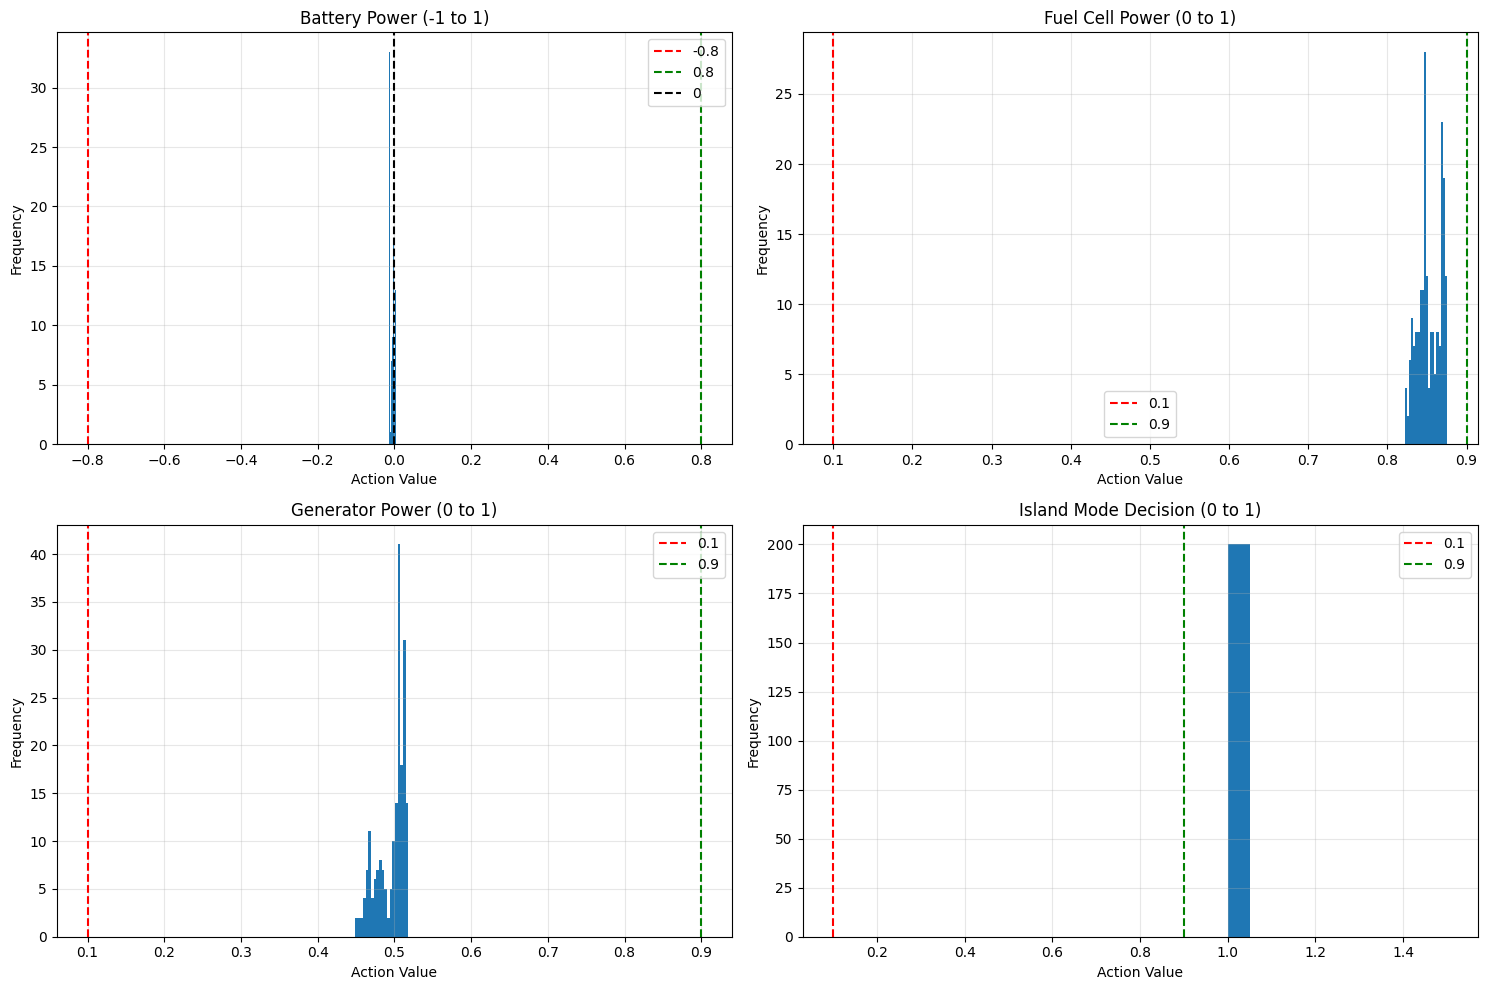

In [66]:
def analyze_all_actions(model, env, num_samples=200):
    """Analyze the distribution of all four actions in the microgrid environment."""
    # Action names for better readability
    action_names = [
        "Battery Power (-1 to 1)", 
        "Fuel Cell Power (0 to 1)", 
        "Generator Power (0 to 1)",
        "Island Mode Decision (0 to 1)"
    ]
    
    # Create storage for actions
    all_actions = []
    
    # Set up environment
    test_env = DummyVecEnv([lambda: env])
    
    # Sample actions
    obs = test_env.reset()
    for _ in range(num_samples):
        # Get action from policy
        action, _ = model.predict(obs, deterministic=True)
        all_actions.append(action[0])
        
        # Step environment
        obs, _, done, _ = test_env.step(action)
        if done[0]:
            obs = test_env.reset()
    
    # Convert to numpy array for analysis
    all_actions = np.array(all_actions)
    
    # Set up plotting
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    # Analyze each action
    for i in range(4):
        action_values = all_actions[:, i]
        
        # Basic statistics
        print(f"\n{action_names[i]} Statistics (out of {num_samples} samples):")
        print(f"  Mean: {action_values.mean():.4f}")
        print(f"  Std Dev: {action_values.std():.4f}")
        print(f"  Min: {action_values.min():.4f}")
        print(f"  Max: {action_values.max():.4f}")
        
        # For binary-like decisions (fuel cell, generator, island mode)
        if i > 0:  # Everything except battery which is -1 to 1
            print(f"  Values near max (>0.9): {(action_values > 0.9).sum()} ({(action_values > 0.9).sum()/num_samples*100:.1f}%)")
            print(f"  Values near min (<0.1): {(action_values < 0.1).sum()} ({(action_values < 0.1).sum()/num_samples*100:.1f}%)")
        else:
            # For battery which ranges from -1 to 1
            print(f"  High discharge (<-0.8): {(action_values < -0.8).sum()} ({(action_values < -0.8).sum()/num_samples*100:.1f}%)")
            print(f"  High charge (>0.8): {(action_values > 0.8).sum()} ({(action_values > 0.8).sum()/num_samples*100:.1f}%)")
            print(f"  Near zero (-0.1 to 0.1): {((action_values > -0.1) & (action_values < 0.1)).sum()} ({((action_values > -0.1) & (action_values < 0.1)).sum()/num_samples*100:.1f}%)")
        
        # Plot histogram
        axes[i].hist(action_values, bins=20)
        axes[i].set_title(action_names[i])
        axes[i].set_xlabel('Action Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
        
        # Add reference lines
        if i == 0:  # Battery
            axes[i].axvline(x=-0.8, color='r', linestyle='--', label='-0.8')
            axes[i].axvline(x=0.8, color='g', linestyle='--', label='0.8')
            axes[i].axvline(x=0, color='k', linestyle='--', label='0')
        else:  # Other actions
            axes[i].axvline(x=0.1, color='r', linestyle='--', label='0.1')
            axes[i].axvline(x=0.9, color='g', linestyle='--', label='0.9')
        
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()
    
    return all_actions

# Run diagnostics on all actions
action_data = analyze_all_actions(model, env, num_samples=200)

### Reset generator and island weights


Current policy parameters before gentle rebalancing:
  log_std: shape=torch.Size([4])
  action_net.weight: shape=torch.Size([4, 64])
  action_net.bias: shape=torch.Size([4])

Gently increased generator exploration in log_std:
  Before: 0.0000 (std: 1.0000)
  After: 0.0000 (std: 1.0000)

Gently increased island mode exploration in log_std:
  Before: 0.0000 (std: 1.0000)
  After: 0.0000 (std: 1.0000)

Gently adjusted generator weights in action_net.weight:
  Before: mean=0.0092, std=0.0858
  After: mean=0.0046, std=0.0895

Gently adjusted island mode weights in action_net.weight:
  Before: mean=0.0184, std=0.0754
  After: mean=0.0050, std=0.0767

Gently adjusted generator bias in action_net.bias:
  Before: -0.0810
  After: -0.1405

Gently adjusted island mode bias in action_net.bias:
  Before: 0.4959
  After: 0.4488

Successfully made gentle adjustments to 6 parameter sets

ACTION DISTRIBUTIONS AFTER GENTLE REBALANCING:

Battery Power (-1 to 1) Statistics (out of 200 samples):
  Mean: -

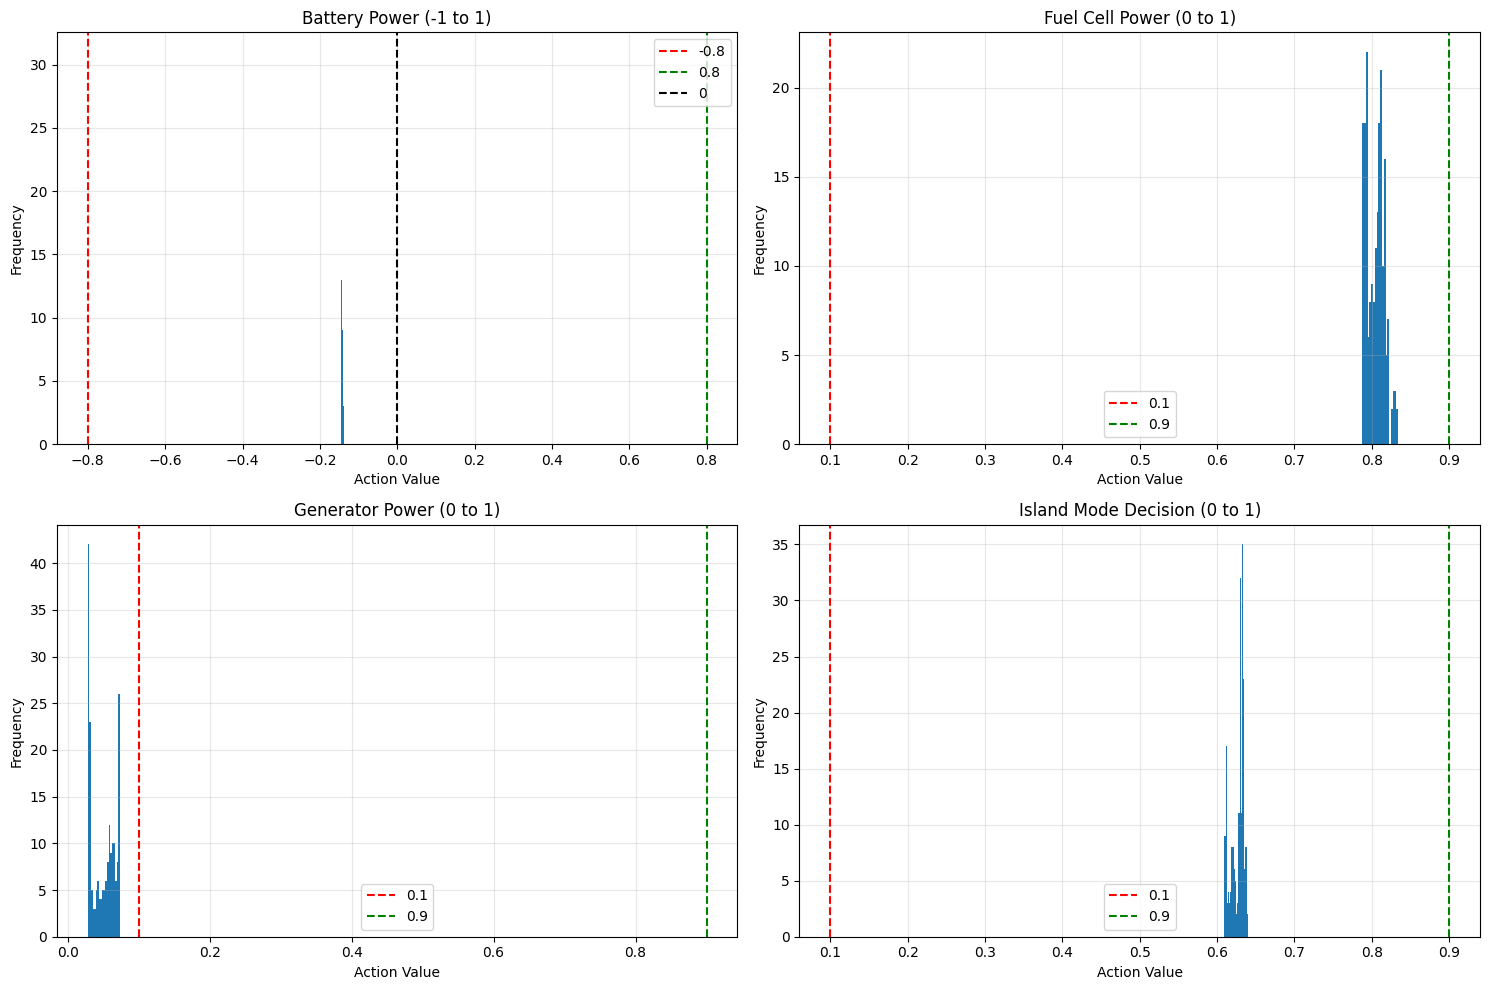

In [32]:
def gentle_rebalance_action_weights(model, verbose=True):
    """
    Gently rebalance generator and island mode weights to encourage
    more balanced behavior without drastic changes.
    """
    generator_idx = 2  # Action index for generator
    island_idx = 3     # Action index for island mode
    reset_count = 0
    
    # 1. Print current parameters
    if verbose:
        print("\nCurrent policy parameters before gentle rebalancing:")
        for name, param in model.policy.named_parameters():
            if 'action_net' in name or 'log_std' in name:
                print(f"  {name}: shape={param.shape}")
    
    # 2. Gently rebalance action_net weights
    for name, param in model.policy.named_parameters():
        if 'action_net.weight' in name:
            with torch.no_grad():
                # For generator action
                if param.shape[0] > generator_idx:
                    # Store old values for comparison
                    old_gen_values = param[generator_idx].clone()
                    # Scale down existing weights and add small random noise
                    param[generator_idx] = param[generator_idx] * 0.8 + torch.randn_like(param[generator_idx]) * 0.05
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nGently adjusted generator weights in {name}:")
                        print(f"  Before: mean={old_gen_values.mean():.4f}, std={old_gen_values.std():.4f}")
                        print(f"  After: mean={param[generator_idx].mean():.4f}, std={param[generator_idx].std():.4f}")
                
                # For island mode action
                if param.shape[0] > island_idx:
                    old_island_values = param[island_idx].clone()
                    # Slightly reduce weight magnitudes (less aggressively than before)
                    param[island_idx] = param[island_idx] * 0.7 + torch.randn_like(param[island_idx]) * 0.05
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nGently adjusted island mode weights in {name}:")
                        print(f"  Before: mean={old_island_values.mean():.4f}, std={old_island_values.std():.4f}")
                        print(f"  After: mean={param[island_idx].mean():.4f}, std={param[island_idx].std():.4f}")
        
        # 3. Gently adjust biases
        if 'action_net.bias' in name:
            with torch.no_grad():
                # For generator action
                if param.shape[0] > generator_idx:
                    old_gen_bias = param[generator_idx].item()
                    # Gently shift bias toward a small negative value
                    new_bias = old_gen_bias * 0.5 - 0.1
                    param[generator_idx] = new_bias
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nGently adjusted generator bias in {name}:")
                        print(f"  Before: {old_gen_bias:.4f}")
                        print(f"  After: {param[generator_idx].item():.4f}")
                
                # For island mode action
                if param.shape[0] > island_idx:
                    old_island_bias = param[island_idx].item()
                    # Shift bias towards more neutral value (less aggressive)
                    # If currently very positive, pull back slightly
                    if old_island_bias > 0.7:
                        new_bias = old_island_bias * 0.7 + 0.2
                    else:
                        # Otherwise just move toward 0.3 (slight preference for grid connection)
                        new_bias = old_island_bias * 0.3 + 0.3
                    param[island_idx] = new_bias
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nGently adjusted island mode bias in {name}:")
                        print(f"  Before: {old_island_bias:.4f}")
                        print(f"  After: {param[island_idx].item():.4f}")
        
        # 4. Moderately adjust exploration parameters (log_std)
        if 'log_std' in name:
            with torch.no_grad():
                # For generator action
                if param.shape[0] > generator_idx:
                    old_gen_std = param[generator_idx].item()
                    old_std_value = math.exp(old_gen_std)
                    
                    # Increase exploration slightly if it's very low
                    if old_std_value < 0.4:
                        new_std_value = 0.7
                    else:
                        # Otherwise increase by 20%
                        new_std_value = min(1.0, old_std_value * 1.2)
                    
                    param[generator_idx] = torch.log(torch.tensor(new_std_value))
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nGently increased generator exploration in {name}:")
                        print(f"  Before: {old_gen_std:.4f} (std: {old_std_value:.4f})")
                        print(f"  After: {param[generator_idx].item():.4f} (std: {new_std_value:.4f})")
                
                # For island mode action
                if param.shape[0] > island_idx:
                    old_island_std = param[island_idx].item()
                    old_std_value = math.exp(old_island_std)
                    
                    # Increase exploration slightly if it's very low
                    if old_std_value < 0.4:
                        new_std_value = 0.7
                    else:
                        # Otherwise increase by 20%
                        new_std_value = min(1.0, old_std_value * 1.2)
                    
                    param[island_idx] = torch.log(torch.tensor(new_std_value))
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nGently increased island mode exploration in {name}:")
                        print(f"  Before: {old_island_std:.4f} (std: {old_std_value:.4f})")
                        print(f"  After: {param[island_idx].item():.4f} (std: {new_std_value:.4f})")
    
    if reset_count == 0:
        print("\nCould not locate action parameters. The policy architecture might be different.")
    else:
        print(f"\nSuccessfully made gentle adjustments to {reset_count} parameter sets")
    
    return model

# Apply the gentle rebalancing
model = gentle_rebalance_action_weights(model, verbose=True)

# Validate the changes with your diagnostic function
print("\nACTION DISTRIBUTIONS AFTER GENTLE REBALANCING:")
after_rebalance_action_data = analyze_all_actions(model, env, num_samples=200)

### Reset battery


Current battery action parameters before zero-mean rebalancing:
  log_std: shape=torch.Size([4])
  action_net.weight: shape=torch.Size([4, 64])
  action_net.bias: shape=torch.Size([4])

Adjusted battery exploration in log_std:
  Before: -0.2231 (std: 0.8000)
  After: -0.5108 (std: 0.6000)

Adjusted battery weights in action_net.weight:
  Before: mean=0.0008, std=0.0560
  After: mean=-0.0004, std=0.0684

Reset battery bias in action_net.bias:
  Before: -0.0675
  After: 0.0704

Successfully rebalanced 3 battery parameter sets to target zero mean

ACTION DISTRIBUTIONS AFTER BATTERY REBALANCING:

Battery Power (-1 to 1) Statistics (out of 200 samples):
  Mean: -0.0056
  Std Dev: 0.0089
  Min: -0.0216
  Max: 0.0135
  High discharge (<-0.8): 0 (0.0%)
  High charge (>0.8): 0 (0.0%)
  Near zero (-0.1 to 0.1): 200 (100.0%)

Fuel Cell Power (0 to 1) Statistics (out of 200 samples):
  Mean: 0.8493
  Std Dev: 0.0302
  Min: 0.7803
  Max: 0.8861
  Values near max (>0.9): 0 (0.0%)
  Values near min 

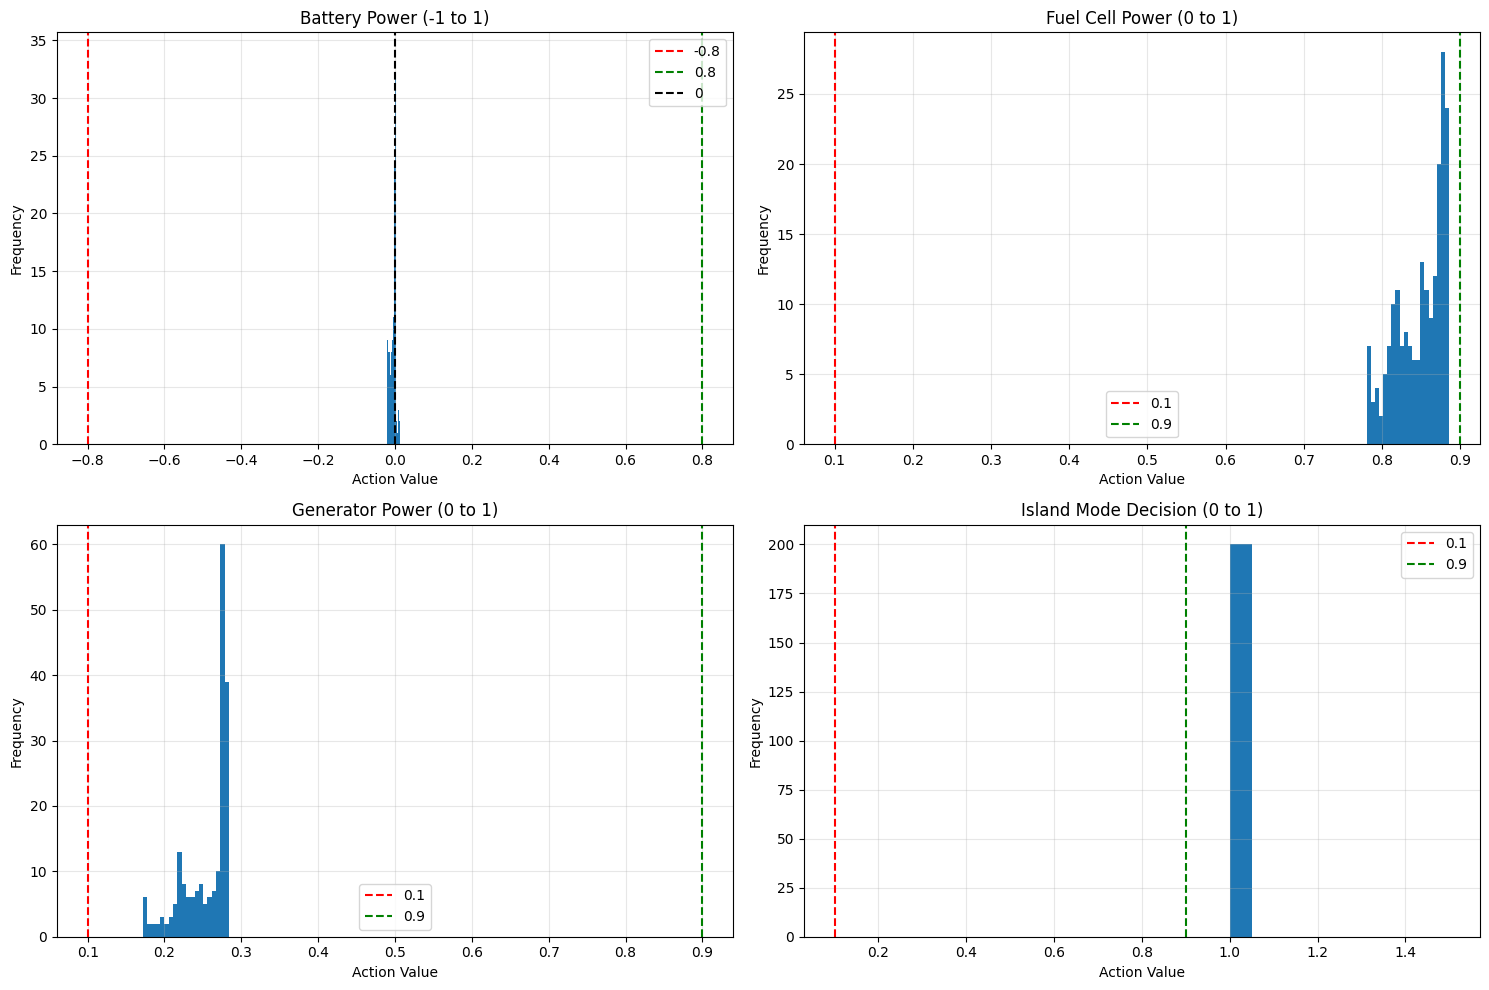

In [61]:
def rebalance_battery_to_zero_mean(model, verbose=True):
    """
    Rebalance battery action weights to achieve a mean close to zero,
    encouraging balanced charging/discharging behavior.
    """
    battery_idx = 0  # Action index for battery (battery is the first action)
    reset_count = 0
    
    # 1. Print current parameters
    if verbose:
        print("\nCurrent battery action parameters before zero-mean rebalancing:")
        for name, param in model.policy.named_parameters():
            if 'action_net' in name or 'log_std' in name:
                print(f"  {name}: shape={param.shape}")
    
    # 2. Rebalance action_net weights
    for name, param in model.policy.named_parameters():
        if 'action_net.weight' in name:
            with torch.no_grad():
                # For battery action
                if param.shape[0] > battery_idx:
                    # Store old values for comparison
                    old_battery_values = param[battery_idx].clone()
                    old_mean = old_battery_values.mean().item()
                    
                    # Calculate adjustment needed to move mean toward zero
                    # Scale down existing weights to reduce extreme values
                    # Then shift to ensure mean is closer to zero
                    scale_factor = 0.7  # Reduce the strength of existing weights
                    param[battery_idx] = param[battery_idx] * scale_factor
                    
                    # Add a bias correction to move mean closer to zero
                    # If mean is negative, add positive values and vice versa
                    current_mean = param[battery_idx].mean().item()
                    correction = -current_mean  # Correction to move mean to zero
                    
                    # Apply correction uniformly across weights
                    param[battery_idx] += correction / param[battery_idx].numel()
                    
                    # Add small random noise to prevent uniformity
                    param[battery_idx] += torch.randn_like(param[battery_idx]) * 0.05
                    
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nAdjusted battery weights in {name}:")
                        print(f"  Before: mean={old_mean:.4f}, std={old_battery_values.std():.4f}")
                        print(f"  After: mean={param[battery_idx].mean():.4f}, std={param[battery_idx].std():.4f}")
        
        # 3. Adjust bias to target zero mean
        if 'action_net.bias' in name:
            with torch.no_grad():
                # For battery action
                if param.shape[0] > battery_idx:
                    old_battery_bias = param[battery_idx].item()
                    
                    # Set bias close to zero to remove any strong preset tendency
                    # A small random value helps break symmetry
                    new_bias = torch.randn(1).item() * 0.1  # Small random value around zero
                    param[battery_idx] = new_bias
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nReset battery bias in {name}:")
                        print(f"  Before: {old_battery_bias:.4f}")
                        print(f"  After: {param[battery_idx].item():.4f}")
        
        # 4. Adjust exploration parameters (log_std)
        if 'log_std' in name:
            with torch.no_grad():
                # For battery action
                if param.shape[0] > battery_idx:
                    old_battery_std = param[battery_idx].item()
                    old_std_value = math.exp(old_battery_std)
                    
                    # Set to a moderate exploration value (~0.5-0.6)
                    # This ensures good exploration around the zero mean
                    new_std_value = 0.6
                    
                    param[battery_idx] = torch.log(torch.tensor(new_std_value))
                    reset_count += 1
                    
                    if verbose:
                        print(f"\nAdjusted battery exploration in {name}:")
                        print(f"  Before: {old_battery_std:.4f} (std: {old_std_value:.4f})")
                        print(f"  After: {param[battery_idx].item():.4f} (std: {new_std_value:.4f})")
    
    if reset_count == 0:
        print("\nCould not locate battery action parameters. The policy architecture might be different.")
    else:
        print(f"\nSuccessfully rebalanced {reset_count} battery parameter sets to target zero mean")
    
    return model

# Apply the zero-mean battery rebalancing
model = rebalance_battery_to_zero_mean(model, verbose=True)

# Validate the changes with your diagnostic function
print("\nACTION DISTRIBUTIONS AFTER BATTERY REBALANCING:")
after_rebalance_action_data = analyze_all_actions(model, env, num_samples=200)

### Aggressive policy rebalance

In [ ]:
def aggressive_policy_rebalancing(model, verbose=True):
    """
    Aggressively rebalance all action parameters to break out of rigid behaviors
    and encourage more diverse actions.
    """
    import math
    import torch
    import numpy as np
    
    # Action indices
    BATTERY_IDX = 0
    FUEL_CELL_IDX = 1
    GENERATOR_IDX = 2
    ISLAND_MODE_IDX = 3
    
    # Target values for each action
    targets = {
        BATTERY_IDX: {"mean": 0.0, "std": 0.5},  # Zero-centered with good variance
        FUEL_CELL_IDX: {"mean": 0.5, "std": 0.4},  # Mid-range for fuel cell
        GENERATOR_IDX: {"mean": 0.3, "std": 0.4},  # Moderate generator usage
        ISLAND_MODE_IDX: {"mean": 0.4, "std": 0.5}  # Less frequent island mode
    }
    
    reset_count = 0
    
    # Print current parameters
    if verbose:
        print("\nCurrent action parameters before aggressive rebalancing:")
        for name, param in model.policy.named_parameters():
            if 'action_net' in name or 'log_std' in name:
                print(f"  {name}: shape={param.shape}")
    
    # Rebalance action_net weights and biases
    for name, param in model.policy.named_parameters():
        # Handle weights
        if 'action_net.weight' in name:
            with torch.no_grad():
                for action_idx in targets.keys():
                    if param.shape[0] > action_idx:
                        # Store old values
                        old_values = param[action_idx].clone()
                        old_mean = old_values.mean().item()
                        old_std = old_values.std().item()
                        
                        # Reset weights with normal distribution
                        # centered at 0 with appropriate std for the target
                        new_weights = torch.randn_like(param[action_idx]) * 0.1
                        param[action_idx] = new_weights
                        
                        reset_count += 1
                        
                        if verbose:
                            print(f"\nReset weights for action {action_idx} in {name}:")
                            print(f"  Before: mean={old_mean:.4f}, std={old_std:.4f}")
                            print(f"  After: mean={param[action_idx].mean():.4f}, std={param[action_idx].std():.4f}")
        
        # Handle biases - this is where we set the target means
        if 'action_net.bias' in name:
            with torch.no_grad():
                for action_idx, target in targets.items():
                    if param.shape[0] > action_idx:
                        old_bias = param[action_idx].item()
                        
                        # Set bias to achieve target mean
                        # Add small random noise for asymmetry
                        target_mean = target["mean"]
                        new_bias = target_mean + torch.randn(1).item() * 0.05
                        param[action_idx] = new_bias
                        
                        reset_count += 1
                        
                        if verbose:
                            print(f"\nReset bias for action {action_idx} in {name}:")
                            print(f"  Before: {old_bias:.4f}")
                            print(f"  After: {param[action_idx].item():.4f} (target: {target_mean:.4f})")
        
        # Handle exploration parameters (log_std)
        if 'log_std' in name:
            with torch.no_grad():
                for action_idx, target in targets.items():
                    if param.shape[0] > action_idx:
                        old_std = param[action_idx].item()
                        old_std_value = math.exp(old_std)
                        
                        # Set to target exploration value
                        target_std = target["std"]
                        param[action_idx] = torch.log(torch.tensor(target_std))
                        
                        reset_count += 1
                        
                        if verbose:
                            print(f"\nReset exploration for action {action_idx} in {name}:")
                            print(f"  Before: {old_std:.4f} (std: {old_std_value:.4f})")
                            print(f"  After: {param[action_idx].item():.4f} (std: {target_std:.4f})")
    
    if reset_count == 0:
        print("\nCould not locate action parameters. The policy architecture might be different.")
    else:
        print(f"\nSuccessfully reset {reset_count} parameter sets to break rigid behaviors")
    
    return model

model = aggressive_policy_rebalancing(model, verbose=True)

# Validate the changes
print("\nACTION DISTRIBUTIONS AFTER AGGRESSIVE REBALANCING:")
after_rebalance_action_data = analyze_all_actions(model, env, num_samples=200)

In [ ]:
# Model saved to ppo_model_2025-04-26_02-52-21
# Plot saved to training_metrics_20250426_025221.png
# BEST - ppo_model_2025-05-09_18-25-27

In [82]:
# Save current model (whatever is the model varaible)
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model_path = f"ppo_model_{current_time}"
model.save(model_path)
print(f"Model saved to {model_path}")
# print("This model uses battery cycling and has increased penalties for grid connections")

Model saved to ppo_model_2025-05-09_18-25-27


final timesteps plotting:  30240
Plot saved to training_metrics_20250509_174044.png


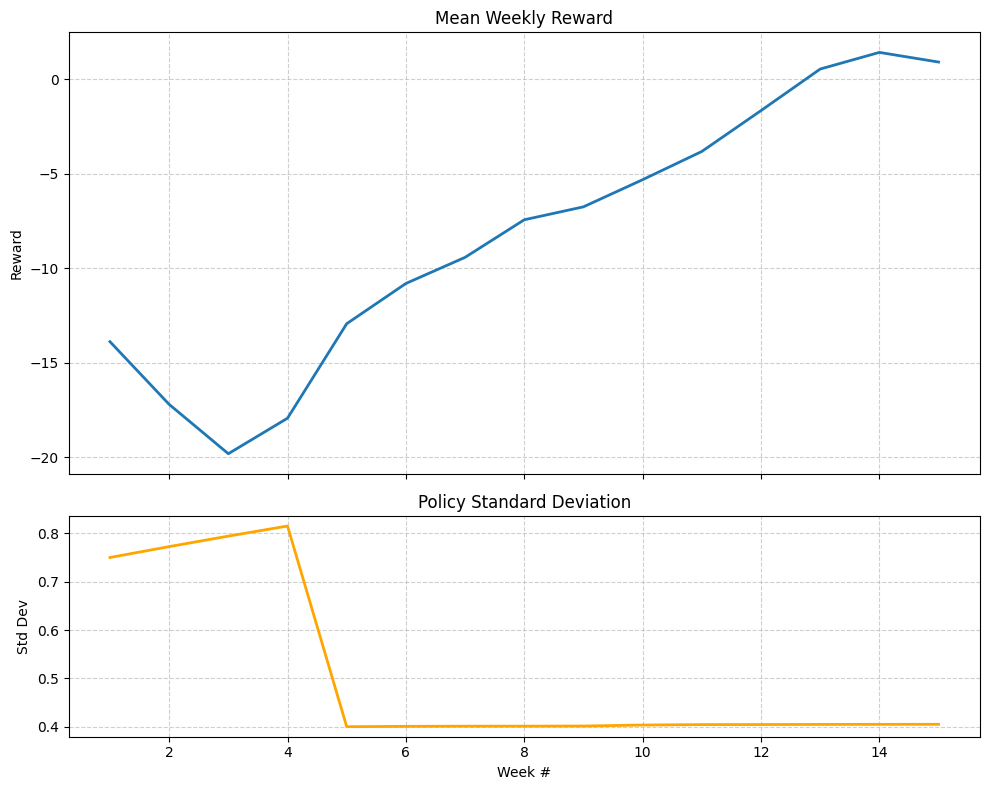

Training metrics saved to training_metrics_20250509_174044.png


In [67]:
# Plot and save training metrics
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
img = f"training_metrics_{ts}.png"
if plot_training_metrics(callback, save_path=img, smoothing_window=10):
    print(f"Training metrics saved to {img}")

### Visualizing Inference

In [89]:
def visualize_continuous_inference(model, env, num_steps=1000, debug_battery=True, 
                                   use_noise=False, noise_scales=[0.1, 0.1, 0.1, 0.05]):
    """
    run the trained model in the environment for a continuous period without any resets
    or modifications to the battery state.
    
    parameters:
    -----------
    model : stable baselines 3 model
        the trained ppo model
    env : gym.env
        the microgrid environment
    num_steps : int
        number of steps to run the simulation
    debug_battery : bool
        whether to print detailed battery soc debugging information
    use_noise : bool
        whether to add controlled noise to actions (stochastic sampling)
    noise_scales : list
        standard deviation of noise to add for each action dimension:
        [battery, fuel_cell, generator, island_mode]
    """
    # set the model to evaluation mode (important for models with dropout layers)
    model.set_env(env)  # ensure the environment is properly set
    model.policy.eval()  # set the policy to evaluation mode
    
    # data collectors
    observations = []
    actions = []
    raw_actions = []  # store actions before noise
    noises_added = []  # store the noise added to each action
    rewards = []
    info_history = []
    timestamps = []
    day_boundaries = []
    battery_soc_changes = []  # track soc changes
    raw_battery_powers = []   # track raw battery power commands
    actual_battery_powers = [] # track actual battery power after constraints
    energy_changes = []       # track energy changes to battery
    
    current_day = None
    
    # initial reset to start at a random point
    obs, _ = env.reset()
    initial_soc = env.battery_soc
    
    # determine the number of steps per day (assuming 5-minute intervals)
    steps_per_day = 24 * 60 // 5  # = 288 steps per day
    
    print(f"starting continuous inference for {num_steps} steps...")
    print(f"initial battery soc: {initial_soc:.4f}")
    print(f"time resolution: 5 minutes per step (288 steps = 24 hours)")
    print(f"expected simulation duration: {num_steps / steps_per_day:.1f} days")
    
    # define stochastic prediction function with controlled noise
    def predict_with_controlled_noise(obs):
        # get deterministic prediction as baseline
        mean_action, _ = model.predict(obs, deterministic=True)
        raw_actions.append(mean_action.copy())
        
        if use_noise:
            # add carefully calibrated noise for each dimension
            noise = np.random.normal(0, 1, size=len(mean_action)) * noise_scales
            noises_added.append(noise)
            # apply noise and clip to valid action range
            action_low = np.array([-1.0, 0.0, 0.0, 0.0])
            action_high = np.array([1.0, 1.0, 1.0, 1.0])
            noisy_action = np.clip(mean_action + noise, action_low, action_high)
            return noisy_action
        else:
            noises_added.append(np.zeros_like(mean_action))
            return mean_action
    
    for i in range(num_steps):
        # get action from the model with optional controlled noise
        action = predict_with_controlled_noise(obs)
        
        # store raw battery power command (before any constraints are applied)
        raw_battery_power = action[0] * env.max_battery_discharge_rate
        raw_battery_powers.append(raw_battery_power)
        
        # keep track of soc before step
        soc_before = env.battery_soc
        
        # take step in environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # calculate soc change
        soc_after = env.battery_soc
        soc_change = soc_after - soc_before
        battery_soc_changes.append(soc_change)
        
        # store actual battery power used
        if 'battery_power' in info:
            actual_battery_powers.append(info['battery_power'])
        else:
            # if not available in info, calculate from soc change
            time_factor = 5/60  # 5 min in hours
            capacity_factor = env.battery_capacity  # battery capacity in kwh
            if soc_change > 0:  # charging
                est_power = soc_change * capacity_factor / time_factor * env.battery_charging_efficiency
            else:  # discharging
                est_power = soc_change * capacity_factor / time_factor / env.battery_discharging_efficiency
            actual_battery_powers.append(est_power)
            
        # calculate energy change (kwh)
        energy_change = soc_change * env.battery_capacity
        energy_changes.append(energy_change)
            
        # print detailed battery information if debug_battery is true
        if debug_battery and (i % 10 == 0 or abs(soc_change) > 0.05):
            print(f"step {i}:")
            print(f"  battery soc: {soc_before:.4f} → {soc_after:.4f} (δ: {soc_change:.4f})")
            if use_noise:
                print(f"  raw action: {raw_actions[-1][0]:.4f}, noise: {noises_added[-1][0]:.4f}, final action: {action[0]:.4f}")
            print(f"  battery action: {action[0]:.4f}, raw power command: {raw_battery_power:.2f} kw")
            print(f"  actual battery power: {actual_battery_powers[-1]:.2f} kw")
            print(f"  energy change: {energy_change:.2f} kwh")
            
        # issue warnings for concerning battery states without modifying anything
        if soc_after >= 0.999:
            print(f"  warning: battery soc at maximum (1.0) at step {i}")
        if soc_after <= 0.201:
            print(f"  warning: battery soc at minimum (0.2) at step {i}")
        
        # store data
        observations.append(obs)
        actions.append(action)
        rewards.append(reward)
        info_history.append(info)
        
        # record timestamp
        idx = env.start_idx + env.current_step - 1
        if idx >= 0 and idx < len(env.data):
            timestamp = env.data.index[idx]
            timestamps.append(timestamp)
            
            # track day boundaries for visualization
            if current_day is None:
                current_day = timestamp.date()
            elif timestamp.date() != current_day:
                day_boundaries.append(i)
                current_day = timestamp.date()
                # print daily summary
                if debug_battery:
                    print(f"\n==== new day: {current_day} ====")
                    print(f"  current battery soc: {soc_after:.4f}\n")
        else:
            timestamps.append(None)
        
        # handle episode boundaries without resetting the environment
        if terminated or truncated:
            # keep track of the original battery soc - we don't modify it
            original_soc = env.battery_soc
            
            # manually advance the environment's internal counter
            env.start_idx += env.episode_length
            env.current_step = 0
            
            # just print a warning if battery is outside operational range
            if env.battery_soc < env.min_battery_soc:
                print(f"  warning: battery soc below minimum threshold at step {i}: {env.battery_soc:.4f}")
                print(f"  continuing inference without resetting battery state.")
            
            if debug_battery:
                print(f"episode boundary at step {i}, continuing without any resets")
        
        # update observation for next step
        obs = next_obs
    
    # print summary statistics about battery behavior
    if debug_battery:
        print("\n===== battery analysis summary =====")
        soc_changes = np.array(battery_soc_changes)
        powers = np.array(actual_battery_powers)
        
        print(f"soc changes: min={soc_changes.min():.4f}, max={soc_changes.max():.4f}, mean={soc_changes.mean():.4f}")
        print(f"actual battery powers: min={powers.min():.2f}kw, max={powers.max():.2f}kw, mean={powers.mean():.2f}kw")
        
        charging_steps = sum(1 for change in soc_changes if change > 0.001)
        discharging_steps = sum(1 for change in soc_changes if change < -0.001)
        static_steps = num_steps - charging_steps - discharging_steps
        
        print(f"battery activity:")
        print(f"  charging: {charging_steps} steps ({charging_steps/num_steps*100:.1f}%)")
        print(f"  discharging: {discharging_steps} steps ({discharging_steps/num_steps*100:.1f}%)")
        print(f"  static: {static_steps} steps ({static_steps/num_steps*100:.1f}%)")
        
        high_soc_steps = sum(1 for info in info_history if info['battery_soc'] > 0.95)
        low_soc_steps = sum(1 for info in info_history if info['battery_soc'] < 0.25)
        print(f"time spent at high soc (>95%): {high_soc_steps} steps ({high_soc_steps/num_steps*100:.1f}%)")
        print(f"time spent at low soc (<25%): {low_soc_steps} steps ({low_soc_steps/num_steps*100:.1f}%)")
    
    # convert to numpy arrays for easier handling
    observations = np.array(observations)
    actions = np.array(actions)
    raw_actions = np.array(raw_actions)
    noises_added = np.array(noises_added)
    rewards = np.array(rewards)
    info_df = pd.DataFrame(info_history)

    # add battery power analysis to info_df
    info_df['battery_soc_change'] = battery_soc_changes
    info_df['raw_battery_power'] = raw_battery_powers
    info_df['actual_battery_power'] = actual_battery_powers
    info_df['energy_change'] = energy_changes
    
    # add timestamps to the dataframe if available
    if len(timestamps) > 0 and timestamps[0] is not None:
        info_df['timestamp'] = timestamps
    
    # create a time-based x-axis for plotting
    # first, create a time column based on step index (5-minute intervals)
    step_times = []
    for i in range(len(info_df)):
        hours = (i * 5) // 60
        minutes = (i * 5) % 60
        step_times.append(f"{hours:02d}:{minutes:02d}")
    
    info_df['step_time'] = step_times
    
    # calculate day number for each step - using 0-based indexing
    info_df['day_number'] = np.floor(np.arange(len(info_df)) / steps_per_day).astype(int)
    
    # generate x tick positions and labels for daily boundaries - using 0-based indexing
    day_ticks = [i * steps_per_day for i in range(int(np.ceil(len(info_df) / steps_per_day)))]
    day_labels = [f"Day {i}" for i in range(len(day_ticks))]  # 0-based indexing
    
    # consistent figsize for all subplots
    consistent_figsize = (14, 6)
    
    # helper function to format x-axis with day markers
    def format_time_axis(ax, step_interval=48):
        """format x-axis with day markers and time ticks"""
        # major ticks at day boundaries
        ax.set_xticks(day_ticks)
        ax.set_xticklabels(day_labels)
        
        # minor ticks at specified interval (hours)
        hours_interval = step_interval * 5 / 60  # convert steps to hours
        minor_ticks = []
        minor_labels = []
        
        for day in range(int(np.ceil(len(info_df) / steps_per_day))):
            day_start = day * steps_per_day
            for hour_step in range(0, steps_per_day, step_interval):
                tick_pos = day_start + hour_step
                if tick_pos < len(info_df):
                    minor_ticks.append(tick_pos)
                    hour = (hour_step * 5) // 60
                    minor_labels.append(f"{hour:02d}:00")
        
        # add minor ticks for selected hours
        if step_interval < steps_per_day:
            ax.set_xticks(minor_ticks, minor=True)
            # we don't add the minor labels because they would make the plot too crowded
        
        # add day boundary lines
        for boundary in day_boundaries:
            ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        
        # add grid lines
        ax.grid(True, which='both', alpha=0.3)
        
        # add x-axis label explaining time scale
        ax.set_xlabel("simulation time (5-minute intervals, 288 steps = 1 day)")

    # plot 1: actions taken by the agent
    fig, axes = plt.subplots(4, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 2), sharex=True)
    action_names = [
        'battery power (-1=discharge, 1=charge)',
        'fuel cell power (0-1)',
        'generator power (0-1)',
        'island mode (0=grid, 1=island)'
    ]
    
    for i, (ax, name) in enumerate(zip(axes, action_names)):
        if use_noise:
            # Only show the final action with noise for battery, fuel cell, and generator
            if i == 3:  # Only show both for island mode
                ax.plot(range(len(raw_actions)), raw_actions[:, i], 'g-', alpha=0.5, label='deterministic action')
                ax.plot(range(len(actions)), actions[:, i], 'b-', label='final action (with noise)')
                ax.legend(loc='upper right')
            else:
                ax.plot(range(len(actions)), actions[:, i], 'b-')
        else:
            ax.plot(range(len(actions)), actions[:, i], 'b-')
            
        ax.set_title(name)
        
        # add day boundary markers only (no noon markers)
        for boundary in day_boundaries:
            ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
            ax.text(boundary, ax.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
                   rotation=90, verticalalignment='top', fontsize=8)
        
        # Adjust y-axis limits to better highlight small changes
        if i == 0:  # Battery power
            # For battery, use tighter bounds to highlight small variations
            ydata = actions[:, i]
            ymin, ymax = np.min(ydata), np.max(ydata)
            # Add just a small buffer (5%) to make small changes more visible
            buffer = 0.05 * (ymax - ymin)
            # Ensure at least -1.05 to 1.05 range to maintain context
            ax.set_ylim(max(-1.05, ymin - buffer), min(1.05, ymax + buffer))
            # Add a zero line for reference
            ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
            
        elif i == 1:  # Fuel cell power
            # For fuel cell, zoom in on the active range to highlight variations
            ydata = actions[:, i]
            ymin, ymax = np.min(ydata), np.max(ydata)
            # If the range is very narrow, expand it slightly for visibility
            if ymax - ymin < 0.1:  # If range is very small
                ymid = (ymax + ymin) / 2
                ymin = max(0, ymid - 0.1)  # Ensure we don't go below 0
                ymax = min(1, ymid + 0.1)  # Ensure we don't go above 1
            else:
                # Otherwise use a small buffer
                buffer = 0.05 * (ymax - ymin)
                ymin = max(0, ymin - buffer)  # Don't go below 0
                ymax = min(1, ymax + buffer)  # Don't go above 1
            ax.set_ylim(ymin, ymax)
            # Add grid lines for better reference
            ax.grid(True, alpha=0.3, which='both')
            
        elif i == 2:  # Generator power
            # For generator, zoom in on the active range to highlight variations
            ydata = actions[:, i]
            ymin, ymax = np.min(ydata), np.max(ydata)
            # If the range is very narrow, expand it slightly for visibility
            if ymax - ymin < 0.1:  # If range is very small
                ymid = (ymax + ymin) / 2
                ymin = max(0, ymid - 0.1)  # Ensure we don't go below 0
                ymax = min(1, ymid + 0.1)  # Ensure we don't go above 1
            else:
                # Otherwise use a small buffer
                buffer = 0.05 * (ymax - ymin)
                ymin = max(0, ymin - buffer)  # Don't go below 0
                ymax = min(1, ymax + buffer)  # Don't go above 1
            ax.set_ylim(ymin, ymax)
            # Add grid lines for better reference
            ax.grid(True, alpha=0.3, which='both')
            
        elif i == 3:  # Island mode plot
            ax.set_yticks([0, 0.5, 1])
            ax.set_yticklabels(['grid connected', 'threshold', 'island mode'])
            ax.set_ylim(-0.1, 1.1)  # Standard range for island mode
    
    # format the time axis on the bottom subplot
    format_time_axis(axes[-1])
    
    fig.suptitle('agent actions over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # plot 2: battery state and renewable usage
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 1.5), sharex=True)
    
    # battery soc plot
    ax1.plot(range(len(info_df)), info_df['battery_soc'] * 100)
    ax1.set_title('battery state of charge during continuous operation (%)')
    ax1.set_ylabel('soc (%)')
    ax1.axhline(y=env.min_battery_soc * 100, color='r', linestyle='--', 
                label=f'min soc ({env.min_battery_soc * 100}%)')
                
    # add target soc range indicators
    ax1.axhspan(30, 70, alpha=0.2, color='green', label='target soc range')
    ax1.axhline(y=50, color='g', linestyle='-.', alpha=0.7,
                label=f'optimal soc (50%)')
    
    # Adjust y-axis to reduce whitespace
    ymin, ymax = ax1.get_ylim()
    buffer = 0.05 * (ymax - ymin)  # 5% buffer
    ax1.set_ylim(max(0, ymin - buffer), min(100, ymax + buffer))
    
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # add day boundary markers
    for boundary in day_boundaries:
        ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax1.text(boundary, ax1.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Battery power commands vs actual power with optimized scaling
    ax2.plot(range(len(info_df)), info_df['raw_battery_power'], 'b-', label='battery command')
    ax2.plot(range(len(info_df)), info_df['actual_battery_power'], 'r-', label='actual battery power')
    ax2.set_title('battery power commands vs actual power (kw)')
    ax2.set_ylabel('power (kw)')
    ax2.axhline(y=0, color='black', linewidth=0.5)
    
    # Optimize y-axis for battery power to highlight small differences between command and actual
    power_data = np.concatenate([info_df['raw_battery_power'].values, info_df['actual_battery_power'].values])
    ymin, ymax = np.min(power_data), np.max(power_data)
    # Use very small buffer (3%) to highlight differences
    buffer = 0.03 * (ymax - ymin)
    ax2.set_ylim(ymin - buffer, ymax + buffer)
    
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # add day boundary markers
    for boundary in day_boundaries:
        ax2.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax2.text(boundary, ax2.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Battery SOC change per step with optimized scaling
    ax3.plot(range(len(info_df)), info_df['battery_soc_change'] * 100, 'g-')
    ax3.set_title('battery soc change per step (%)')
    ax3.set_ylabel('soc change (%)')
    ax3.axhline(y=0, color='black', linewidth=0.5)
    
    # Optimize y-axis for SOC change to highlight small changes
    soc_changes = info_df['battery_soc_change'].values * 100  # Convert to percentage
    ymin, ymax = np.min(soc_changes), np.max(soc_changes)
    # Use very small buffer (3%) to highlight small changes
    buffer = 0.03 * (ymax - ymin)
    ax3.set_ylim(ymin - buffer, ymax + buffer)
    
    # Add minor grid lines to help track small changes
    ax3.grid(True, alpha=0.3, which='both')
    
    # add day boundary markers
    for boundary in day_boundaries:
        ax3.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax3.text(boundary, ax3.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # format time axis
    format_time_axis(ax3)
    
    fig.suptitle('battery metrics during continuous operation (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # plot 3: renewable energy usage
    if 'renewable_usage' in info_df.columns:
        plt.figure(figsize=(consistent_figsize[0], consistent_figsize[1]))
        plt.plot(range(len(info_df)), info_df['renewable_usage'] * 100)
        plt.title('renewable energy usage (%)')
        plt.ylabel('renewable usage (%)')
        plt.grid(True, alpha=0.3)
        
        # add day boundary markers
        for boundary in day_boundaries:
            plt.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
            plt.text(boundary, plt.ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
                  rotation=90, verticalalignment='top', fontsize=8)
        
        # format time axis
        ax = plt.gca()
        format_time_axis(ax)
        
        plt.suptitle('renewable energy usage over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
        plt.tight_layout()
        plt.show()
    
    # plot 4: power sources
    plt.figure(figsize=(consistent_figsize[0], consistent_figsize[1]))
    
    # get power information directly from info_df
    solar_power = np.array(info_df['solar_power'])
    wind_power = np.array(info_df['wind_power'])
    generator_power = np.array(info_df['generator_power'])
    fuel_cell_power = np.array(info_df['fuel_cell_power'])
    grid_power = np.array(info_df['grid_power'])
    
    # separate grid import/export
    grid_import = np.maximum(0, grid_power)
    grid_export = -np.minimum(0, grid_power)
    
    # plot power sources
    plt.plot(range(len(info_df)), solar_power, 'gold', label="solar pv", linewidth=2)
    plt.plot(range(len(info_df)), wind_power, 'cyan', label="wind", linewidth=2)
    plt.plot(range(len(info_df)), generator_power, 'darkorange', label="generator", linewidth=2)
    plt.plot(range(len(info_df)), fuel_cell_power, 'limegreen', label="fuel cell", linewidth=2)
    plt.plot(range(len(info_df)), info_df['battery_discharge'], 'dodgerblue', label="battery discharge", linewidth=2)
    plt.plot(range(len(info_df)), grid_import, 'gray', label="grid import", linewidth=2)
    plt.plot(range(len(info_df)), -grid_export, 'r--', label="grid export", linewidth=2)
    
    # zero line
    plt.axhline(0, color='black', linewidth=0.5)
    
    # add day boundary markers
    for boundary in day_boundaries:
        plt.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        plt.text(boundary, plt.ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    plt.title('power sources during continuous operation', fontsize=16)
    plt.ylabel('power (kw)')
    
    # Adjust y-axis to reduce whitespace
    ymin, ymax = plt.ylim()
    buffer = 0.05 * (ymax - ymin)  # 5% buffer
    plt.ylim(ymin - buffer, ymax + buffer)
    
    # format time axis
    ax = plt.gca()
    format_time_axis(ax)
    
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.suptitle('power sources over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # plot 5: rewards
    fig, ax = plt.subplots(figsize=(consistent_figsize[0], consistent_figsize[1]))
    ax.plot(range(len(rewards)), rewards)
    ax.set_title('reward during continuous operation')
    ax.set_ylabel('reward')
    ax.grid(True, alpha=0.3)
    
    # add cumulative rewards
    cumulative_rewards = np.cumsum(rewards)
    ax2 = ax.twinx()
    ax2.plot(range(len(cumulative_rewards)), cumulative_rewards, 'g--', alpha=0.7)
    ax2.set_ylabel('cumulative reward', color='g')
    
    # add day boundary markers
    for boundary in day_boundaries:
        ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax.text(boundary, ax.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Adjust y-axis to reduce whitespace
    ymin, ymax = ax.get_ylim()
    buffer = 0.05 * (ymax - ymin)  # 5% buffer
    ax.set_ylim(ymin - buffer, ymax + buffer)
    
    # format time axis
    format_time_axis(ax)
    
    plt.suptitle('reward over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # plot 6: load management (updated for unmet load)
    fig, ax = plt.subplots(figsize=(consistent_figsize[0], consistent_figsize[1] * 1.5))
    
    critical = info_df['critical_load']
    essential = info_df['essential_load']
    non_critical = info_df['non_critical_load']
    
    # Create stacked plot of load types
    ax.stackplot(range(len(info_df)), critical, essential, non_critical, 
                 labels=['critical', 'essential', 'non-critical'], 
                 colors=['#ff6666', '#ffcc66', '#66b3ff'], alpha=0.7)
    
    # Make sure unmet loads are shown even when zero
    # Get unmet load columns if they exist, otherwise use zeros
    unmet_critical = info_df['unmet_critical_load'] if 'unmet_critical_load' in info_df.columns else np.zeros(len(info_df))
    unmet_essential = info_df['unmet_essential_load'] if 'unmet_essential_load' in info_df.columns else np.zeros(len(info_df))
    unmet_non_critical = info_df['unmet_non_critical_load'] if 'unmet_non_critical_load' in info_df.columns else np.zeros(len(info_df))
    
    # Always plot unmet loads, even if they're all zeros
    ax.plot(range(len(info_df)), unmet_critical, 'ro--', 
            label='unmet critical load (=0)', markersize=4, markevery=50, linewidth=1.5)
    ax.plot(range(len(info_df)), unmet_essential, 'mo--', 
            label='unmet essential load (=0)', markersize=4, markevery=50, linewidth=1.5)
    ax.plot(range(len(info_df)), unmet_non_critical, 'bo--', 
            label='unmet non-critical load (=0)', markersize=4, markevery=50, linewidth=1.5)
    
    # Add text labels for zero loads in the center of the plot
    if critical.max() == 0:
        ax.text(len(info_df)/2, 0.1, "Critical Load = 0", horizontalalignment='center', fontsize=12)
    if essential.max() == 0:
        ax.text(len(info_df)/2, 0.2, "Essential Load = 0", horizontalalignment='center', fontsize=12)
    if non_critical.max() == 0:
        ax.text(len(info_df)/2, 0.3, "Non-Critical Load = 0", horizontalalignment='center', fontsize=12)
    
    # add combined legend
    ax.legend(loc='upper left')
    
    ax.set_ylabel('power (kw)')
    
    # add day boundary markers
    for boundary in day_boundaries:
        ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax.text(boundary, ax.get_ylim()[1]*0.95, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
                rotation=90, verticalalignment='top', fontsize=8)
    
    # Format time axis
    format_time_axis(ax)
    
    # Keep the original y-axis scale
    ax.set_ylim(0, ax.get_ylim()[1])  # Start at 0 but keep upper limit
    
    ax.set_title('load management during continuous operation', fontsize=16)
    plt.suptitle('load management over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # plot 7: island mode vs generator output
    # create two separate y-axes
    fig, ax1 = plt.subplots(figsize=consistent_figsize)
    
    # plot island mode as binary values (0/1)
    island_line = ax1.plot(range(len(info_df)), info_df['island_mode'].astype(int), 'b-', 
                          label='island mode', linewidth=2)
    ax1.set_ylabel('island mode', color='b')
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['grid connected', 'island mode'])
    
    # create second y-axis for generator output
    ax2 = ax1.twinx()
    gen_line = ax2.plot(range(len(info_df)), generator_power, 'darkorange', 
                       label='generator output', linewidth=2)
    ax2.set_ylabel('generator output (kw)', color='darkorange')
    
    # add both legends
    lines = island_line + gen_line
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    
    # add day boundary markers
    for boundary in day_boundaries:
        ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax1.text(boundary, ax1.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
                rotation=90, verticalalignment='top', fontsize=8)
    
    # format time axis
    format_time_axis(ax1)
    
    plt.title('island mode vs generator output', fontsize=16)
    plt.suptitle('island mode and generator output over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot individual power sources with optimized y-axis scaling
    solar_power = np.array(info_df['solar_power'])
    wind_power = np.array(info_df['wind_power'])
    generator_power = np.array(info_df['generator_power'])
    fuel_cell_power = np.array(info_df['fuel_cell_power'])
    grid_power = np.array(info_df['grid_power'])
    
    # Plot wind and solar energy with tight y-axis scaling
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 1.2), sharex=True)
    
    # Solar energy plot with optimized y-axis
    ax1.plot(range(len(info_df)), solar_power, 'gold', linewidth=2)
    ax1.set_title('solar power over time')
    ax1.set_ylabel('power (kw)')
    
    # Optimize y-axis scaling for solar to highlight patterns
    solar_min, solar_max = np.min(solar_power), np.max(solar_power)
    if solar_max > 0:  # Ensure we have non-zero data
        # Use very small buffer (2%) to highlight small variations
        buffer = 0.02 * solar_max
        ax1.set_ylim(-buffer, solar_max + buffer)
    ax1.grid(True, alpha=0.3)
    
    # Add day boundary markers
    for boundary in day_boundaries:
        ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax1.text(boundary, ax1.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Wind energy plot with optimized y-axis
    ax2.plot(range(len(info_df)), wind_power, 'cyan', linewidth=2)
    ax2.set_title('wind power over time')
    ax2.set_ylabel('power (kw)')
    
    # Optimize y-axis scaling for wind to highlight patterns
    wind_min, wind_max = np.min(wind_power), np.max(wind_power)
    if wind_max > 0:  # Ensure we have non-zero data
        # Use very small buffer (2%) to highlight small variations
        buffer = 0.02 * wind_max
        ax2.set_ylim(-buffer, wind_max + buffer)
    ax2.grid(True, alpha=0.3)
    
    # Add day boundary markers
    for boundary in day_boundaries:
        ax2.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax2.text(boundary, ax2.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Format time axis
    format_time_axis(ax2)
    
    fig.suptitle('renewable power over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Plot generator and fuel cell with optimized y-axis scaling
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 1.2), sharex=True)
    
    # Generator plot with optimized y-axis
    ax1.plot(range(len(info_df)), generator_power, 'darkorange', linewidth=2)
    ax1.set_title('generator power over time')
    ax1.set_ylabel('power (kw)')
    
    # Optimize y-axis scaling for generator to highlight patterns
    gen_min, gen_max = np.min(generator_power), np.max(generator_power)
    if gen_max > 0:  # Ensure we have non-zero data
        # Use smaller buffer (3%) to highlight variations
        buffer = 0.03 * gen_max
        ax1.set_ylim(-buffer, gen_max + buffer)
    ax1.grid(True, alpha=0.3)
    
    # Add day boundary markers
    for boundary in day_boundaries:
        ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax1.text(boundary, ax1.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Fuel cell plot with optimized y-axis
    ax2.plot(range(len(info_df)), fuel_cell_power, 'limegreen', linewidth=2)
    ax2.set_title('fuel cell power over time')
    ax2.set_ylabel('power (kw)')
    
    # Optimize y-axis scaling for fuel cell to highlight patterns
    fc_min, fc_max = np.min(fuel_cell_power), np.max(fuel_cell_power)
    if fc_max > 0:  # Ensure we have non-zero data
        # Use smaller buffer (3%) to highlight variations
        buffer = 0.03 * fc_max
        ax2.set_ylim(-buffer, fc_max + buffer)
    ax2.grid(True, alpha=0.3)
    
    # Add day boundary markers
    for boundary in day_boundaries:
        ax2.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax2.text(boundary, ax2.get_ylim()[1]*0.9, f'Day {day_boundaries.index(boundary)+1}',  # 0-based indexing
               rotation=90, verticalalignment='top', fontsize=8)
    
    # Format time axis
    format_time_axis(ax2)
    
    fig.suptitle('dispatchable power over time (5-minute intervals, 288 steps = 1 day)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Add generator histogram
    plt.figure(figsize=(consistent_figsize[0], consistent_figsize[1]//2))
    plt.hist(generator_power, bins=20, color='darkorange', alpha=0.7)
    plt.title('generator output distribution')
    plt.xlabel('generator output (kw)')
    plt.ylabel('frequency')
    plt.axvline(x=env.max_generator_power, color='r', linestyle='--', 
               label=f'max output ({env.max_generator_power} kw)')
    plt.axvline(x=env.min_generator_power, color='g', linestyle='--', 
               label=f'min output ({env.min_generator_power} kw)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # New plot: noise distribution analysis (only if using noise)
    if use_noise:
        fig, axes = plt.subplots(4, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 2), sharex=True)
        
        for i, (ax, name) in enumerate(zip(axes, action_names)):
            # plot noise distribution
            noise_values = noises_added[:, i]
            ax.hist(noise_values, bins=30, alpha=0.7, color='purple')
            ax.set_title(f'noise distribution for {name}')
            ax.axvline(x=0, color='black', linestyle='-', alpha=0.7)
            ax.grid(True, alpha=0.3)
            ax.set_ylabel('frequency')
            
            # add statistics
            mean_noise = np.mean(noise_values)
            std_noise = np.std(noise_values)
            ax.annotate(f'mean: {mean_noise:.4f}, std: {std_noise:.4f}', 
                         xy=(0.05, 0.9), xycoords='axes fraction',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
        
        plt.xlabel('noise value')
        plt.tight_layout()
        plt.show()
        plt.close(fig)
    
    # # Daily analysis plots - only if we have recorded day boundaries
    # if len(day_boundaries) > 0:
    #     # Calculate daily statistics
    #     day_indices = [0] + day_boundaries + [len(info_df)]
    #     days_data = []
        
    #     # Always include the first day from the start
    #     for i in range(len(day_indices)-1):
    #         start_idx = day_indices[i]
    #         end_idx = day_indices[i+1]
            
    #         # Include all days without skipping
    #         daily_slice = info_df.iloc[start_idx:end_idx]
            
    #         # Calculate daily statistics using 0-based indexing for day numbers
    #         daily_stats = {
    #             'day': i,  # Changed to 0-based indexing
    #             'avg_battery_soc': daily_slice['battery_soc'].mean(),
    #             'min_battery_soc': daily_slice['battery_soc'].min(),
    #             'max_battery_soc': daily_slice['battery_soc'].max(),
    #             'avg_reward': daily_slice['reward'].mean() if 'reward' in daily_slice else np.mean(rewards[start_idx:end_idx]),
    #             'total_reward': daily_slice['reward'].sum() if 'reward' in daily_slice else np.sum(rewards[start_idx:end_idx]),
    #             'num_steps': len(daily_slice),
    #         }
            
    #         # Add energy source statistics if available
    #         if 'solar_power' in daily_slice:
    #             daily_stats['solar_energy'] = daily_slice['solar_power'].mean() * (5/60) * len(daily_slice)
    #         if 'wind_power' in daily_slice:
    #             daily_stats['wind_energy'] = daily_slice['wind_power'].mean() * (5/60) * len(daily_slice)
    #         if 'generator_power' in daily_slice:
    #             daily_stats['generator_energy'] = daily_slice['generator_power'].mean() * (5/60) * len(daily_slice)
    #         if 'fuel_cell_power' in daily_slice:
    #             daily_stats['fuel_cell_energy'] = daily_slice['fuel_cell_power'].mean() * (5/60) * len(daily_slice)
    #         if 'grid_power' in daily_slice:
    #             grid_power = daily_slice['grid_power'].values
    #             daily_stats['grid_import_energy'] = np.maximum(0, grid_power).mean() * (5/60) * len(daily_slice)
    #             daily_stats['grid_export_energy'] = -np.minimum(0, grid_power).mean() * (5/60) * len(daily_slice)
            
    #         # Add island mode statistics if available
    #         if 'island_mode' in daily_slice:
    #             daily_stats['island_mode_time_pct'] = daily_slice['island_mode'].mean() * 100
            
    #         days_data.append(daily_stats)
        
    #     if len(days_data) > 0:
    #         days_df = pd.DataFrame(days_data)
            
    #         # Explanation of the daily battery SOC statistics plot
    #         print("\n===== daily battery soc statistics explanation =====")
    #         print("The daily battery SOC statistics plot shows the average, minimum, and maximum")
    #         print("battery State of Charge (SOC) for each day of the simulation.")
    #         print(f"- X-axis: Day number (0 to {len(days_df)-1})")  # Changed to 0-based indexing
    #         print("- Y-axis: Battery SOC as percentage (0-100%)")
    #         print("- Blue line with markers: Average SOC for each day")
    #         print("- Blue shaded area: Range between minimum and maximum SOC for each day")
    #         print("- Partial days: Days where we don't have a full 24 hours (288 steps) of data.")
    #         print("  This happens when simulation starts mid-day or ends mid-day.")
    #         print(f"- Day 0 starts at simulation step 0 and ends at step {day_boundaries[0] if len(day_boundaries) > 0 else len(info_df)}")
    #         for i in range(1, len(day_boundaries)+1):
    #             if i < len(day_boundaries):
    #                 print(f"- Day {i} starts at step {day_boundaries[i-1]} and ends at step {day_boundaries[i]}")
    #             else:
    #                 print(f"- Day {i} starts at step {day_boundaries[i-1]} and ends at step {len(info_df)}")
            
    #         # Plot daily battery SOC statistics as a line chart
    #         plt.figure(figsize=consistent_figsize)
            
    #         # Plot with markers to show data points
    #         plt.plot(days_df['day'], days_df['avg_battery_soc'] * 100, 'b-o', label='avg soc')
    #         plt.fill_between(days_df['day'], 
    #                         days_df['min_battery_soc'] * 100, 
    #                         days_df['max_battery_soc'] * 100, 
    #                         alpha=0.3, color='blue', label='soc range')
            
    #         # Add simple note about completeness
    #         for i, row in days_df.iterrows():
    #             completeness = row['num_steps'] / steps_per_day
    #             if completeness < 0.95:  # If day is not complete
    #                 plt.text(row['day'], row['min_battery_soc'] * 100 - 5, 
    #                         f"*", fontsize=16, color='red')
            
    #         plt.text(len(days_df)/2, 5, 
    #                 f"* = partial day (less than 24 hours of data)", 
    #                 fontsize=10, horizontalalignment='center')
            
    #         plt.title('daily battery soc statistics')
    #         plt.xlabel('day')
    #         plt.ylabel('battery soc (%)')
    #         plt.grid(True, alpha=0.3)
    #         plt.legend()
            
    #         # Adjust y-axis to use more of the plot area
    #         ymin, ymax = plt.ylim()
    #         buffer = 5  # 5% SOC buffer
    #         plt.ylim(max(0, ymin - buffer), min(100, ymax + buffer))
            
    #         # Set x-axis to show all days with integer ticks (0-based)
    #         plt.xlim(-0.5, len(days_df) - 0.5)
    #         plt.xticks(days_df['day'])
            
    #         plt.tight_layout()
    #         plt.show()
            
    #         # Plot daily energy sources as line chart (not stacked)
    #         if 'solar_energy' in days_df:
    #             plt.figure(figsize=consistent_figsize)
                
    #             # Plot each energy source as a separate line
    #             if 'solar_energy' in days_df:
    #                 plt.plot(days_df['day'], days_df['solar_energy'], 'o-', color='gold', label='solar')
    #             if 'wind_energy' in days_df:
    #                 plt.plot(days_df['day'], days_df['wind_energy'], 'o-', color='cyan', label='wind')
    #             if 'generator_energy' in days_df:
    #                 plt.plot(days_df['day'], days_df['generator_energy'], 'o-', color='darkorange', label='generator')
    #             if 'fuel_cell_energy' in days_df:
    #                 plt.plot(days_df['day'], days_df['fuel_cell_energy'], 'o-', color='limegreen', label='fuel cell')
    #             if 'grid_import_energy' in days_df:
    #                 plt.plot(days_df['day'], days_df['grid_import_energy'], 'o-', color='gray', label='grid import')
    #             if 'grid_export_energy' in days_df:
    #                 plt.plot(days_df['day'], days_df['grid_export_energy'], 'o--', color='red', label='grid export')
                
    #             # Add explanation about partial days
    #             for i, row in days_df.iterrows():
    #                 completeness = row['num_steps'] / steps_per_day
    #                 if completeness < 0.95:  # If day is not complete
    #                     plt.text(row['day'], 0, "*", fontsize=16, color='red')
                
    #             if any(days_df['num_steps'] / steps_per_day < 0.95):
    #                 plt.text(len(days_df)/2, plt.ylim()[1] * 0.95, 
    #                         "* = partial day (energy scaled to actual time)", 
    #                         fontsize=10, horizontalalignment='center')
                
    #             plt.title('daily energy sources composition')
    #             plt.xlabel('day')
    #             plt.ylabel('energy (kwh)')
    #             plt.legend(loc='upper left')
    #             plt.grid(True, alpha=0.3)
                
    #             # Adjust x-axis to show all days with integer ticks
    #             plt.xlim(-0.5, len(days_df) - 0.5)
    #             plt.xticks(days_df['day'])
                
    #             # Adjust y-axis to reduce whitespace
    #             ymin, ymax = plt.ylim()
    #             buffer = 0.05 * max(ymax, 1)  # 5% buffer, minimum 0.05
    #             plt.ylim(0, ymax + buffer)
                
    #             plt.tight_layout()
    #             plt.show()
                
    #             # Print explanation about daily energy sources
    #             print("\n===== daily energy sources composition explanation =====")
    #             print("This plot shows the total energy produced from each source for each day.")
    #             print("- X-axis: Day number (starts at 0 for the first day of simulation)")
    #             print("- Y-axis: Energy in kilowatt-hours (kWh)")
    #             print("- Each line represents a different energy source")
    #             print("- For partial days, the energy is scaled based on actual simulation time")
    #             print("- All days are included, even partial ones at the beginning or end")
                
    #             # Print a table of the day breakdown
    #             print("\nDaily energy breakdown (kWh):")
    #             energy_columns = [col for col in days_df.columns if 'energy' in col]
    #             if energy_columns:
    #                 print(days_df[['day', 'num_steps'] + energy_columns].to_string(index=False))
                
    #             # Print the first day timing information
    #             first_day_steps = days_df.iloc[0]['num_steps']
    #             print(f"\nFirst day includes {first_day_steps} steps ({first_day_steps/steps_per_day:.1%} of a full day)")
    
    # Calculate and print action statistics
    print("\n===== action statistics =====")
    print(f"total simulation steps: {len(actions)}")
    print(f"simulation duration: {len(actions) / steps_per_day:.2f} days ({len(actions)} steps at 5-minute intervals)")
    print(f"complete days: {len(day_boundaries)}")
    print()
    
    print("battery power (-1 to 1) statistics:")
    print(f"  mean: {np.mean(actions[:, 0]):.4f}")
    print(f"  std dev: {np.std(actions[:, 0]):.4f}")
    print(f"  min: {np.min(actions[:, 0]):.4f}")
    print(f"  max: {np.max(actions[:, 0]):.4f}")
    print(f"  high discharge (<-0.8): {np.sum(actions[:, 0] < -0.8)} ({np.sum(actions[:, 0] < -0.8)/len(actions)*100:.1f}%)")
    print(f"  high charge (>0.8): {np.sum(actions[:, 0] > 0.8)} ({np.sum(actions[:, 0] > 0.8)/len(actions)*100:.1f}%)")
    print(f"  near zero (-0.1 to 0.1): {np.sum((actions[:, 0] > -0.1) & (actions[:, 0] < 0.1))} ({np.sum((actions[:, 0] > -0.1) & (actions[:, 0] < 0.1))/len(actions)*100:.1f}%)")
    
    print("\nfuel cell power (0 to 1) statistics:")
    print(f"  mean: {np.mean(actions[:, 1]):.4f}")
    print(f"  std dev: {np.std(actions[:, 1]):.4f}")
    print(f"  min: {np.min(actions[:, 1]):.4f}")
    print(f"  max: {np.max(actions[:, 1]):.4f}")
    print(f"  values near max (>0.9): {np.sum(actions[:, 1] > 0.9)} ({np.sum(actions[:, 1] > 0.9)/len(actions)*100:.1f}%)")
    print(f"  values near min (<0.1): {np.sum(actions[:, 1] < 0.1)} ({np.sum(actions[:, 1] < 0.1)/len(actions)*100:.1f}%)")
    
    print("\ngenerator power (0 to 1) statistics:")
    print(f"  mean: {np.mean(actions[:, 2]):.4f}")
    print(f"  std dev: {np.std(actions[:, 2]):.4f}")
    print(f"  min: {np.min(actions[:, 2]):.4f}")
    print(f"  max: {np.max(actions[:, 2]):.4f}")
    print(f"  values near max (>0.9): {np.sum(actions[:, 2] > 0.9)} ({np.sum(actions[:, 2] > 0.9)/len(actions)*100:.1f}%)")
    print(f"  values near min (<0.1): {np.sum(actions[:, 2] < 0.1)} ({np.sum(actions[:, 2] < 0.1)/len(actions)*100:.1f}%)")
    
    print("\nisland mode decision (0 to 1) statistics:")
    print(f"  mean: {np.mean(actions[:, 3]):.4f}")
    print(f"  std dev: {np.std(actions[:, 3]):.4f}")
    print(f"  min: {np.min(actions[:, 3]):.4f}")
    print(f"  max: {np.max(actions[:, 3]):.4f}")
    print(f"  values near max (>0.9): {np.sum(actions[:, 3] > 0.9)} ({np.sum(actions[:, 3] > 0.9)/len(actions)*100:.1f}%)")
    print(f"  values near min (<0.1): {np.sum(actions[:, 3] < 0.1)} ({np.sum(actions[:, 3] < 0.1)/len(actions)*100:.1f}%)")
    
    # Calculate and print system performance metrics
    print("\n===== system performance metrics =====")
    print(f"average reward: {np.mean(rewards):.4f}")
    print(f"cumulative reward: {np.sum(rewards):.4f}")
    print(f"avg reward per day: {np.sum(rewards) / (len(actions) / steps_per_day):.4f}")
    
    if 'island_mode' in info_df.columns:
        island_ratio = info_df['island_mode'].mean() * 100
        print(f"time spent in island mode: {island_ratio:.1f}%")
        
        # Calculate daily island mode patterns
        if len(day_boundaries) > 0:
            print("\ndaily island mode patterns:")
            day_indices = [0] + day_boundaries + [len(info_df)]
            for i in range(len(day_indices)-1):
                start_idx = day_indices[i]
                end_idx = day_indices[i+1]
                
                # Include all days
                daily_slice = info_df.iloc[start_idx:end_idx]
                island_pct = daily_slice['island_mode'].mean() * 100
                print(f"  day {i}: {island_pct:.1f}% in island mode")  # 0-based indexing
    
    if 'renewable_usage' in info_df.columns:
        print(f"average renewable usage: {info_df['renewable_usage'].mean() * 100:.1f}%")
    
    # Energy production and consumption summary
    print("\nenergy production and consumption summary:")
    if 'solar_power' in info_df.columns:
        time_factor = len(info_df) * (5/60)  # convert to hours
        solar_energy = np.sum(solar_power) * (5/60)
        wind_energy = np.sum(wind_power) * (5/60)
        generator_energy = np.sum(generator_power) * (5/60)
        fuel_cell_energy = np.sum(fuel_cell_power) * (5/60)
        grid_import_energy = np.sum(grid_import) * (5/60)
        grid_export_energy = np.sum(grid_export) * (5/60)
        
        total_energy_produced = solar_energy + wind_energy + generator_energy + fuel_cell_energy + grid_import_energy
        
        print(f"  total simulation time: {time_factor:.1f} hours ({len(info_df)} steps)")
        print(f"  total energy produced: {total_energy_produced:.1f} kwh")
        print(f"  solar energy: {solar_energy:.1f} kwh ({solar_energy/total_energy_produced*100:.1f}%)")
        print(f"  wind energy: {wind_energy:.1f} kwh ({wind_energy/total_energy_produced*100:.1f}%)")
        print(f"  generator energy: {generator_energy:.1f} kwh ({generator_energy/total_energy_produced*100:.1f}%)")
        print(f"  fuel cell energy: {fuel_cell_energy:.1f} kwh ({fuel_cell_energy/total_energy_produced*100:.1f}%)")
        print(f"  grid import energy: {grid_import_energy:.1f} kwh ({grid_import_energy/total_energy_produced*100:.1f}%)")
        print(f"  grid export energy: {grid_export_energy:.1f} kwh")
    
    if 'generator_power' in info_df.columns:
        generator_usage = np.mean(generator_power) / env.max_generator_power * 100
        print(f"\naverage generator usage: {generator_usage:.1f}% of capacity")
        
        # Generator runtime analysis
        generator_on = generator_power > env.min_generator_power
        generator_runtime = np.sum(generator_on) / len(generator_power) * 100
        print(f"generator runtime: {generator_runtime:.1f}% of time")
        
        # Count generator starts
        generator_starts = 0
        for i in range(1, len(generator_on)):
            if generator_on[i] and not generator_on[i-1]:
                generator_starts += 1
        print(f"generator starts: {generator_starts} ({generator_starts / (len(actions) / steps_per_day):.1f} per day)")
    
    if 'fuel_cell_power' in info_df.columns:
        fuel_cell_usage = np.mean(fuel_cell_power) / env.max_fuel_cell_power * 100
        print(f"\naverage fuel cell usage: {fuel_cell_usage:.1f}% of capacity")
        
        # Fuel cell runtime analysis
        fuel_cell_on = fuel_cell_power > 0.1 * env.max_fuel_cell_power
        fuel_cell_runtime = np.sum(fuel_cell_on) / len(fuel_cell_power) * 100
        print(f"fuel cell runtime (>10% capacity): {fuel_cell_runtime:.1f}% of time")
    
    if 'grid_power' in info_df.columns:
        grid_import_mean = np.mean(grid_import)
        grid_export_mean = np.mean(grid_export)
        print(f"\naverage grid import: {grid_import_mean:.2f} kw")
        print(f"average grid export: {grid_export_mean:.2f} kw")
        
        # Grid connection analysis
        if 'island_mode' in info_df.columns:
            # Make sure arrays have the same shape - use the dataframe directly
            connected_to_grid = info_df['island_mode'] < 0.5
            grid_importing = (info_df['grid_power'] > 0) & connected_to_grid
            grid_exporting = (info_df['grid_power'] < 0) & connected_to_grid
            
            print(f"grid import time: {np.sum(grid_importing) / len(info_df) * 100:.1f}% of time")
            print(f"grid export time: {np.sum(grid_exporting) / len(info_df) * 100:.1f}% of time")
            print(f"grid neutral/disconnected time: {np.sum(~(grid_importing | grid_exporting)) / len(info_df) * 100:.1f}% of time")
    
    # Create a summary plot with key performance metrics
    plt.figure(figsize=(14, 8))
    
    # Prepare data for summary
    summary_data = {}
    
    # Add battery metrics
    summary_data['avg battery soc'] = info_df['battery_soc'].mean() * 100
    
    # Add island mode if available
    if 'island_mode' in info_df.columns:
        summary_data['island mode time'] = info_df['island_mode'].mean() * 100
    
    # Add renewable usage if available
    if 'renewable_usage' in info_df.columns:
        summary_data['renewable usage'] = info_df['renewable_usage'].mean() * 100
    
    # Add generator and fuel cell utilization
    if 'generator_power' in info_df.columns:
        summary_data['generator utilization'] = np.mean(generator_power) / env.max_generator_power * 100
    
    if 'fuel_cell_power' in info_df.columns:
        summary_data['fuel cell utilization'] = np.mean(fuel_cell_power) / env.max_fuel_cell_power * 100
    
    # Add grid metrics
    if 'grid_power' in info_df.columns:
        grid_connection_time = np.sum(info_df['island_mode'] < 0.5) / len(info_df) * 100 if 'island_mode' in info_df else 100
        summary_data['grid connection time'] = grid_connection_time
    
    # Create horizontal bar chart of summary data
    plt.barh(list(summary_data.keys()), list(summary_data.values()), color='skyblue')
    
    # Add data labels
    for i, (key, value) in enumerate(summary_data.items()):
        plt.text(value + 1, i, f'{value:.1f}%', va='center')
    
    plt.title('system performance summary', fontsize=16)
    plt.xlabel('percentage (%)')
    plt.xlim(0, 105)  # limit x-axis to 0-105%
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return info_df  # Return the dataframe with all the information for further analysis

### Load a model from a path into model var

In [47]:
# Load a model from a path, for visualizing if necessary
def zip_and_load_model(model_dir, env):
    # Create a temporary directory and zip file
    temp_dir = tempfile.mkdtemp()
    temp_zip_path = os.path.join(temp_dir, "model.zip")
    
    # Zip the contents of the model directory
    with zipfile.ZipFile(temp_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(model_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # Calculate the relative path to maintain directory structure
                rel_path = os.path.relpath(file_path, model_dir)
                zipf.write(file_path, rel_path)
    
    print(f"Created temporary zip at: {temp_zip_path}")
    
    try:
        # Load the model from the temporary zip
        model = PPO.load(temp_zip_path, env=env)
        print("Successfully loaded model")
        return model
    finally:
        # Clean up the temporary directory
        shutil.rmtree(temp_dir)


# UPDATE DIRECTORY BASED ON WHERE TO LOAD MODEL FROM
model_dir ="""/kaggle/input/ppo_model_2025-05-08_17-59-48/other/default/1"""

model = zip_and_load_model(model_dir, env)

Created temporary zip at: /tmp/tmpv66z04nx/model.zip
Successfully loaded model


In [229]:
# Good models:
# /kaggle/input/ppo_model_2025-05-02_13-28-15/other/default/1

# NO BATTERY ISSUES
# """/kaggle/input/ppo_model_2025-05-08_16-48-41/other/default/1"""

# NEW BEST
# """/kaggle/input/ppo_model_2025-05-08_17-59-48/other/default/1"""

# Semi-good models:
# /kaggle/input/ppo_model_2025-05-08_10-28-30/other/default/1
# /kaggle/input/ppo_model_2025-05-07_05-34-14/other/default/1

Starting continuous inference for 288 steps...
Initial battery SOC: 0.7728

step 288: battery state-of-charge (soc): 0.7509
  battery action: -0.0167, actual battery power (kw): -0.5003
  energy change (kwh): 0.0396, new soc: 0.7509
  generator output (kw): 121.30, fuel cell output (kw): 67.55
  solar power (kw): 32.27, wind power (kw): 2.68
  island mode: True, renewable ratio: 0.0000
  total load (kw): 130.44, total generation (kw): 224.27
  reward breakdown:
    + renewable energy reward: 0.37
    + battery target soc reward: 4.51
    + fuel efficiency reward: 3.25
    + export revenue (to grid): 0.00
    + successful island reward: 40.00
    - grid import cost: 0.00
    - battery violation penalty: 0.00
    - low soc penalty: 0.00
    - high soc penalty: 0.00
    - fuel cost: -2.26
    - generator efficiency factor: 1.00
    - fuel cell efficiency factor: 1.55
    - unmet load penalty: 0.00
    - grid connection penalty: -0.00
    => total reward: 0.0917


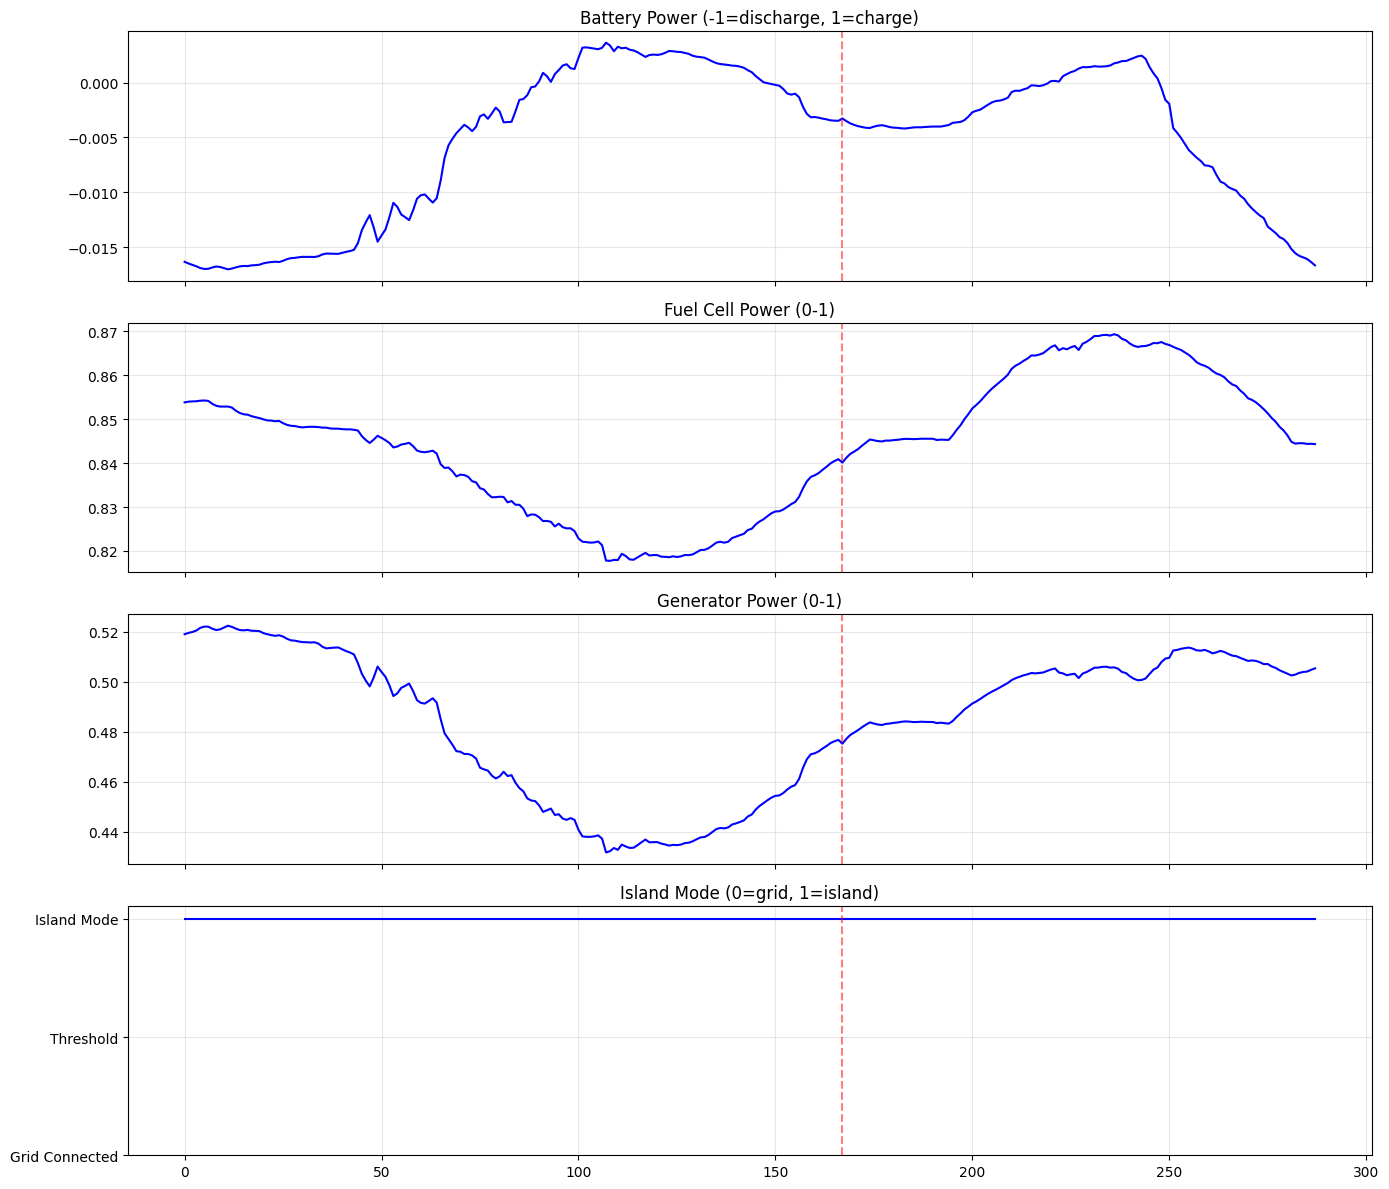

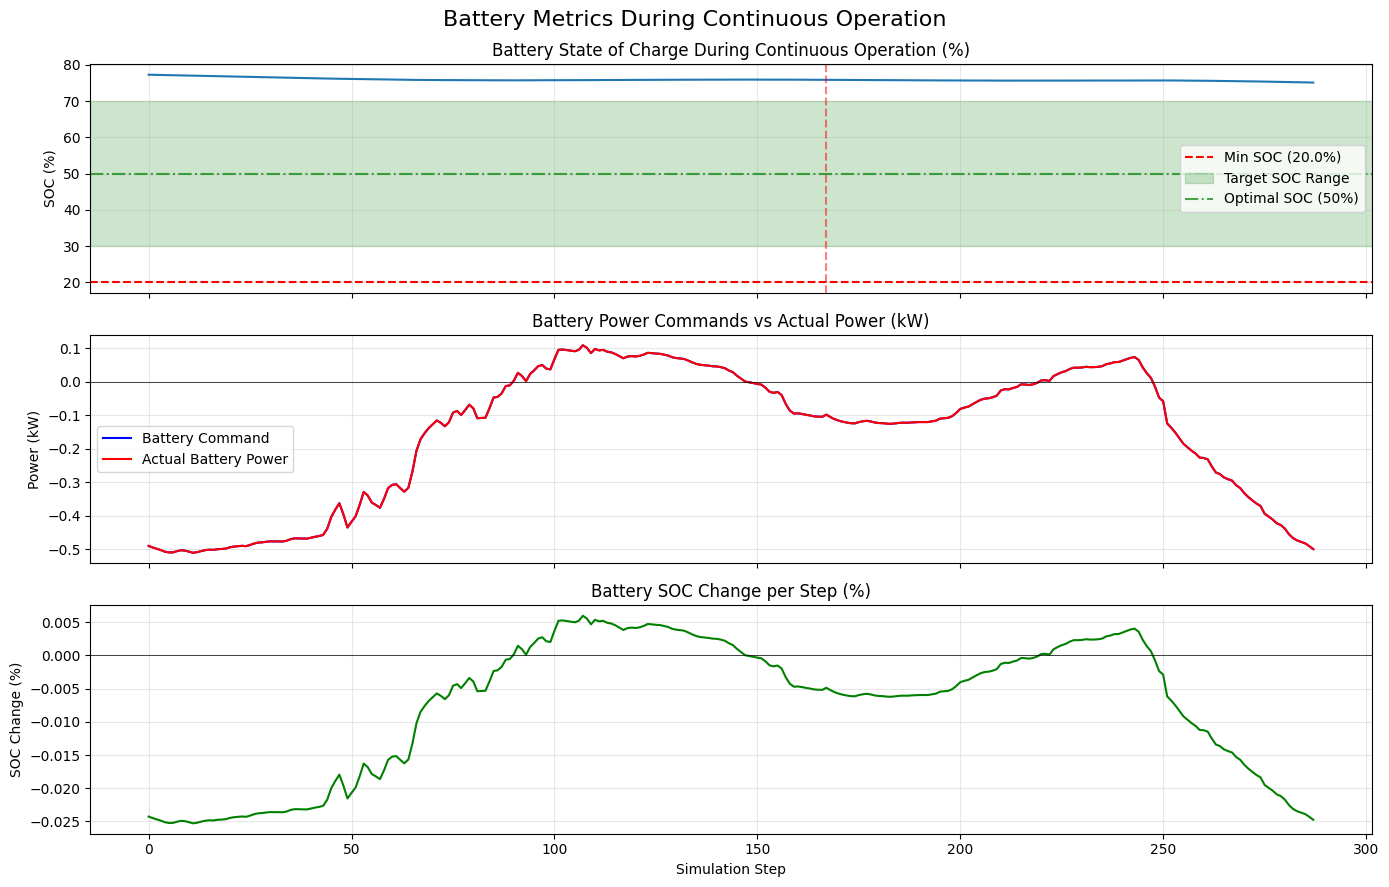

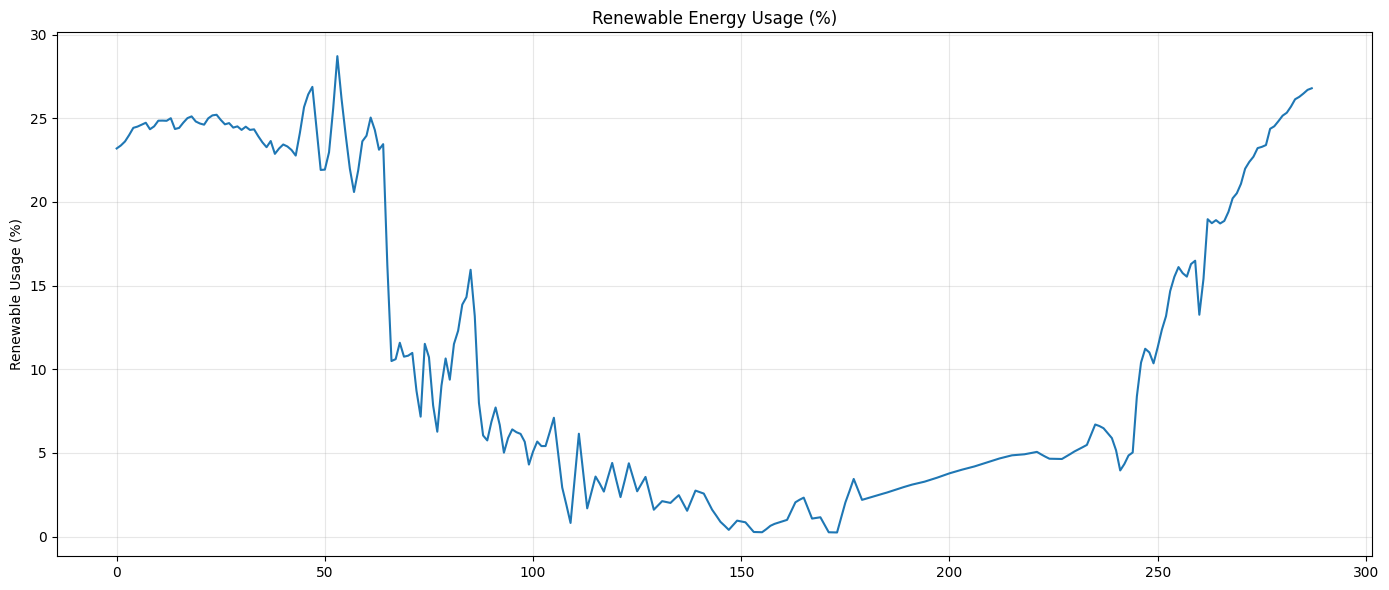

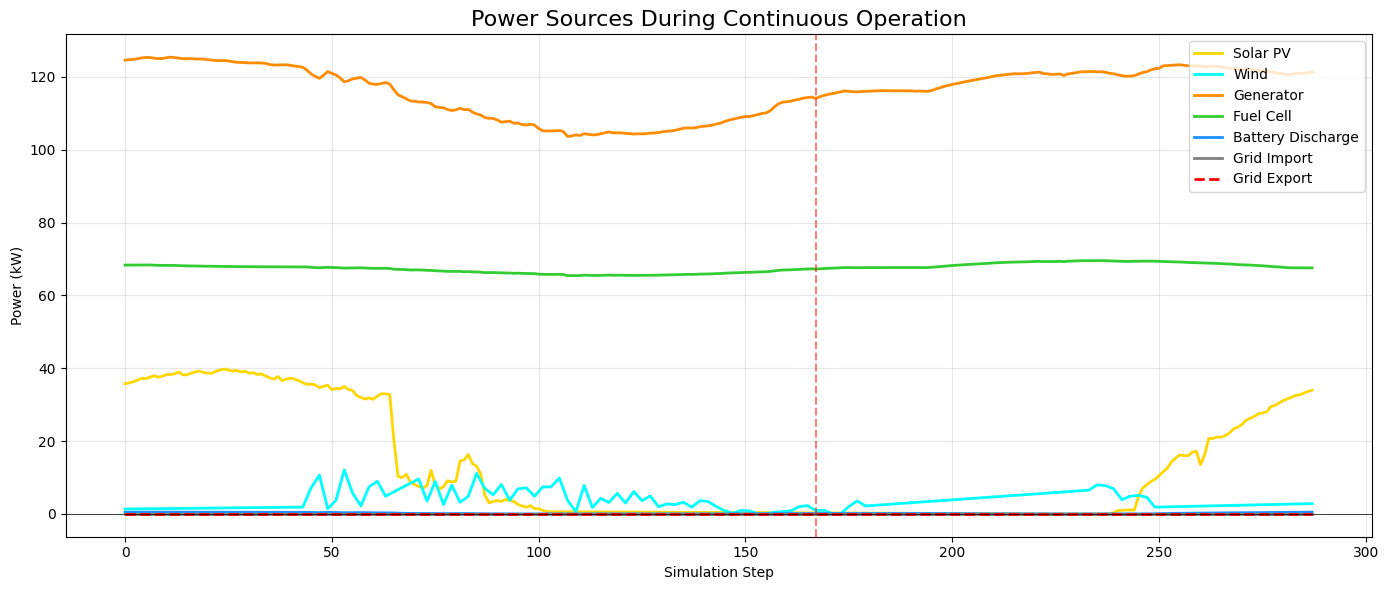

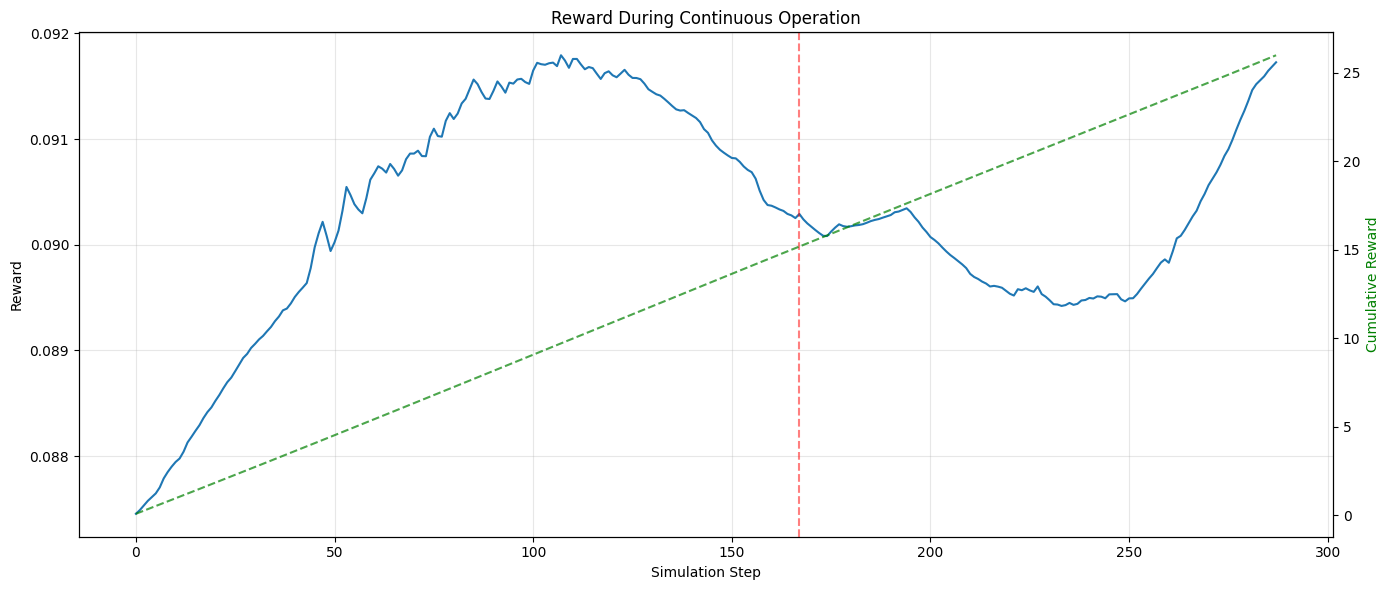

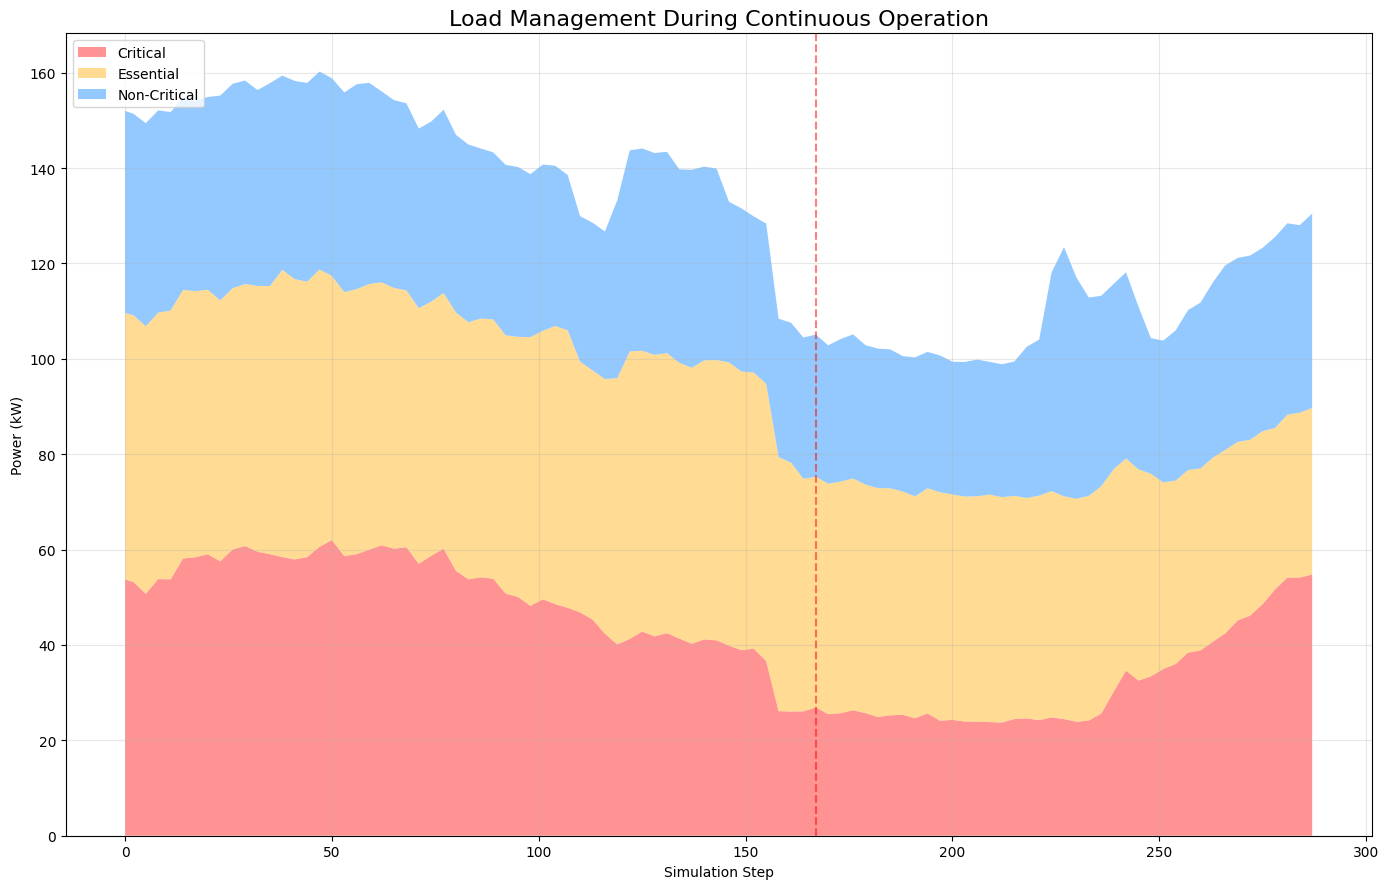

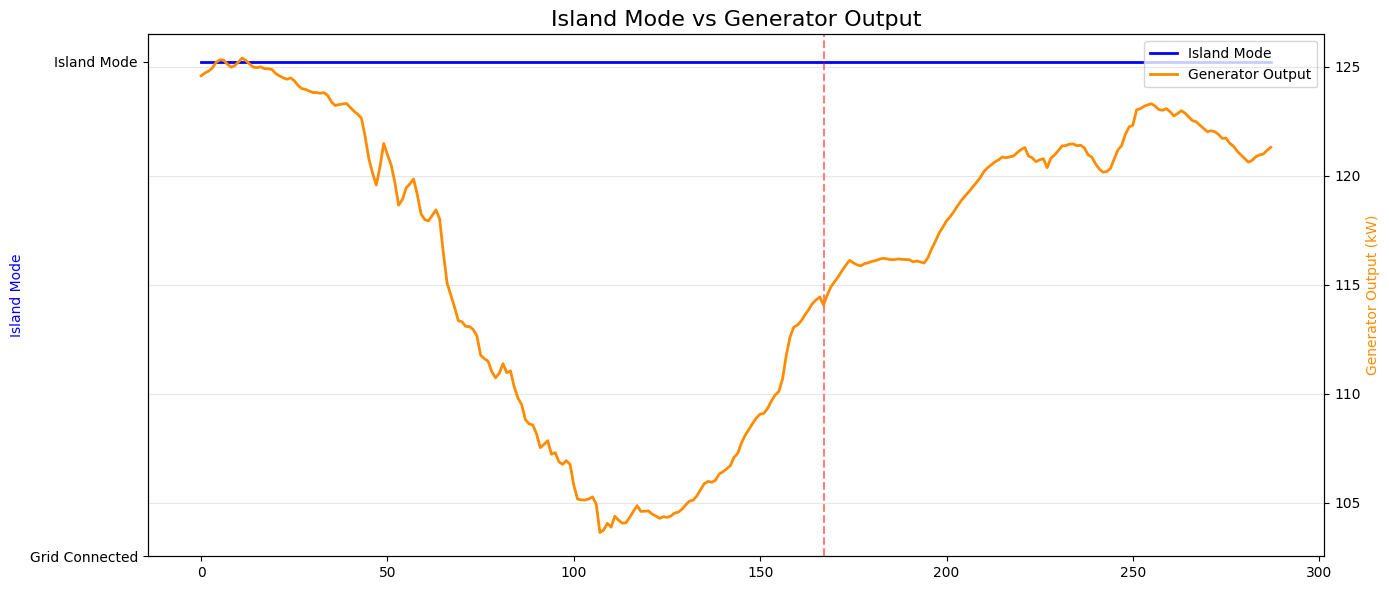

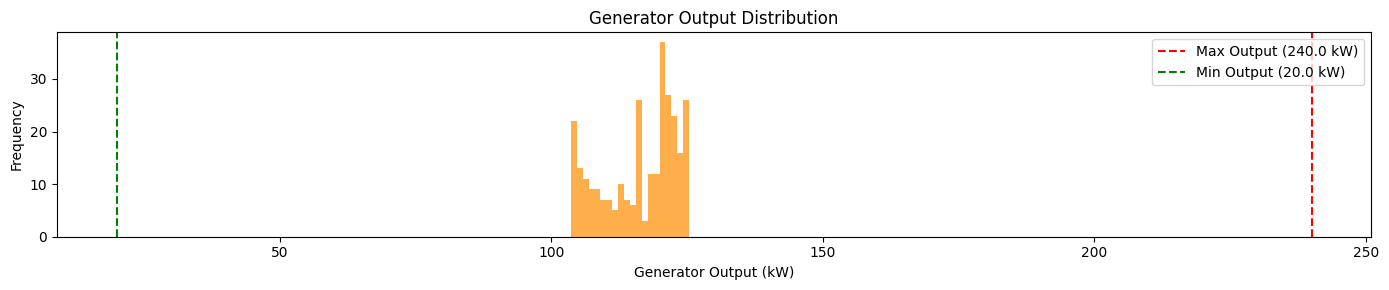


===== ACTION STATISTICS =====
Battery Power (-1 to 1) Statistics:
  Mean: -0.0052
  Std Dev: 0.0068
  Min: -0.0170
  Max: 0.0036
  High discharge (<-0.8): 0 (0.0%)
  High charge (>0.8): 0 (0.0%)
  Near zero (-0.1 to 0.1): 288 (100.0%)

Fuel Cell Power (0 to 1) Statistics:
  Mean: 0.8442
  Std Dev: 0.0152
  Min: 0.8177
  Max: 0.8694
  Values near max (>0.9): 0 (0.0%)
  Values near min (<0.1): 0 (0.0%)

Generator Power (0 to 1) Statistics:
  Mean: 0.4849
  Std Dev: 0.0283
  Min: 0.4318
  Max: 0.5225
  Values near max (>0.9): 0 (0.0%)
  Values near min (<0.1): 0 (0.0%)

Island Mode Decision (0 to 1) Statistics:
  Mean: 1.0000
  Std Dev: 0.0000
  Min: 1.0000
  Max: 1.0000
  Values near max (>0.9): 288 (100.0%)
  Values near min (<0.1): 0 (0.0%)

===== SYSTEM PERFORMANCE METRICS =====
Average reward: 0.0903
Cumulative reward: 25.9968
Time spent in island mode: 100.0%
Average renewable usage: 11.1%
Average generator usage: 48.5% of capacity
Average fuel cell usage: 84.4% of capacity
Average

In [69]:
result_df = visualize_continuous_inference(model, env, num_steps=288 * 1, debug_battery=False)

starting continuous inference for 1728 steps...
initial battery soc: 0.3744
time resolution: 5 minutes per step (288 steps = 24 hours)
expected simulation duration: 6.0 days
step 0:
  battery soc: 0.3744 → 0.3745 (δ: 0.0001)
  raw action: 0.0067, noise: 0.0000, final action: 0.0067
  battery action: 0.0067, raw power command: 0.20 kw
  actual battery power: 0.20 kw
  energy change: 0.02 kwh
step 10:
  battery soc: 0.3753 → 0.3754 (δ: 0.0001)
  raw action: 0.0057, noise: 0.0000, final action: 0.0057
  battery action: 0.0057, raw power command: 0.17 kw
  actual battery power: 0.17 kw
  energy change: 0.02 kwh
step 20:
  battery soc: 0.3761 → 0.3762 (δ: 0.0001)
  raw action: 0.0052, noise: -0.0000, final action: 0.0052
  battery action: 0.0052, raw power command: 0.16 kw
  actual battery power: 0.16 kw
  energy change: 0.01 kwh
step 30:
  battery soc: 0.3771 → 0.3772 (δ: 0.0001)
  raw action: 0.0064, noise: 0.0000, final action: 0.0064
  battery action: 0.0064, raw power command: 0.19 kw


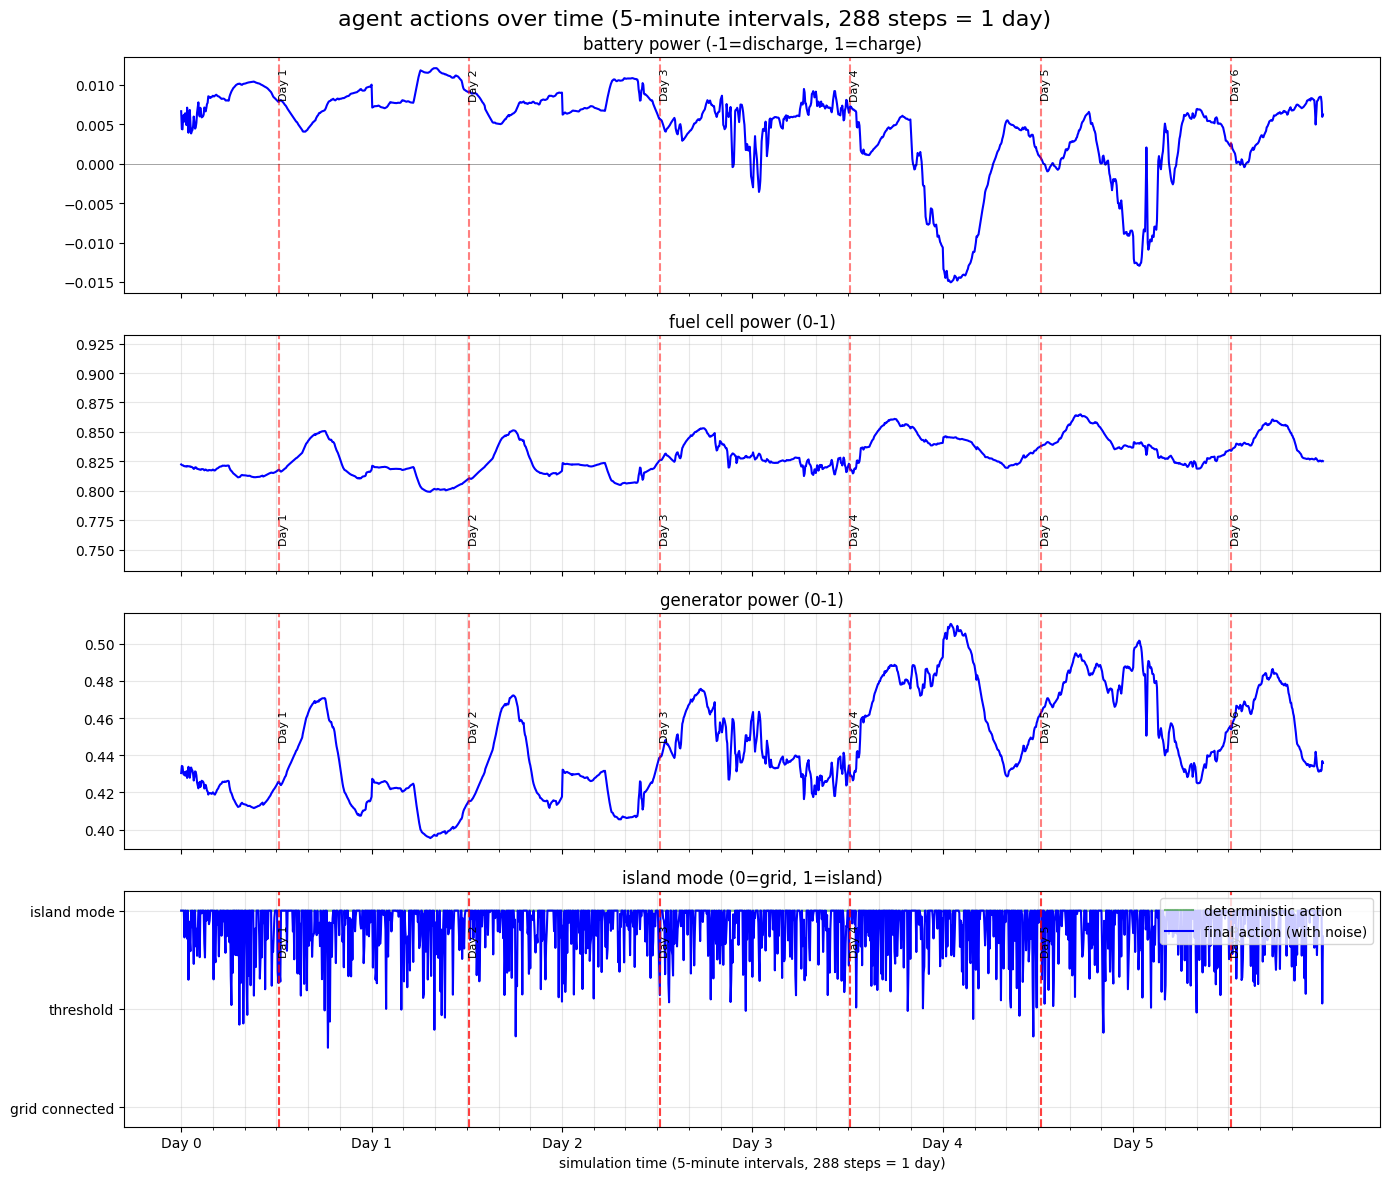

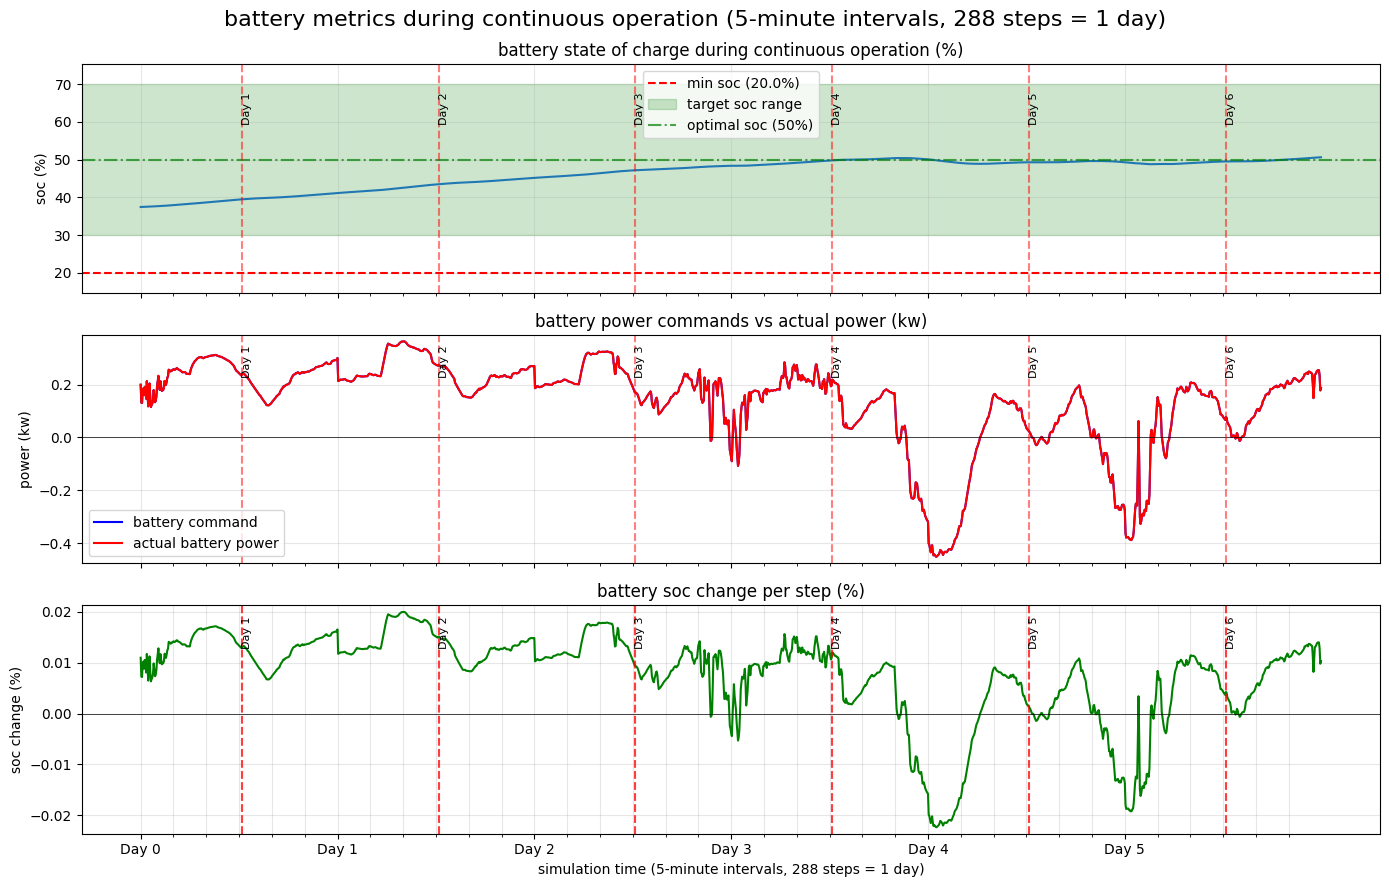

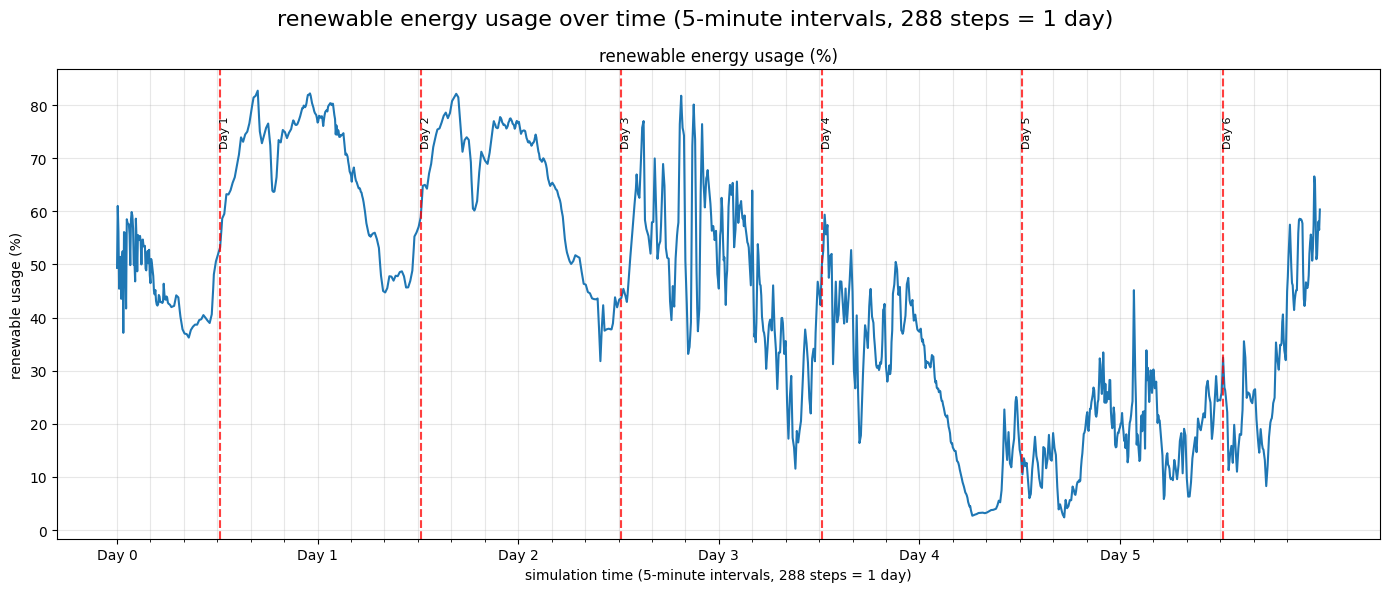

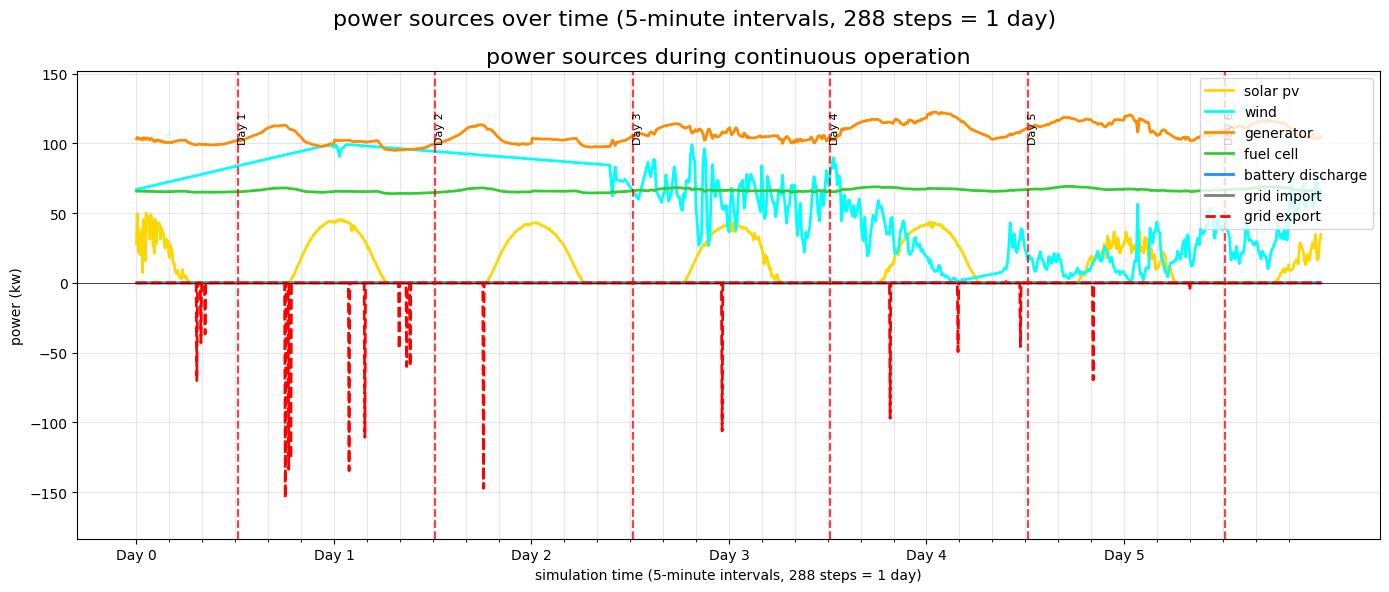

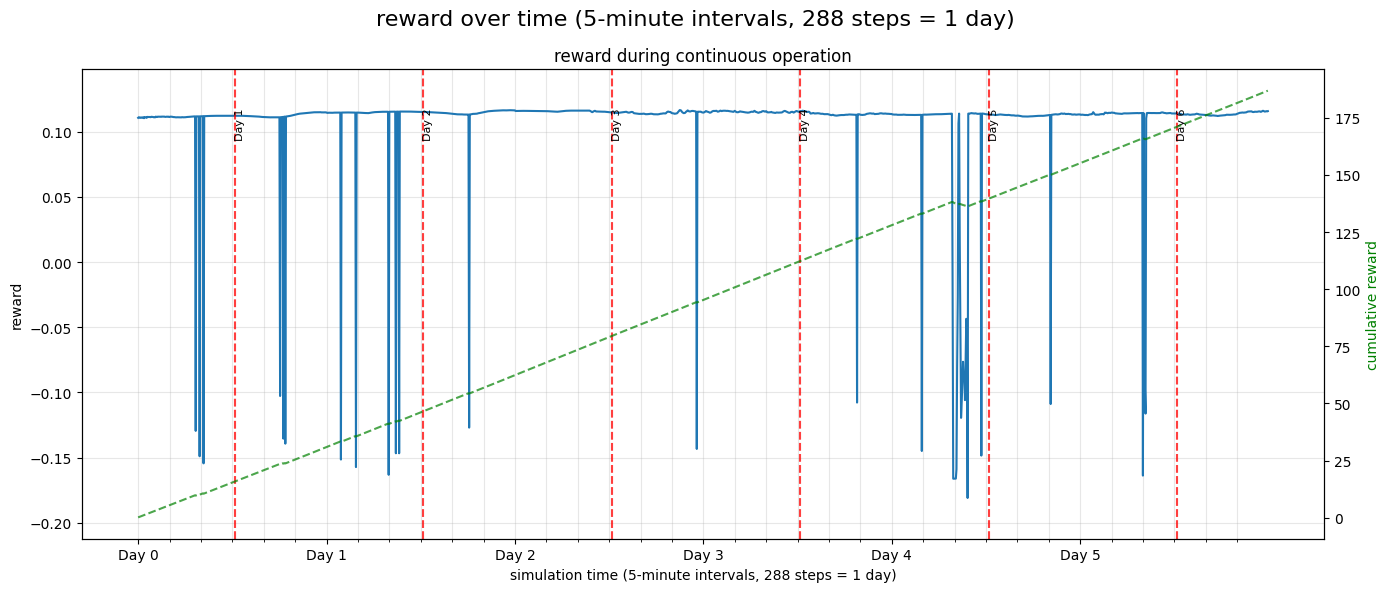

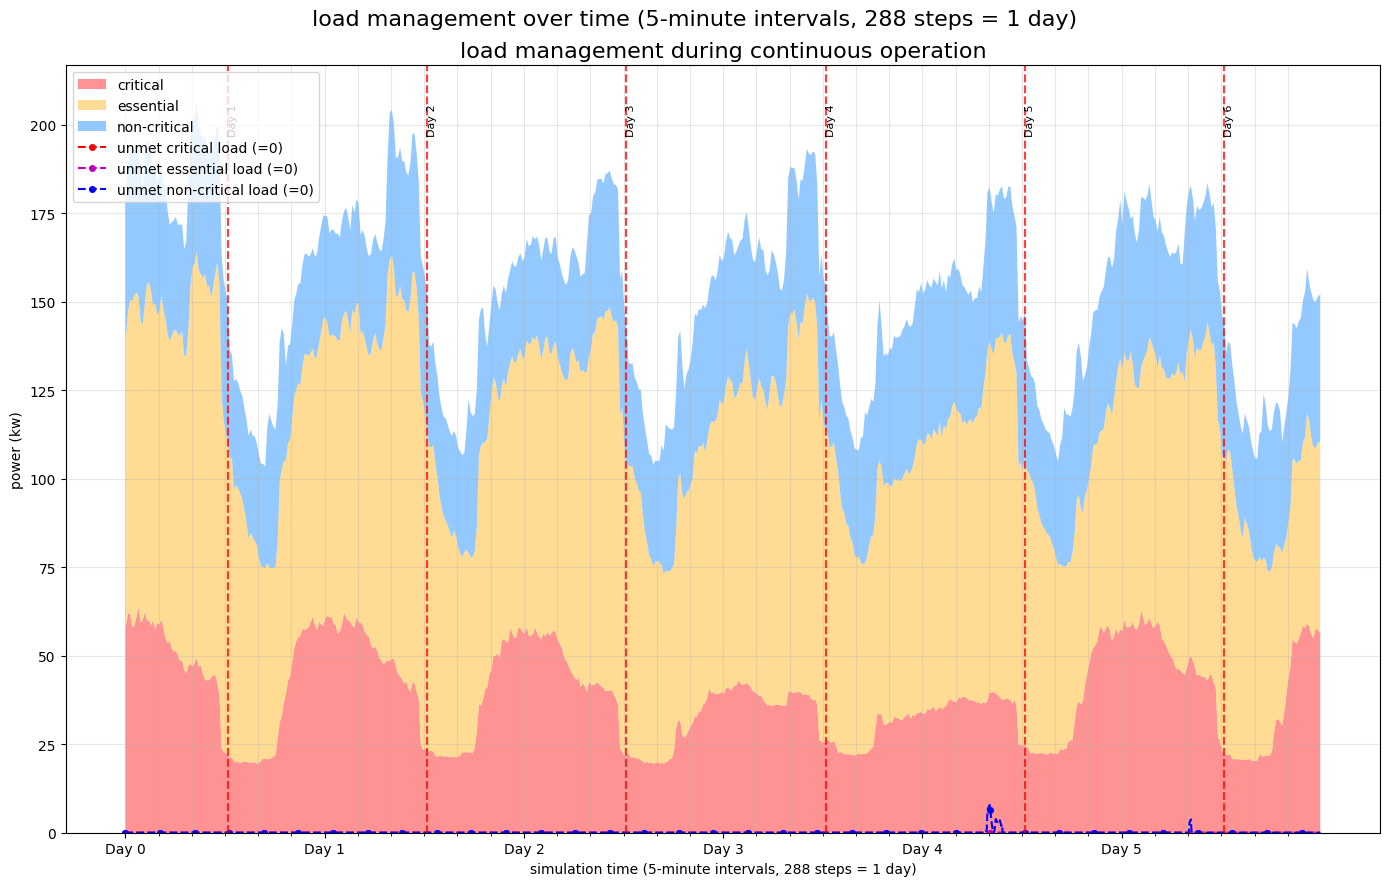

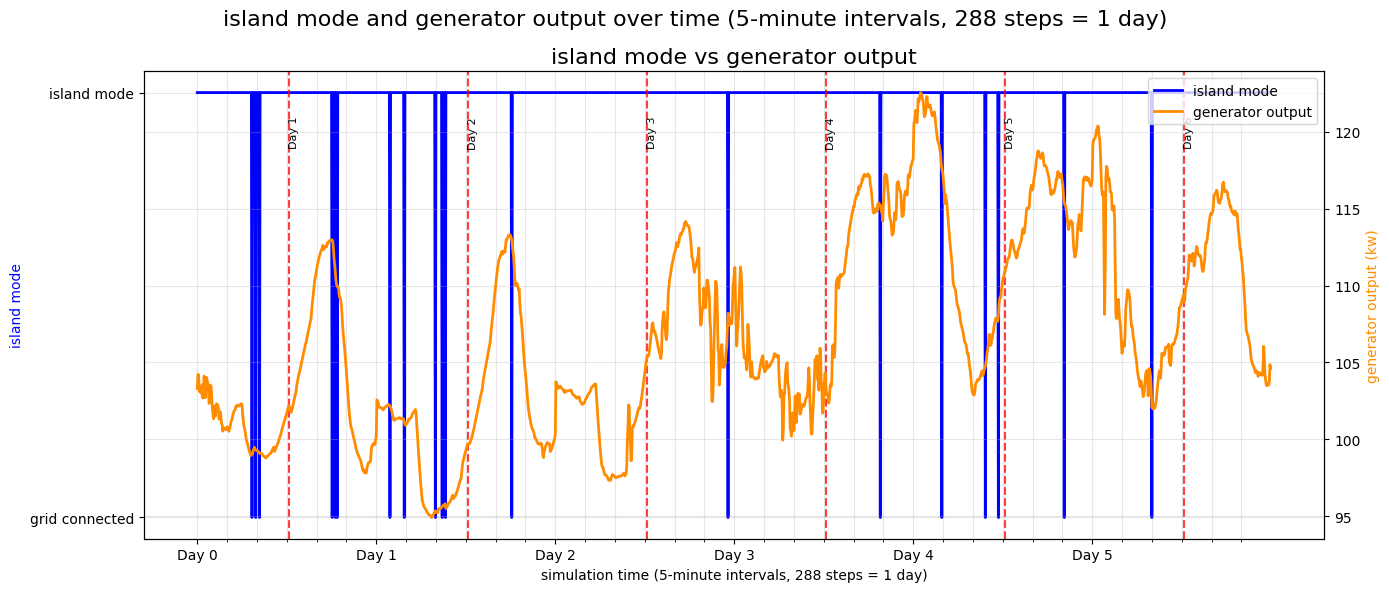

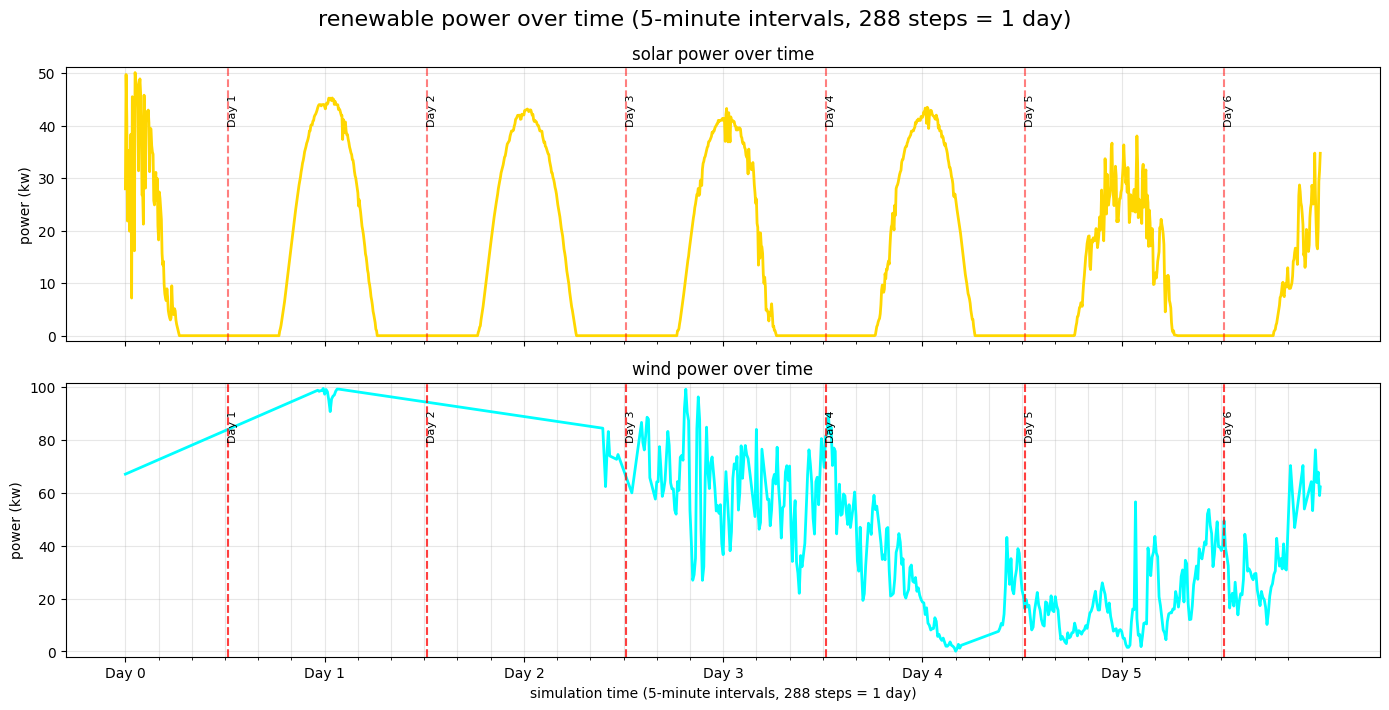

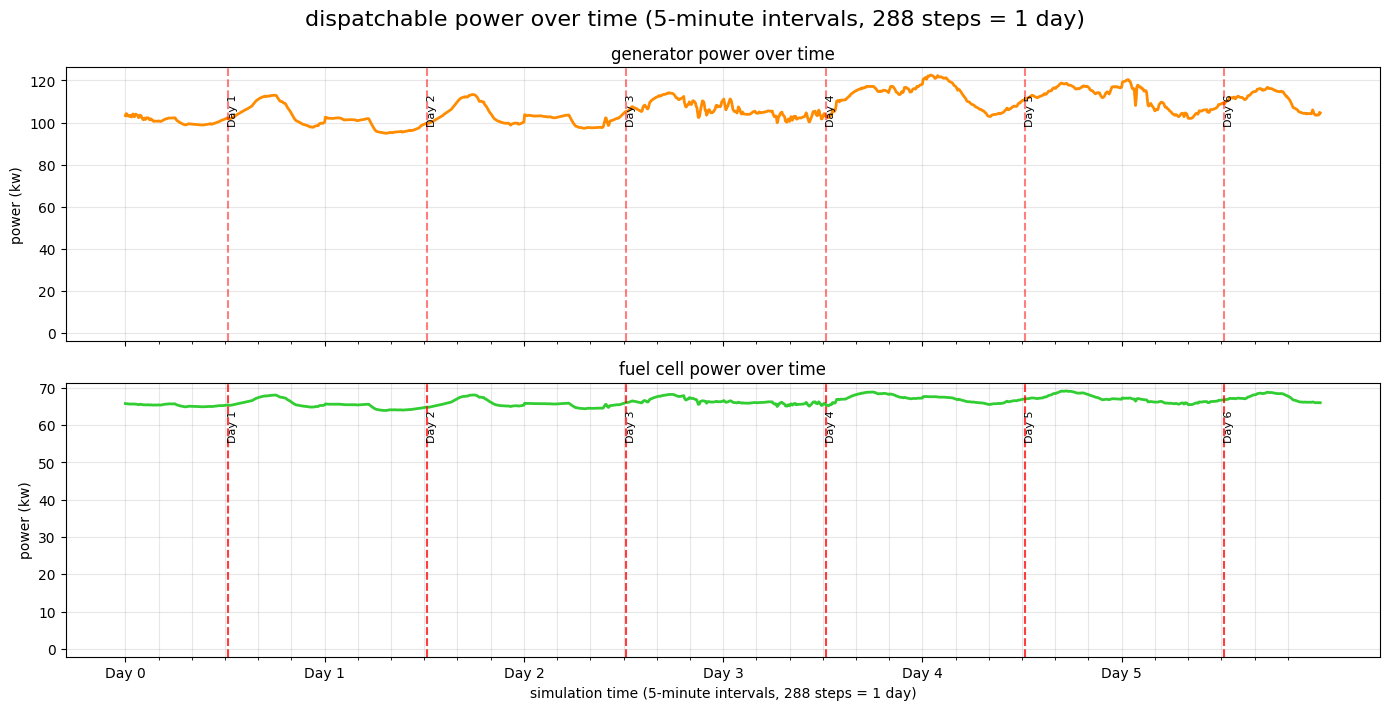

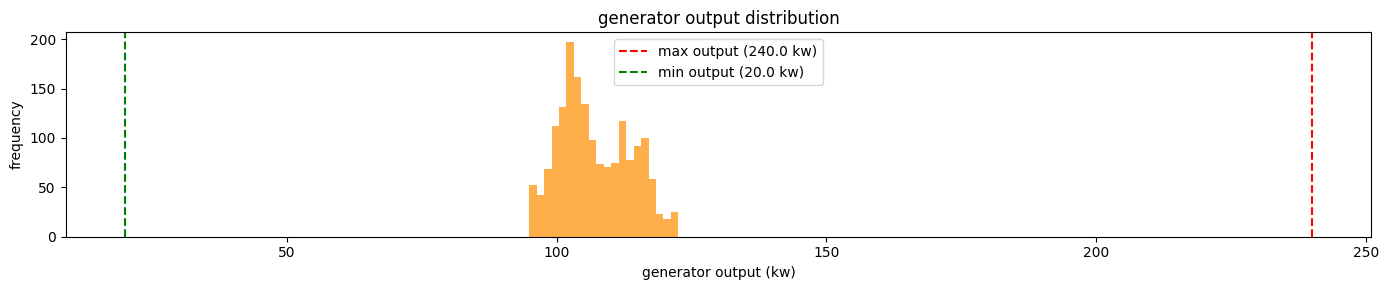

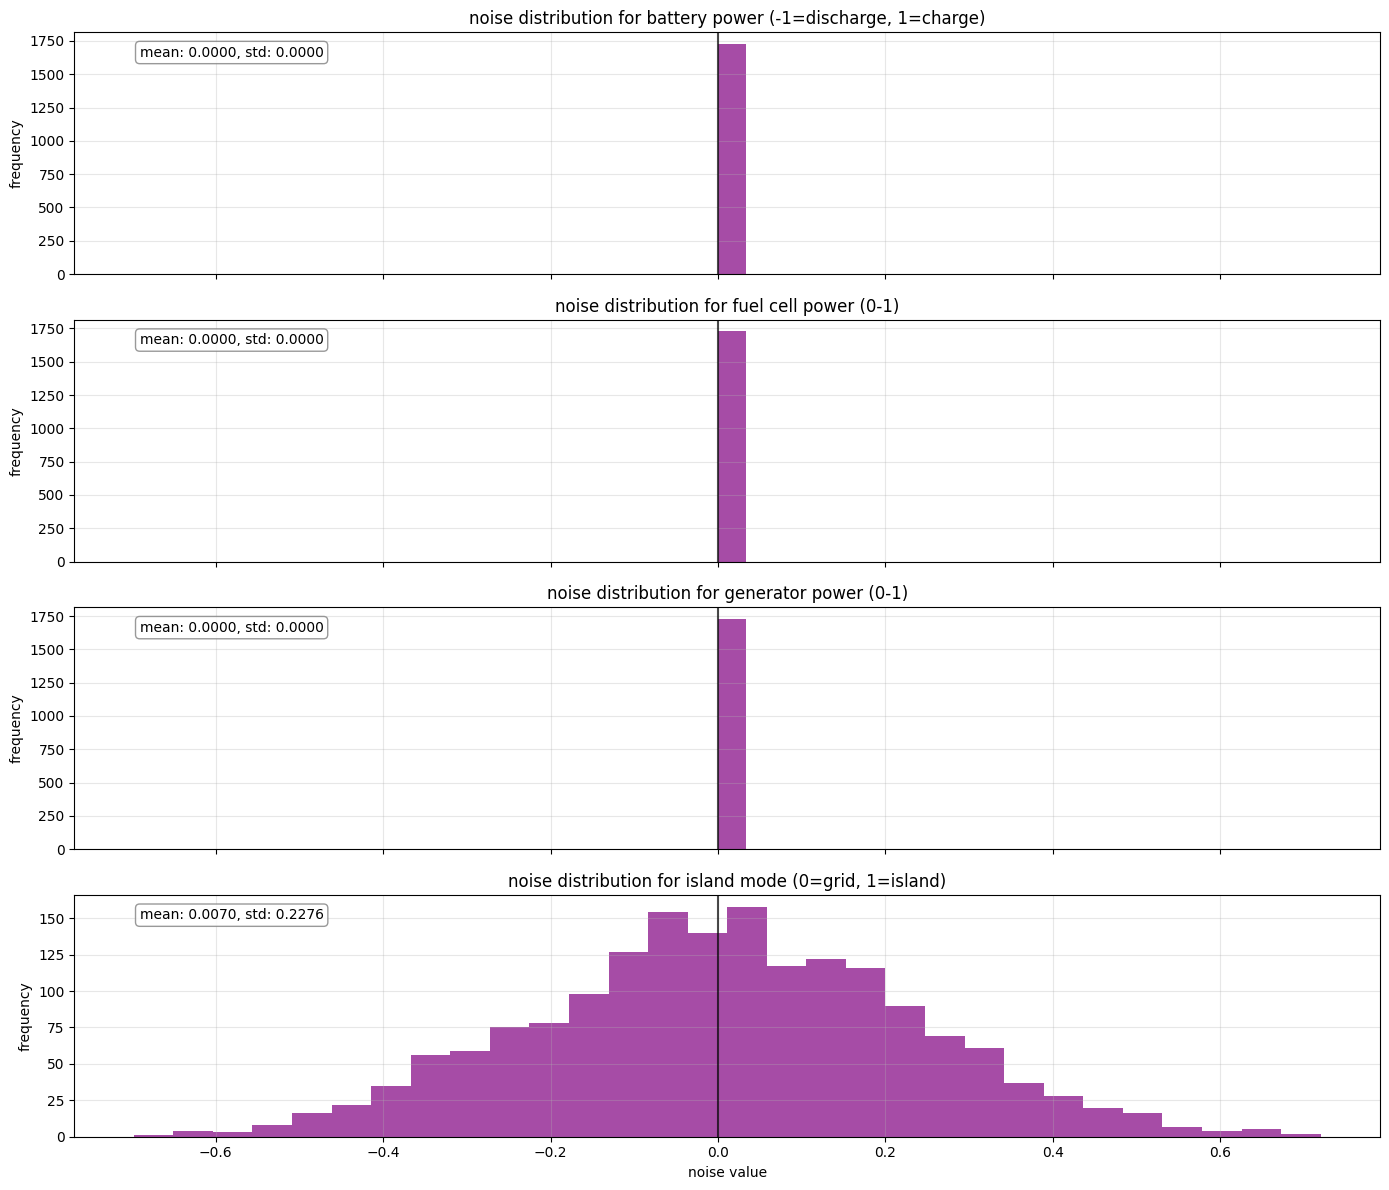


===== action statistics =====
total simulation steps: 1728
simulation duration: 6.00 days (1728 steps at 5-minute intervals)
complete days: 6

battery power (-1 to 1) statistics:
  mean: 0.0045
  std dev: 0.0056
  min: -0.0150
  max: 0.0121
  high discharge (<-0.8): 0 (0.0%)
  high charge (>0.8): 0 (0.0%)
  near zero (-0.1 to 0.1): 1728 (100.0%)

fuel cell power (0 to 1) statistics:
  mean: 0.8296
  std dev: 0.0148
  min: 0.7992
  max: 0.8649
  values near max (>0.9): 0 (0.0%)
  values near min (<0.1): 0 (0.0%)

generator power (0 to 1) statistics:
  mean: 0.4458
  std dev: 0.0272
  min: 0.3954
  max: 0.5107
  values near max (>0.9): 0 (0.0%)
  values near min (<0.1): 0 (0.0%)

island mode decision (0 to 1) statistics:
  mean: 0.9129
  std dev: 0.1301
  min: 0.3021
  max: 1.0000
  values near max (>0.9): 1195 (69.2%)
  values near min (<0.1): 0 (0.0%)

===== system performance metrics =====
average reward: 0.1082
cumulative reward: 186.8836
avg reward per day: 31.1473
time spent in is

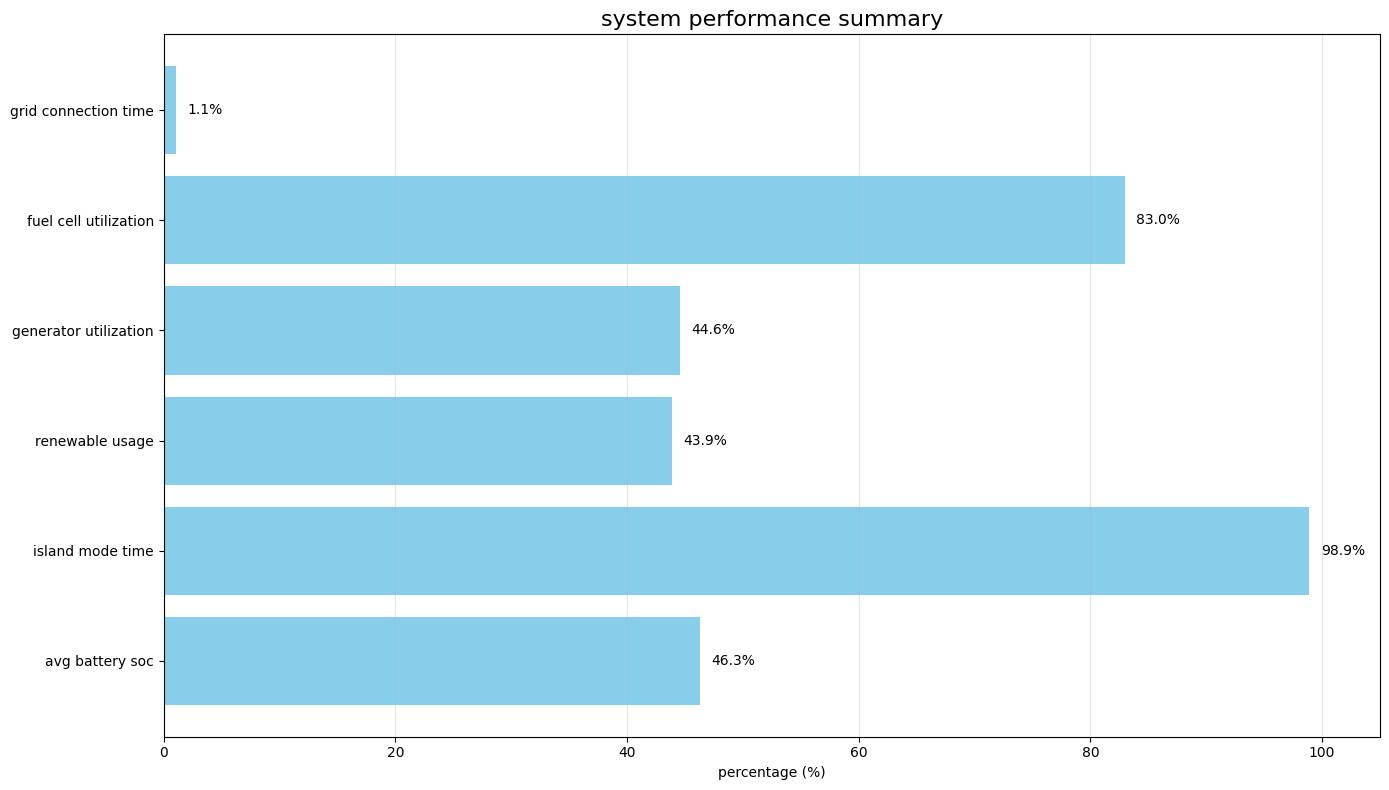

In [94]:
info_df = visualize_continuous_inference(
    model, env, num_steps=288 * 6, 
    use_noise=True,
    # Set appropriate noise levels per dimension
    noise_scales=[0.0000, 0.00000, 0.00000, 0.225]  # [battery, fuel_cell, generator, island_mode]
)

### Evaluating deterministic vs stochastic (with noise)

In [ ]:
# Run multiple episodes with both settings
deterministic_rewards = []
stochastic_rewards = []

for i in range(6):  # Run 10 episodes each
    # Reset environment with same seed for fair comparison
    
    # Deterministic run
    obs, _ = env.reset()
    episode_reward = 0
    for _ in range(288):  # One day
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, _, _, _ = env.step(action)
        episode_reward += reward
    deterministic_rewards.append(episode_reward)
    
    obs, _ = env.reset()
    episode_reward = 0
    for _ in range(288):  # One day
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, _, _, _ = env.step(action)
        episode_reward += reward
    stochastic_rewards.append(episode_reward)

# Compare results
print(f"Deterministic mean reward: {sum(deterministic_rewards)/10:.2f}")
print(f"Stochastic mean reward: {sum(stochastic_rewards)/10:.2f}")

In [ ]:
# Why Your Stochastic Policy Outperforms the Deterministic One
# Your observation that stochastic policies perform significantly better than deterministic ones in your microgrid environment (stochastic: -1.06 vs deterministic: -2.16) is quite interesting but not entirely surprising given the nature of your environment. Here's why this happens:
# Key Reasons for the Performance Difference

# Binary Decision Boundaries

# Your environment has several "cliff-like" reward transitions, particularly around the island mode decision (where action[3] ≥ 0.5 triggers island mode)
# A stochastic policy can explore both sides of these boundaries during evaluation, finding better operating conditions


# Battery Management Complexity

# Your battery management involves target SOC rewards with quadratic falloff
# Stochastic policies can better maintain battery SOC near target range by mixing charge/discharge actions


# Multi-modal Optimal Solutions

# Energy management problems often have multiple near-optimal solutions
# Stochastic exploration helps discover these alternative good solutions during evaluation


# Non-linear Efficiency Curves

# Your generator and fuel cell have efficiency penalties at high capacity (>80%)
# Stochastic policies tend to spread operation across power sources more evenly, avoiding these high-penalty regions